In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
from sklearn.preprocessing import LabelEncoder
from Data_Functions import Get_Data, Extract_Initial_Data, Clean_and_dropna, Get_Regions
from Visualization_Functions import plot_corrs, get_ecdfplots, get_violinplots, plot_hists_by_Cryo_and_Transported
from Visualization_Functions import plot_ratios_by_Cryo_and_Transported, plot_CryoTrans_Counts
import string
%run Models.ipynb

In [2]:
df = Get_Data('Data/train.csv')
df_test = Get_Data('Data/test.csv')

df, df_test = Extract_Initial_Data(df, df_test)

In [3]:
df_clean, df_test_clean = Clean_and_dropna(df, df_test)

Number of null rows before cleaning:  3083
skewed_features:  ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'GroupSize', 'FamilySize', 'GroupFamilySize', 'CabinFamilySize', 'CabinGroupSize', 'CabinSize']
drop remaining 1371 null rows in training data
drop remaining 685 null rows in test data


# Closer look at the luxury features and Age

In [4]:
Features = ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age', 'Transported']
Luxury_Features = ['Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall']
Non_Essential_Lux_Features = ['RoomService', 'Spa', 'VRDeck']
Essential_Lux_Features = ['FoodCourt', 'ShoppingMall']
df0 = df_clean[Features].copy(deep = True)
df0['Transported'] = df0['Transported'].astype(int)
df0['Lux_non_Essential'] = df0[Non_Essential_Lux_Features].mean(axis = 1)
df0['Lux_Essential'] = df0[Essential_Lux_Features].mean(axis = 1)

In [5]:
bins = 10
bin_labels = range(1, bins + 1)
df0['Age_Bin'], Bin_ranges = pd.qcut(df0.Age, q = bins, labels = bin_labels, retbins = True)
Bin_ranges

array([ 0., 12., 18., 21., 24., 27., 30., 35., 41., 49., 79.])

### First, let's look at the correlations

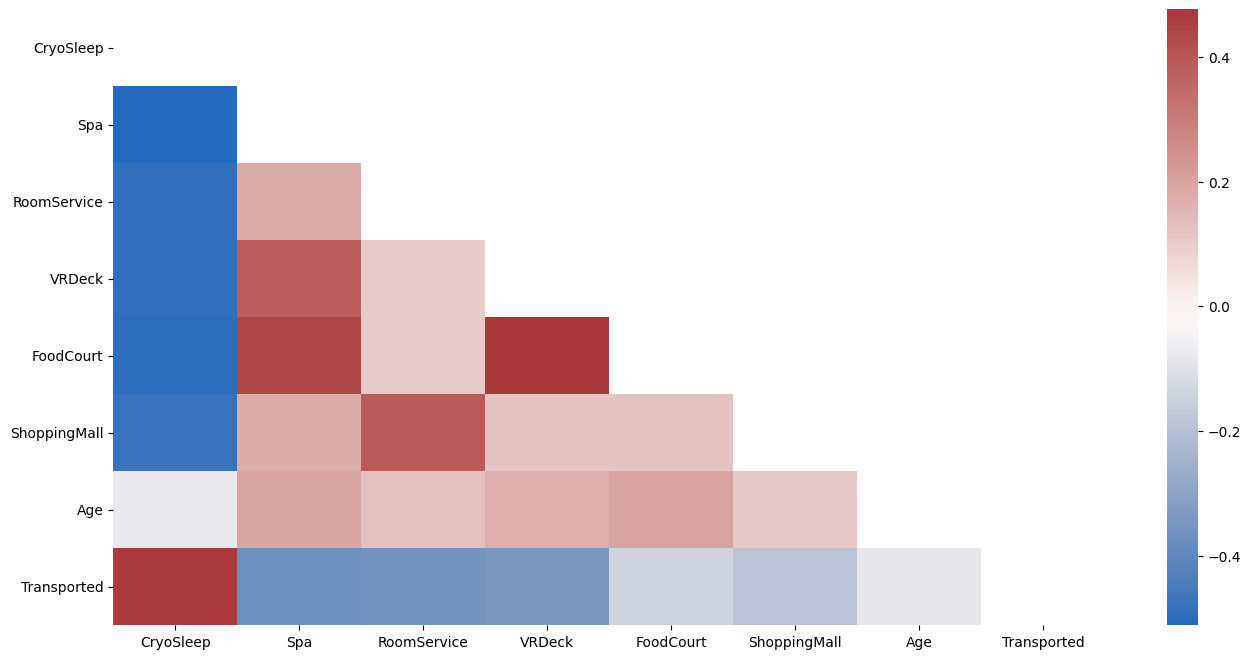

In [6]:
plot_corrs(df0[Features], cmap = 'vlag')

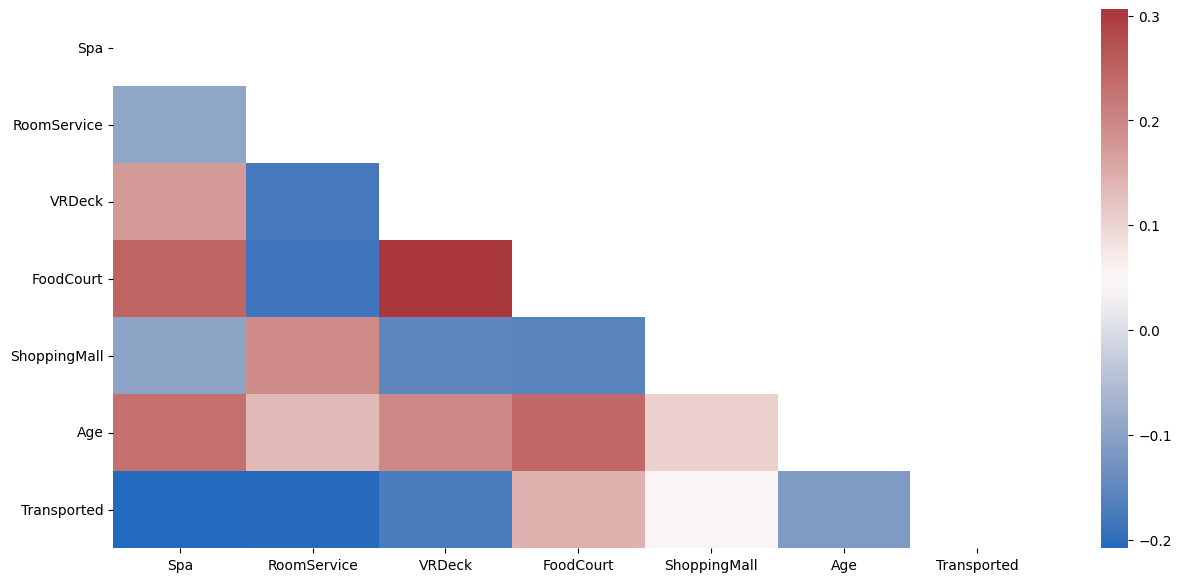

In [7]:
plot_corrs(df0[df0.CryoSleep == False][Luxury_Features + ['Age', 'Transported']], cmap = 'vlag')

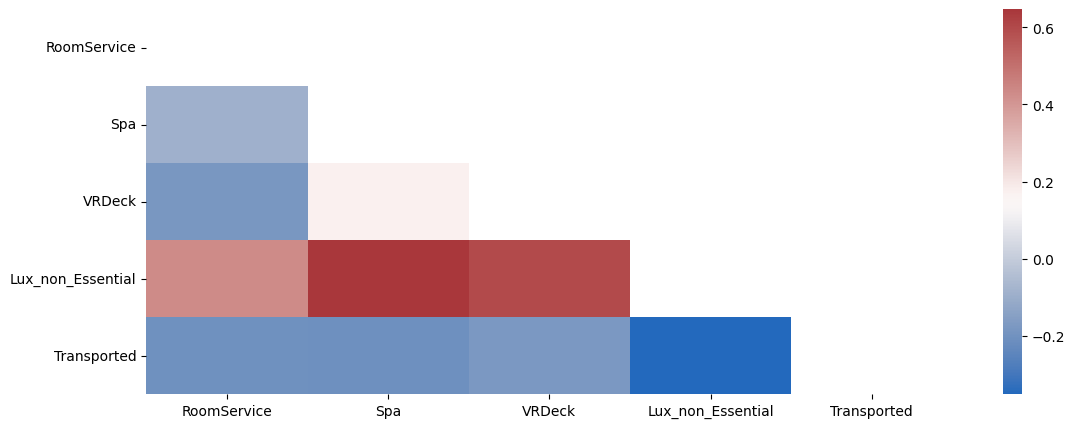

In [8]:
plot_corrs(df0[df0.CryoSleep == False][Non_Essential_Lux_Features + ['Lux_non_Essential', 'Transported']], cmap = 'vlag')

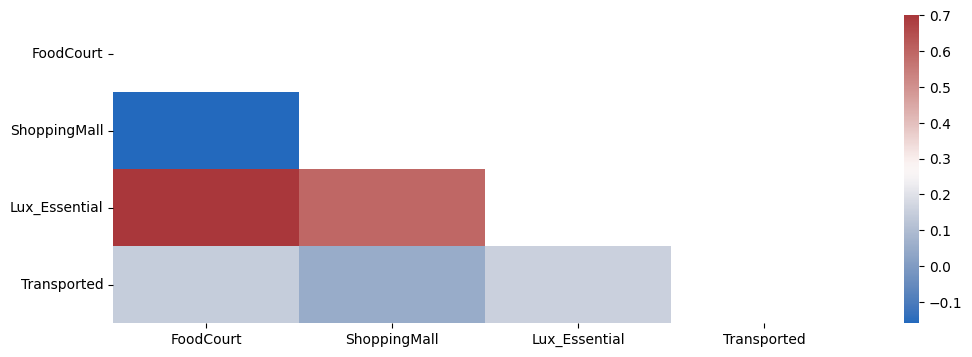

In [9]:
plot_corrs(df0[df0.CryoSleep == False][Essential_Lux_Features + ['Lux_Essential', 'Transported']], cmap = 'vlag')

### Examine distributions, ratios, and histograms

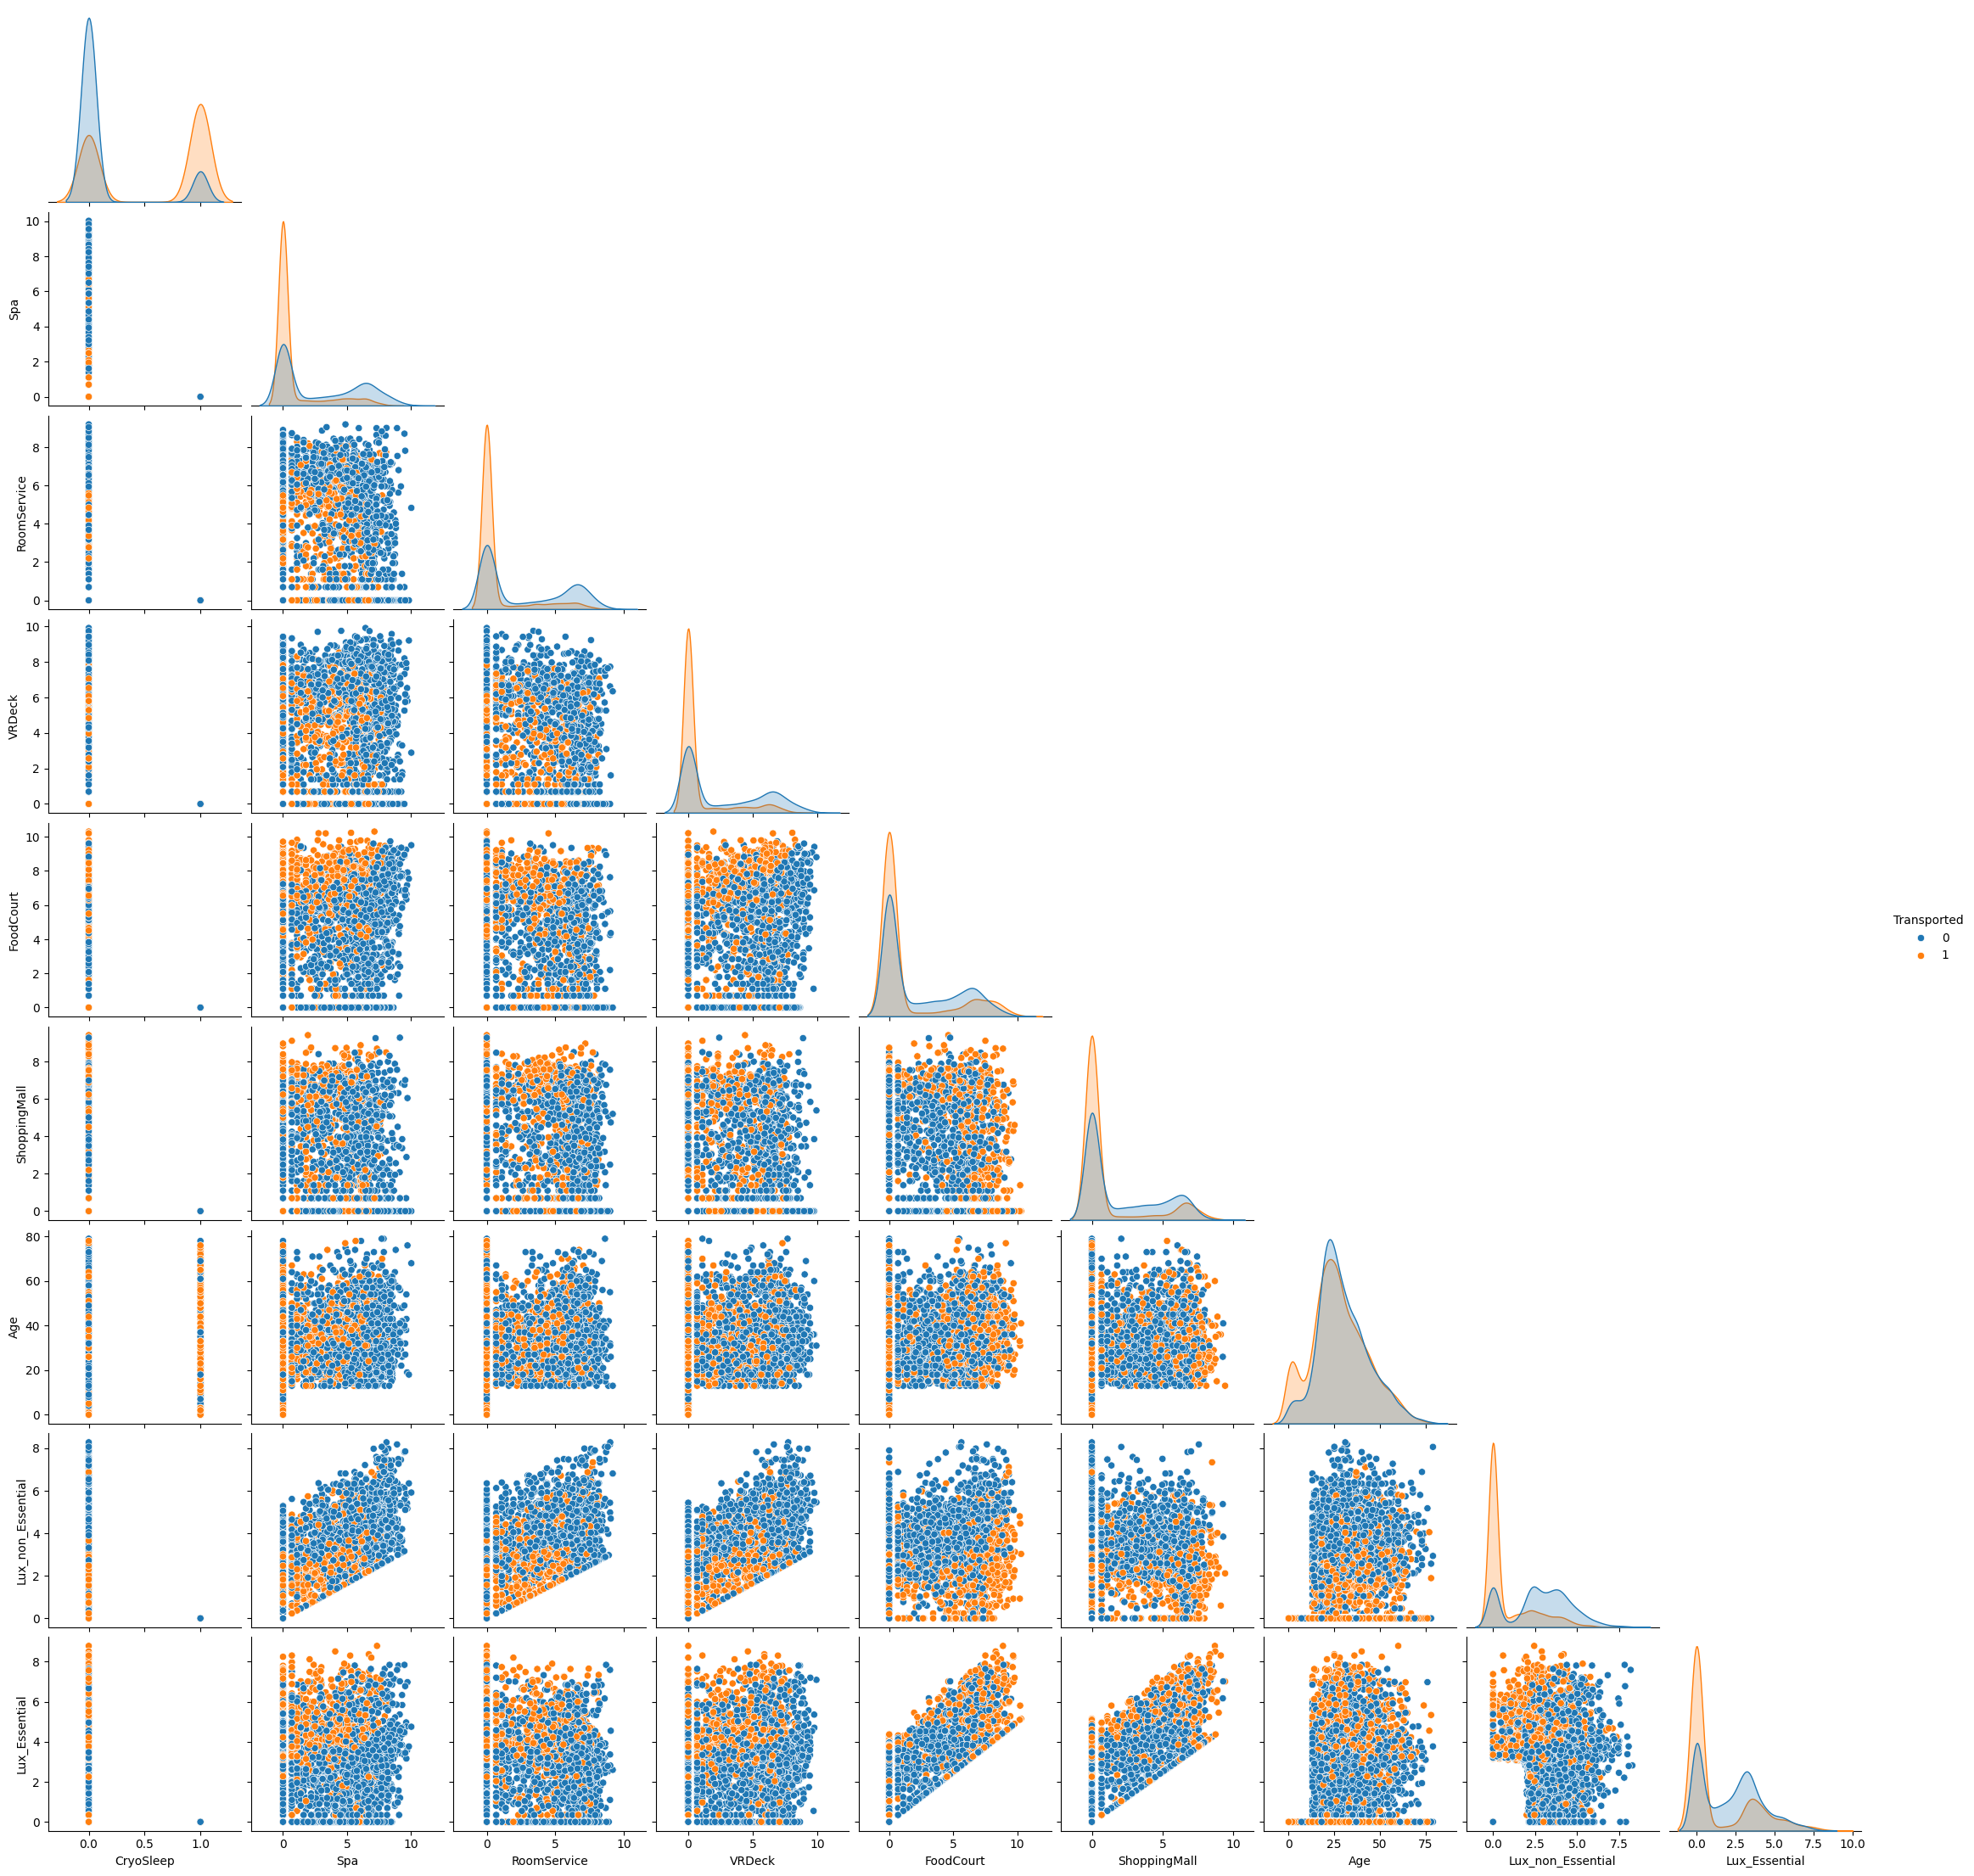

In [10]:
sns.pairplot(data = df0, hue = 'Transported', corner = True)

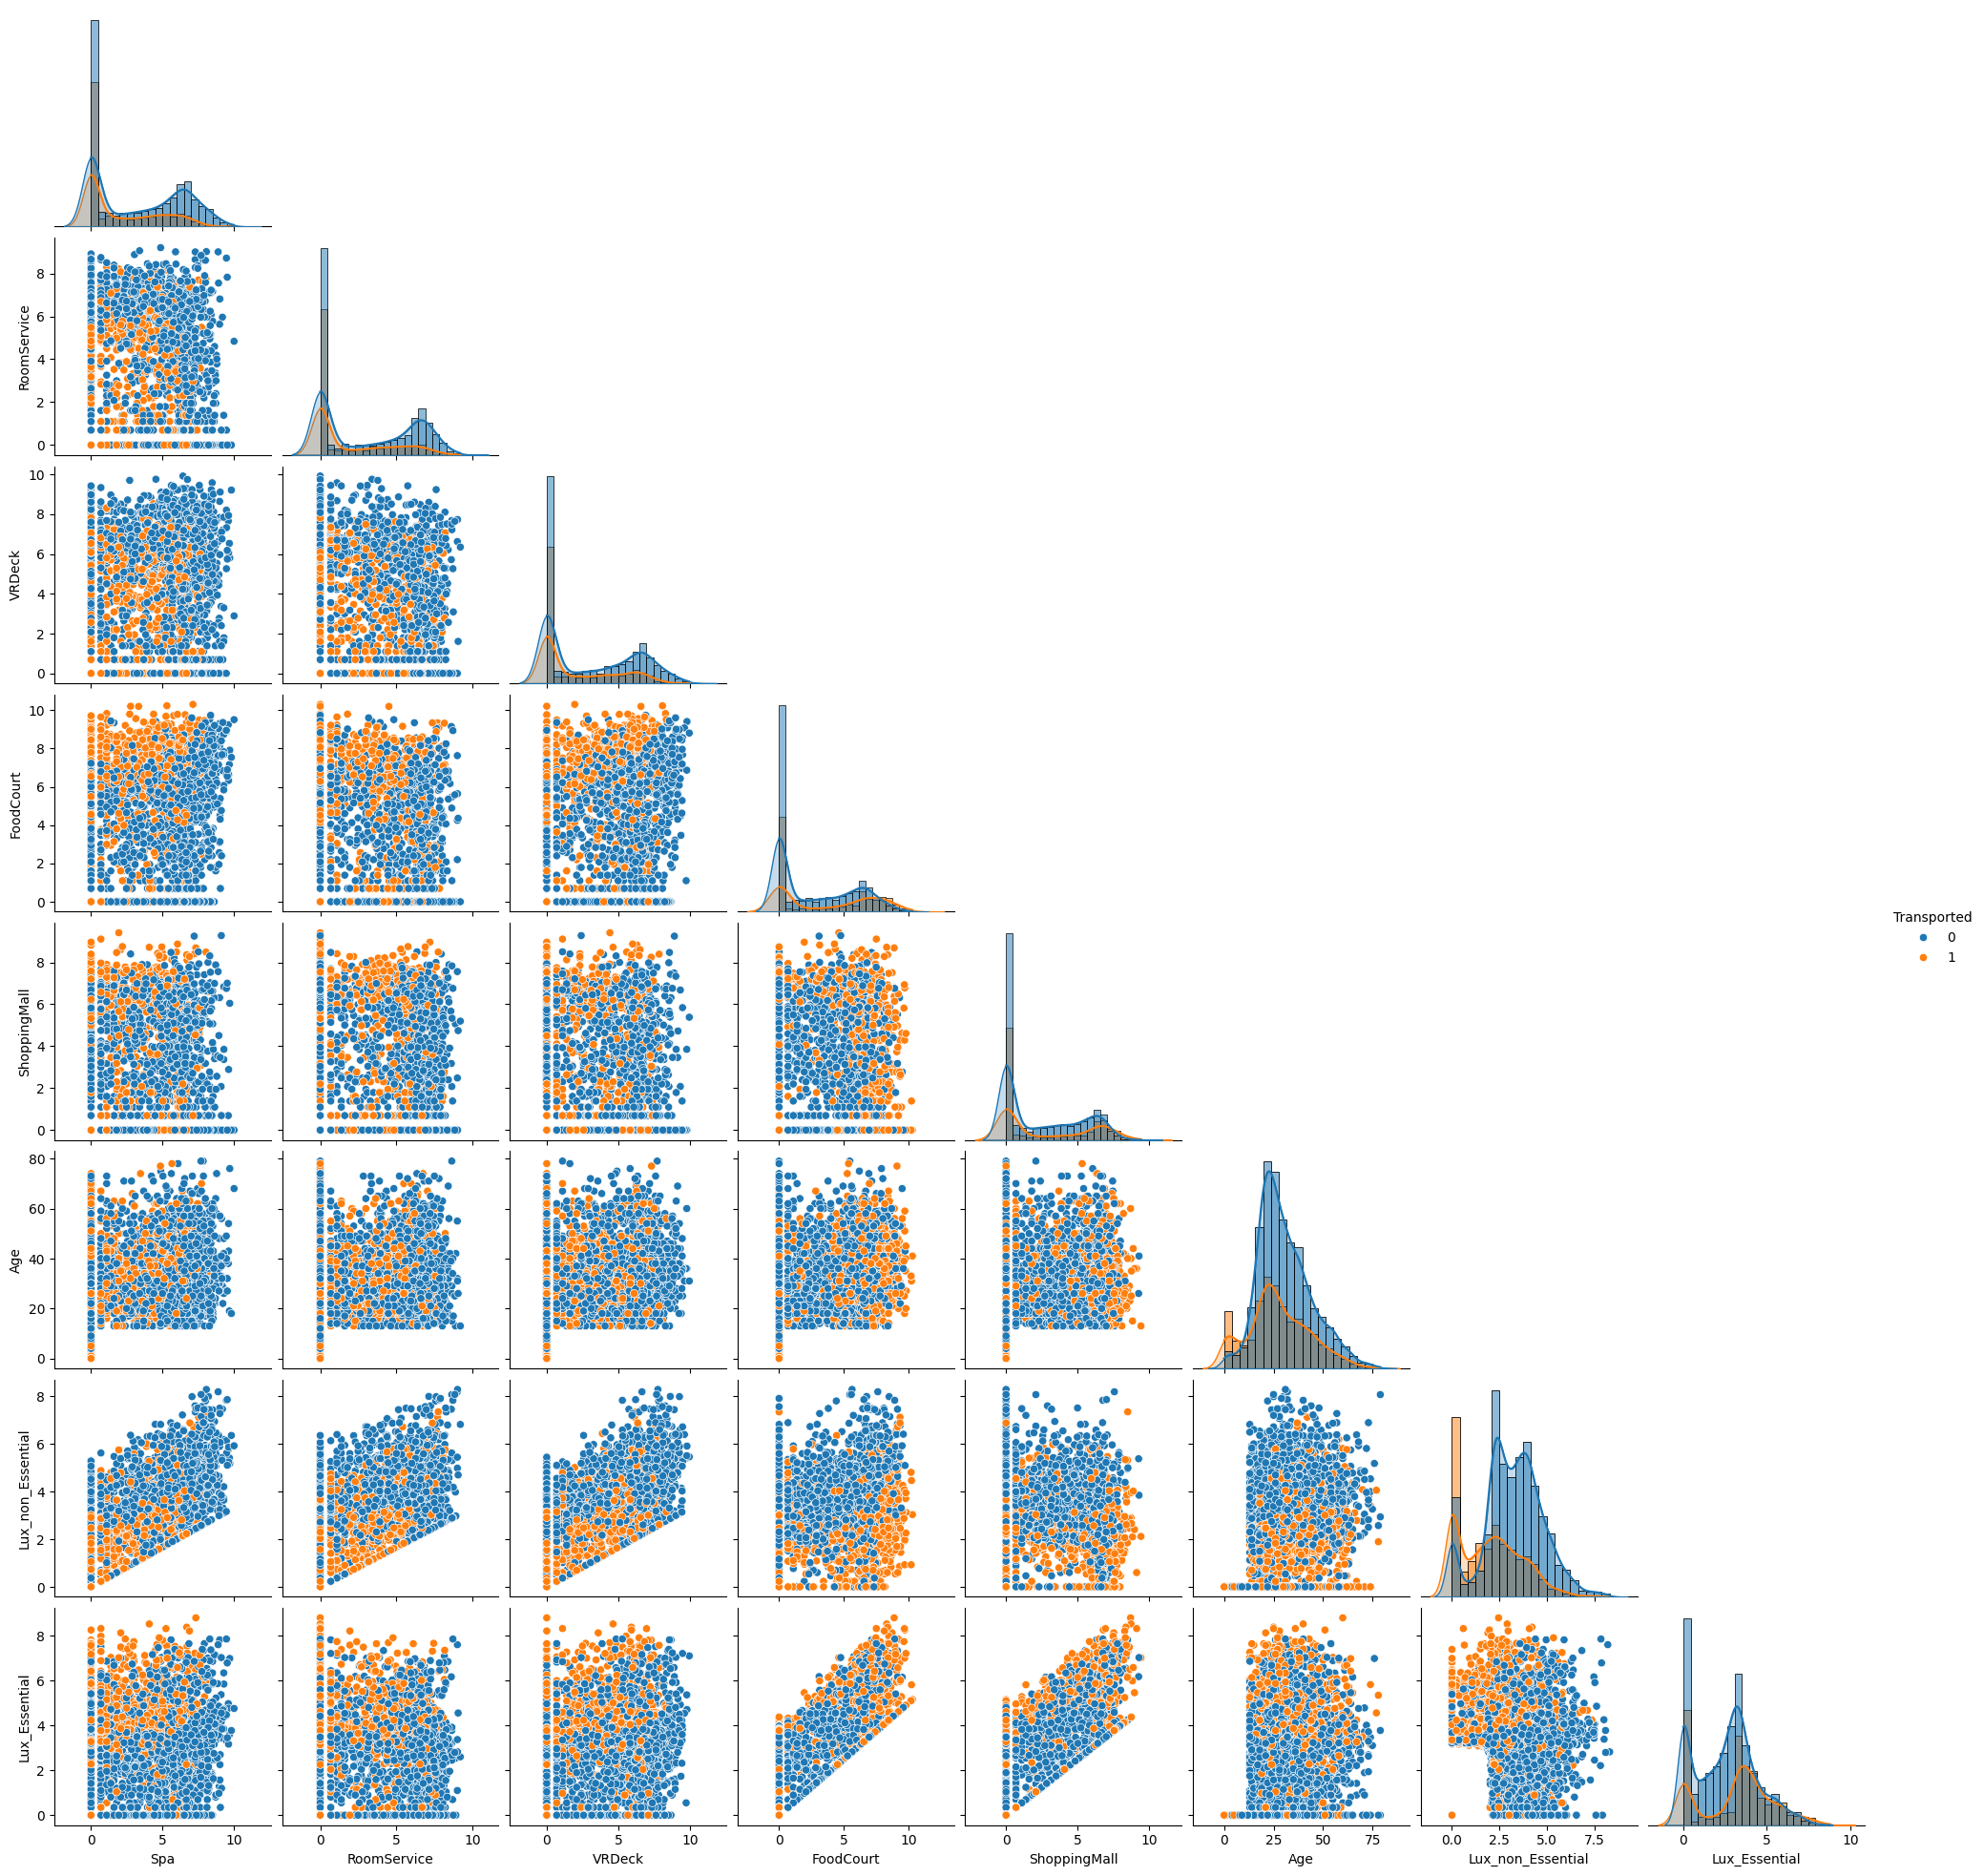

In [11]:
mask = df0['CryoSleep'] == 0
g = sns.pairplot(data = df0[mask].drop(columns = ['CryoSleep']), hue = 'Transported', corner = True)
g.map_diag(sns.histplot, kde = True, stat = 'density', bins = 20)

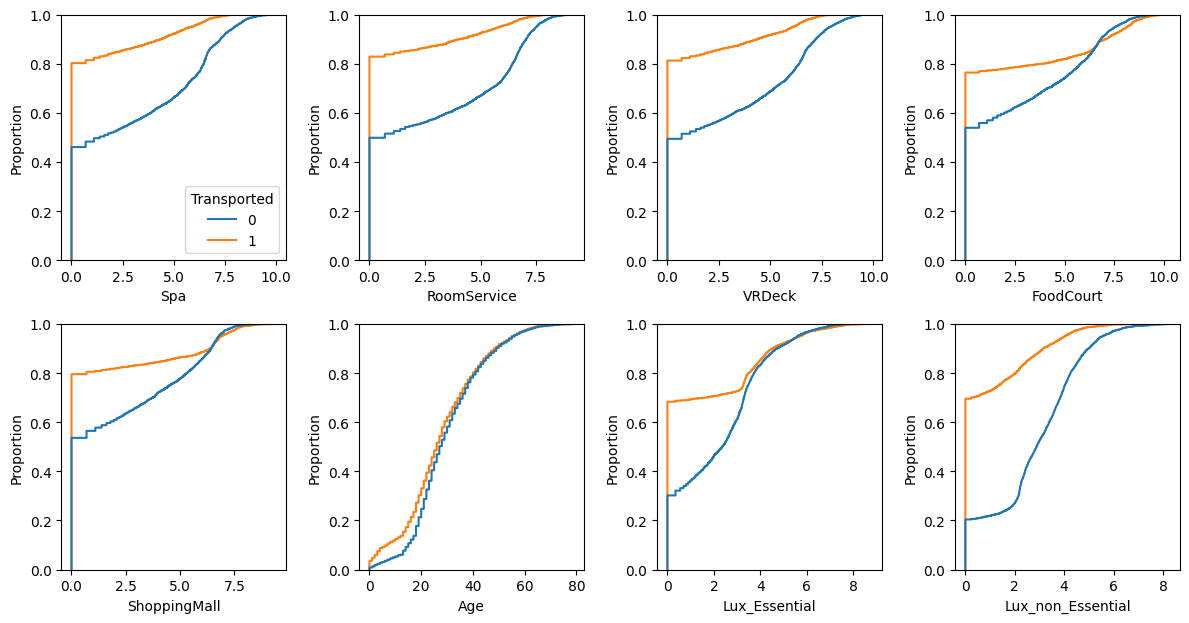

In [12]:
vars_list = Luxury_Features + ['Age', 'Lux_Essential', 'Lux_non_Essential']
get_ecdfplots(df0, vars_list, target = 'Transported', ncols = 4)

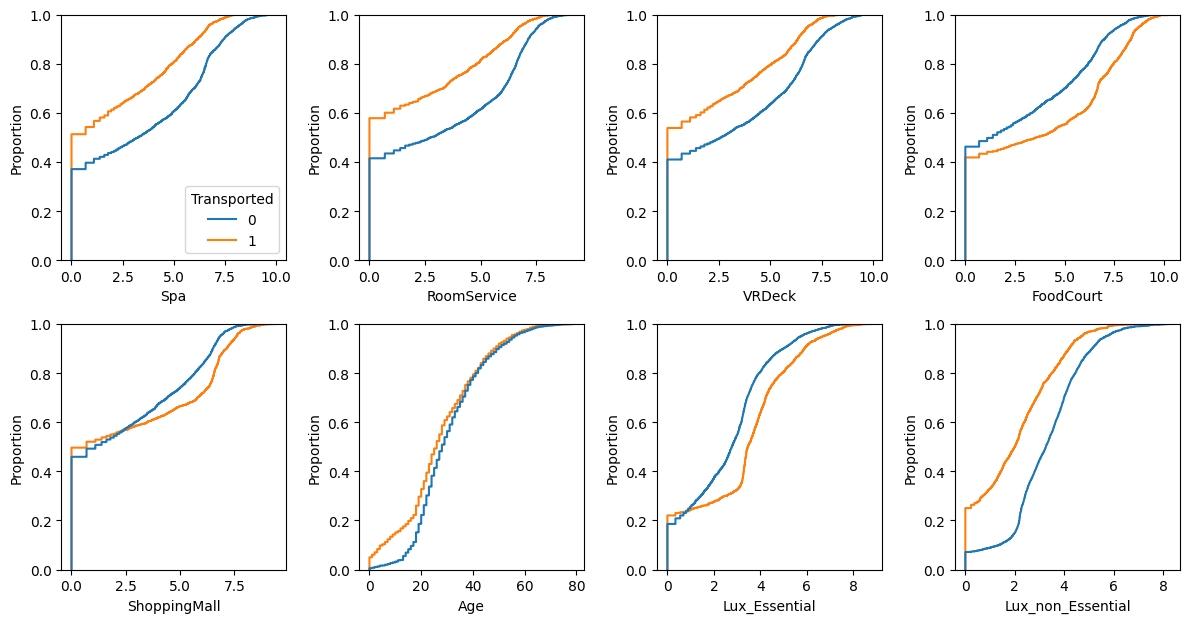

In [13]:
mask = df0['CryoSleep'] == 0
get_ecdfplots(df0[mask], vars_list, target = 'Transported', ncols = 4)

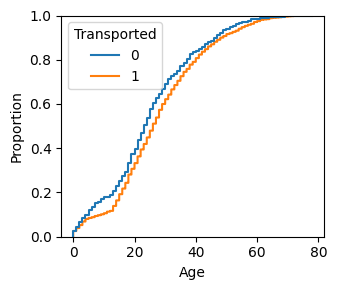

In [14]:
mask = df0['CryoSleep'] == 1
get_ecdfplots(df0[mask], ['Age'], target = 'Transported', ncols = 3)

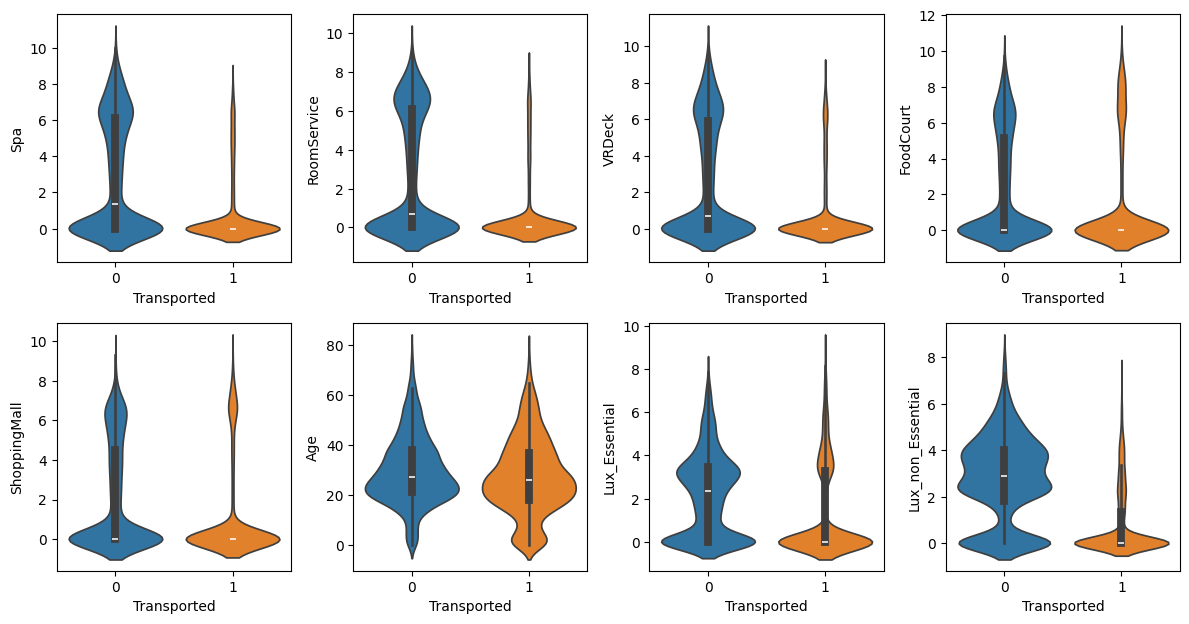

In [15]:
df01 = df0.copy()
df01['CryoSleep'] = df01['CryoSleep'].astype(bool).astype(str)
df01['Transported'] = df01['Transported'].astype(str)
get_violinplots(df01, vars_list, target1 = 'Transported', ncols = 4)

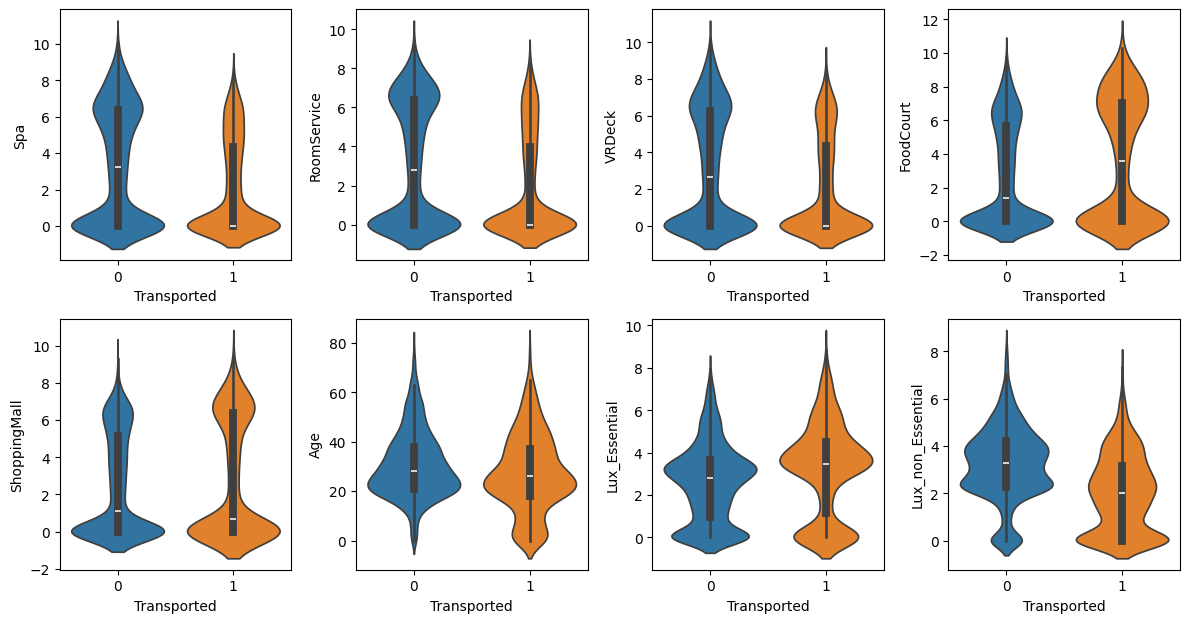

In [16]:
get_violinplots(df01[df01['CryoSleep'] == 'False'], vars_list, target1 = 'Transported', ncols = 4)

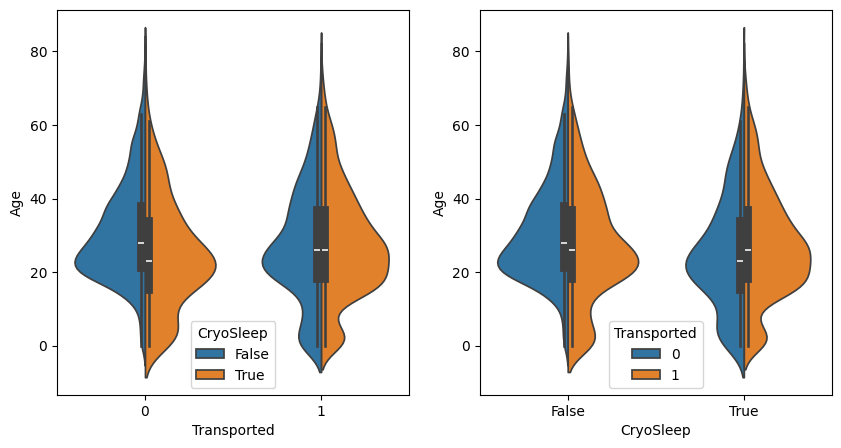

In [17]:
get_violinplots(df01, ['Age'], target1 = 'Transported', ncols = 1, target2 = 'CryoSleep')

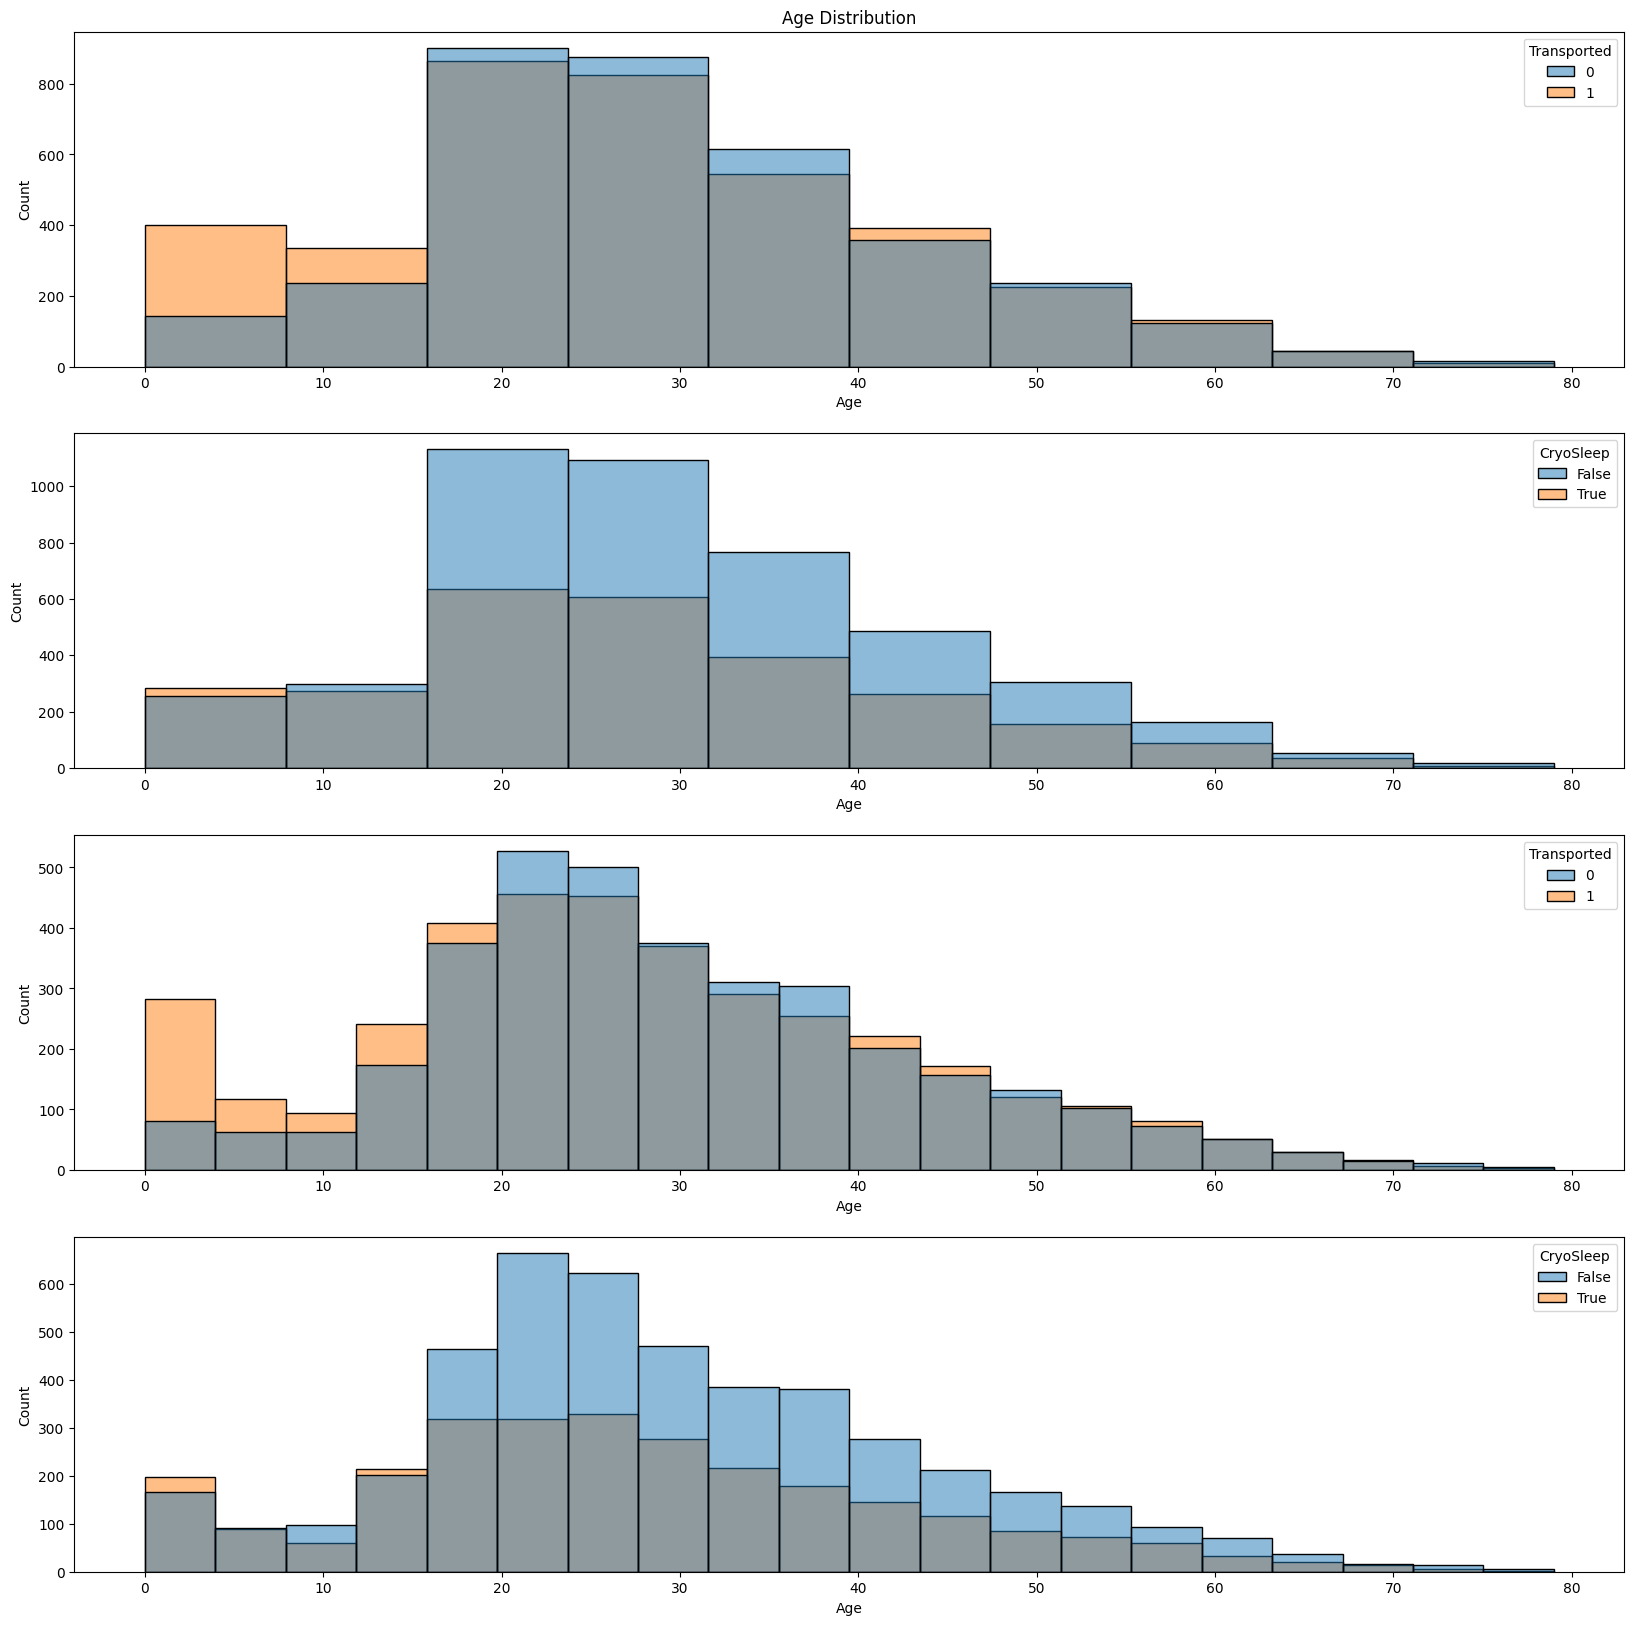

In [18]:
plot_hists_by_Cryo_and_Transported(df0, 'Age')

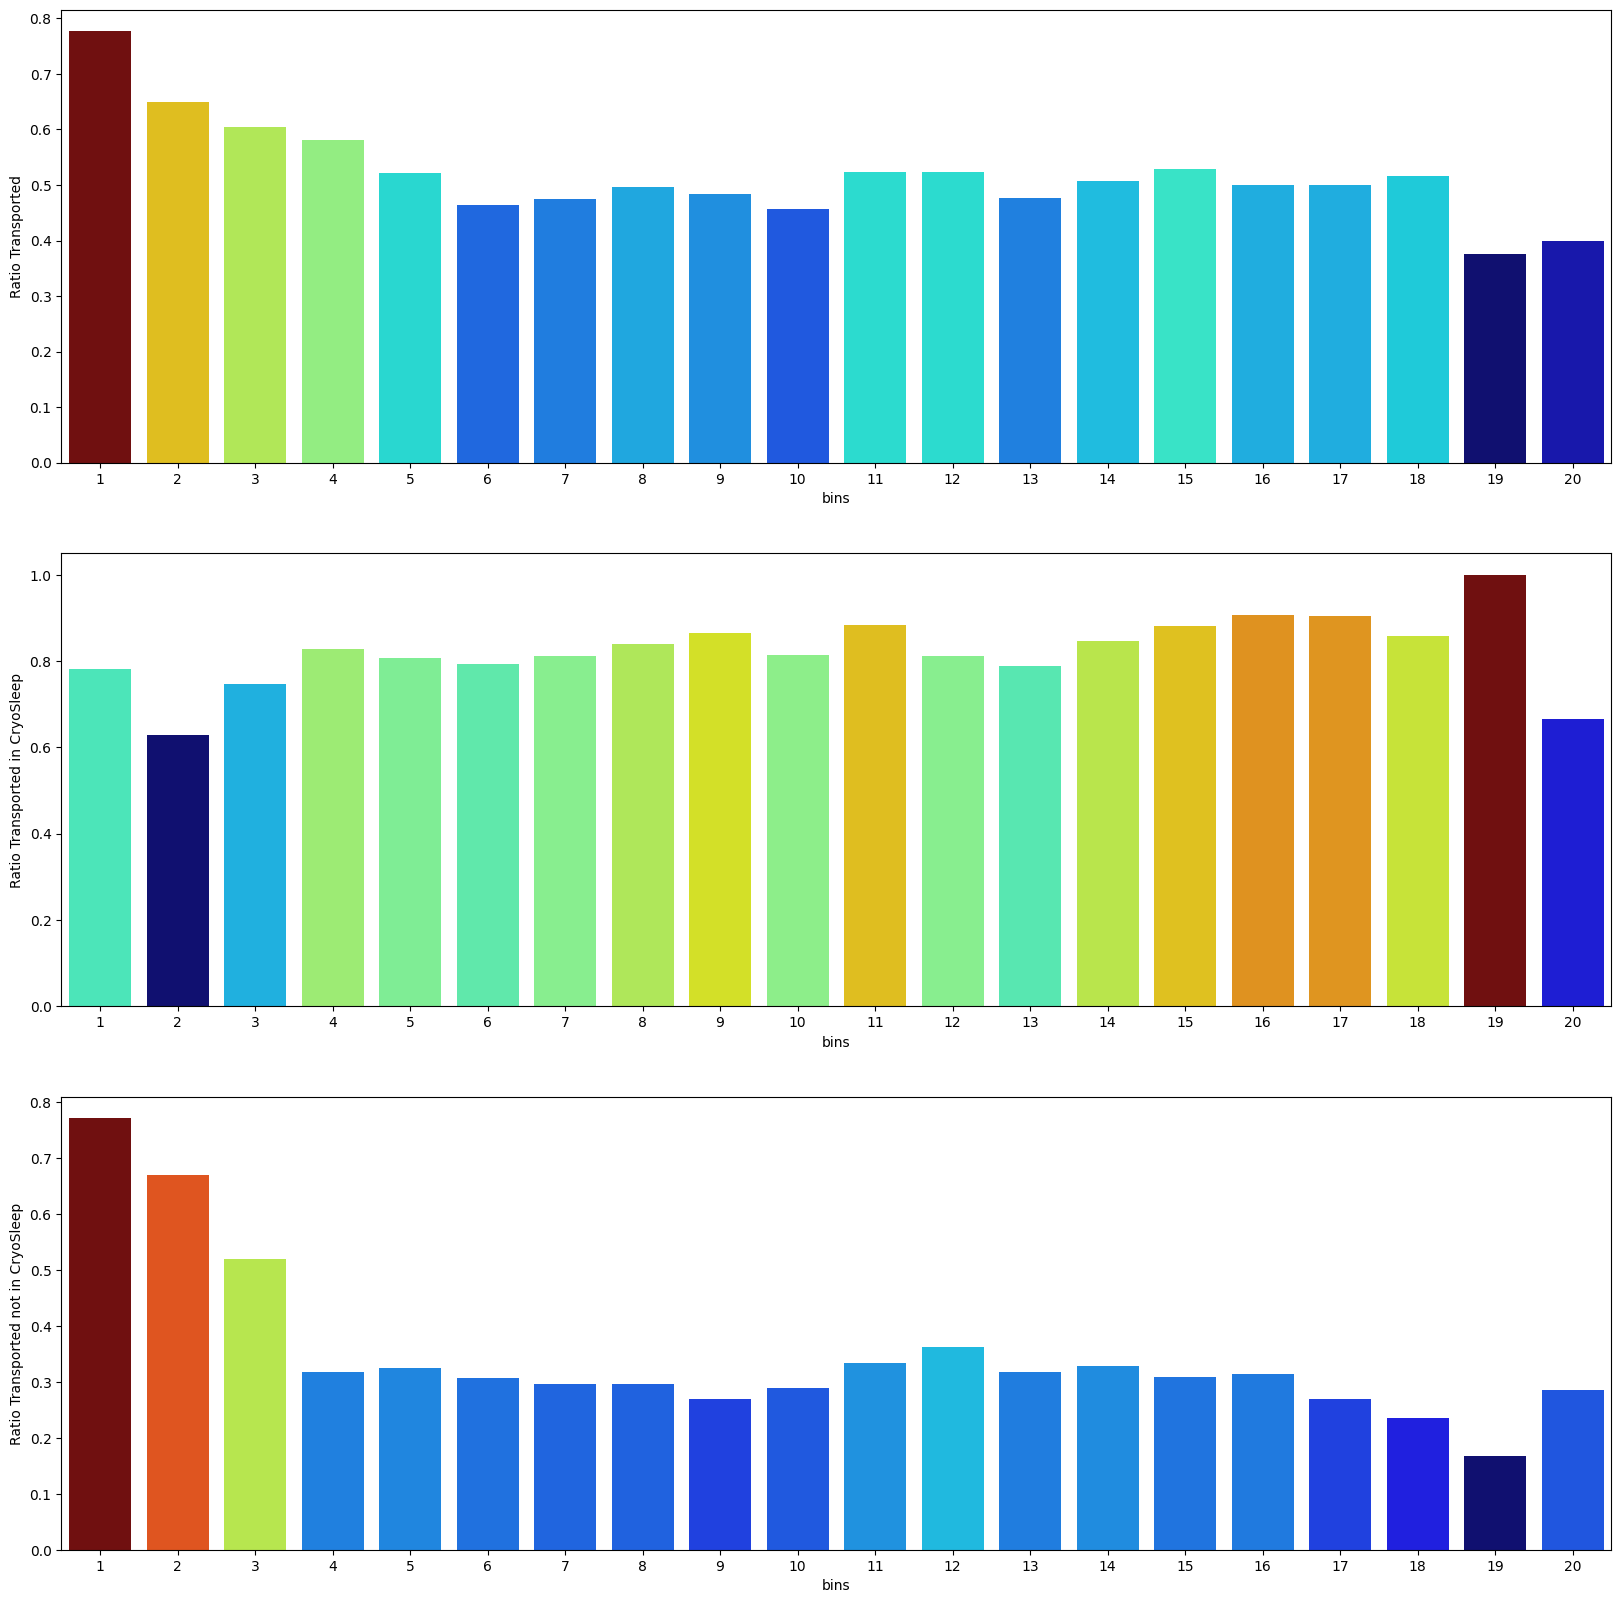

In [19]:
bin_ranges, df_num_groups = plot_ratios_by_Cryo_and_Transported(df0, 'Age', nbins = 20)

In [20]:
str(bin_ranges)

'[(np.float64(0.0), np.float64(4.0)), (np.float64(4.0), np.float64(7.9)), (np.float64(7.9), np.float64(11.9)), (np.float64(11.9), np.float64(15.8)), (np.float64(15.8), np.float64(19.8)), (np.float64(19.8), np.float64(23.7)), (np.float64(23.7), np.float64(27.6)), (np.float64(27.6), np.float64(31.6)), (np.float64(31.6), np.float64(35.6)), (np.float64(35.6), np.float64(39.5)), (np.float64(39.5), np.float64(43.4)), (np.float64(43.4), np.float64(47.4)), (np.float64(47.4), np.float64(51.4)), (np.float64(51.4), np.float64(55.3)), (np.float64(55.3), np.float64(59.2)), (np.float64(59.2), np.float64(63.2)), (np.float64(63.2), np.float64(67.2)), (np.float64(67.2), np.float64(71.1)), (np.float64(71.1), np.float64(75.0)), (np.float64(75.0), np.float64(79.0))]'

In [21]:
# _, _ = plot_ratios_by_Cryo_and_Transported(df0, 'Age_Bin', nbins = bins, cat = True)

In [22]:
mapping_age = {1: 'Child', 2: 'Teen', 3: '19-21', 4: 'Low 20s', 5: '25-27', 6: '28-30', 7: 'Low 30s', 8: '36-41', 9: '42-49', 10: '50 and above'}
df0['Age_Brackets'] = df0['Age_Bin'].map(mapping_age)

bin_edges = [0, 2, 5, 13, 20, 36, 46, 65, 90]
LifeStages_choices = ['Infant', 'Toddler', 'Child', 'Teen', 'Young Adult', 'Young middle aged', 'Older middle aged', 'Senior']
# LifeStages_conds = [df0.Age.between(bin_edges[i], bin_edges[i + 1] - 0.1) for i in range(len(bin_edges) - 1)]

Brackets_choices = ['Child', 'Teen', '19-21', 'Low 20s', '25-27', '28-30', 'Low 30s', '36-41', '42-49', '50 and above']
# Brackets_conds = [df0.Age_Bin == i for i in range(1, len(Brackets_choices) + 1)]

# df0['Age_LifeStages'] = np.select(LifeStages_conds, LifeStages_choices)
# df0['Age_Brackets'] = np.select(Brackets_conds, Brackets_choices)
df0['Age_LifeStages'] = pd.cut(df0.Age, bins = bin_edges, labels = LifeStages_choices, right = False, include_lowest = True)

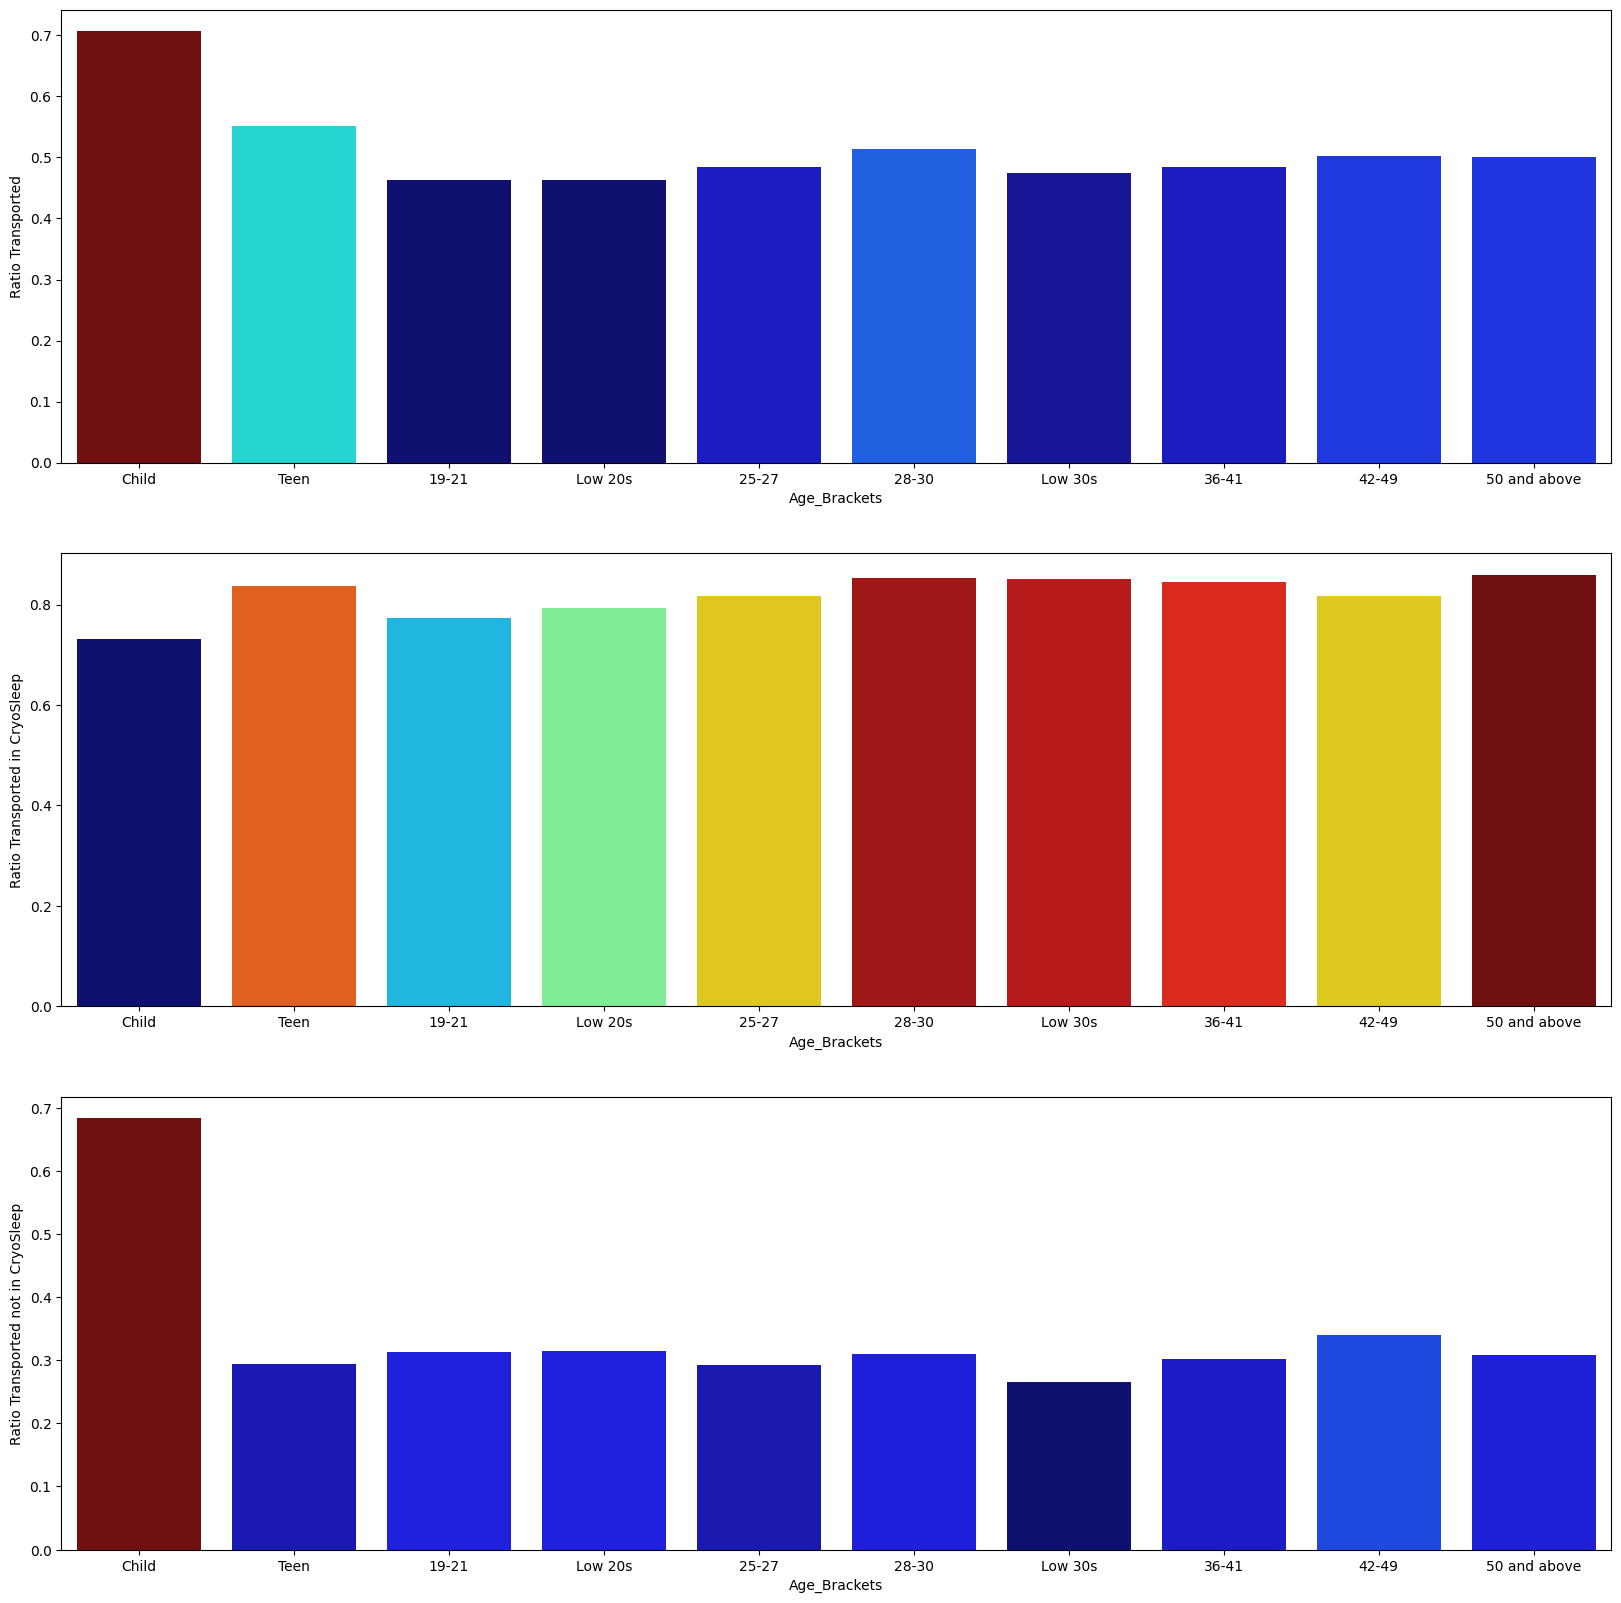

In [23]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'Age_Brackets', nbins = bins, cat = True, cat_bins = Brackets_choices)

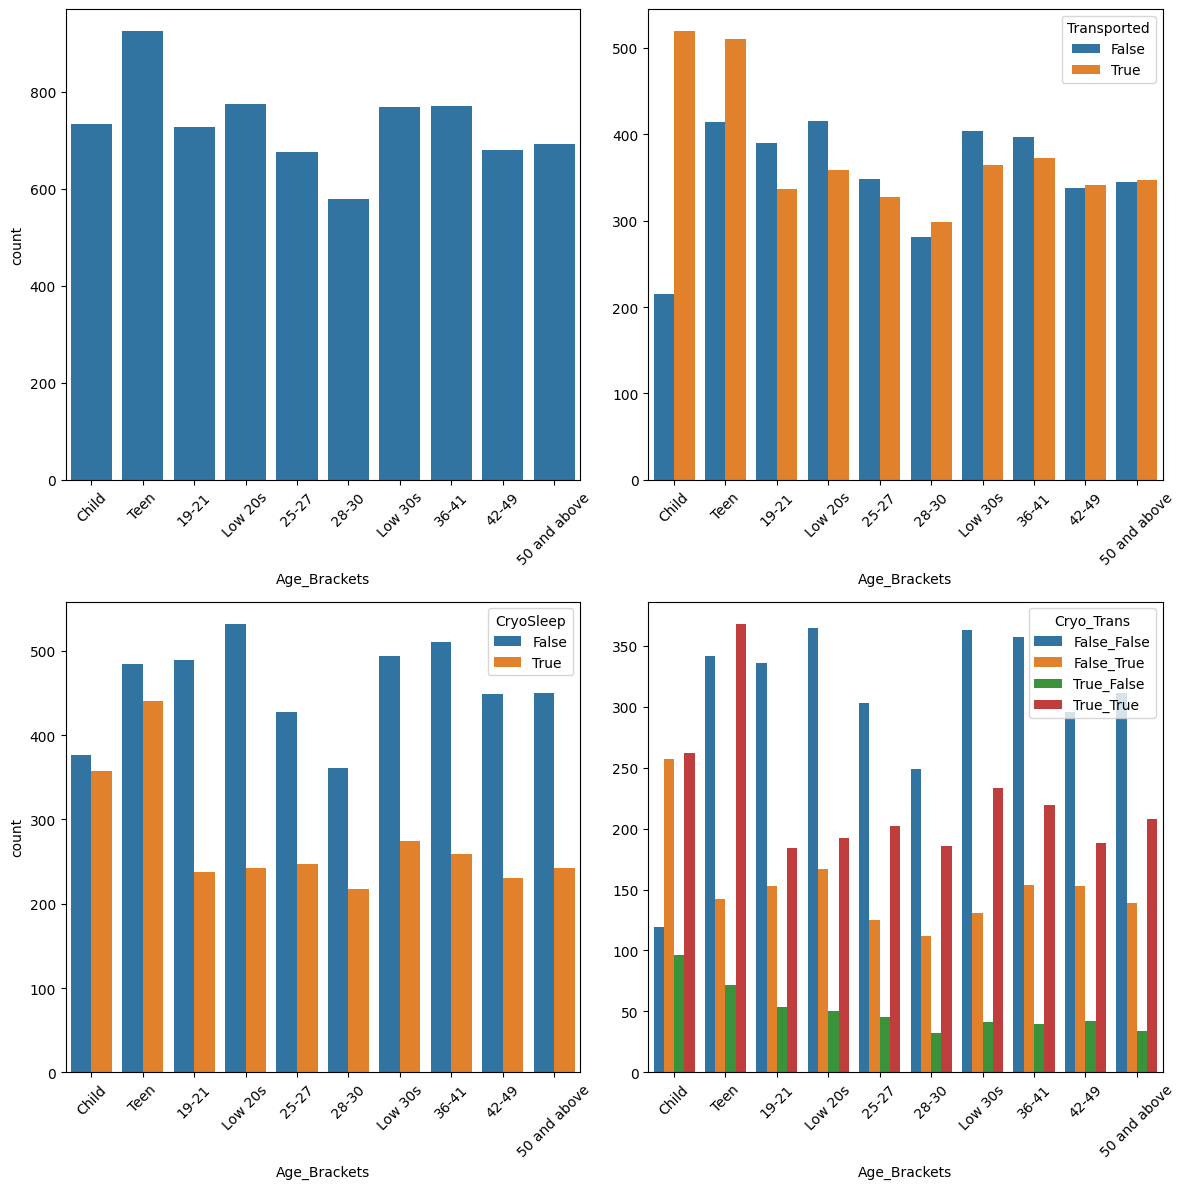

In [24]:
plot_CryoTrans_Counts(df0, 'Age_Brackets', Brackets_choices)

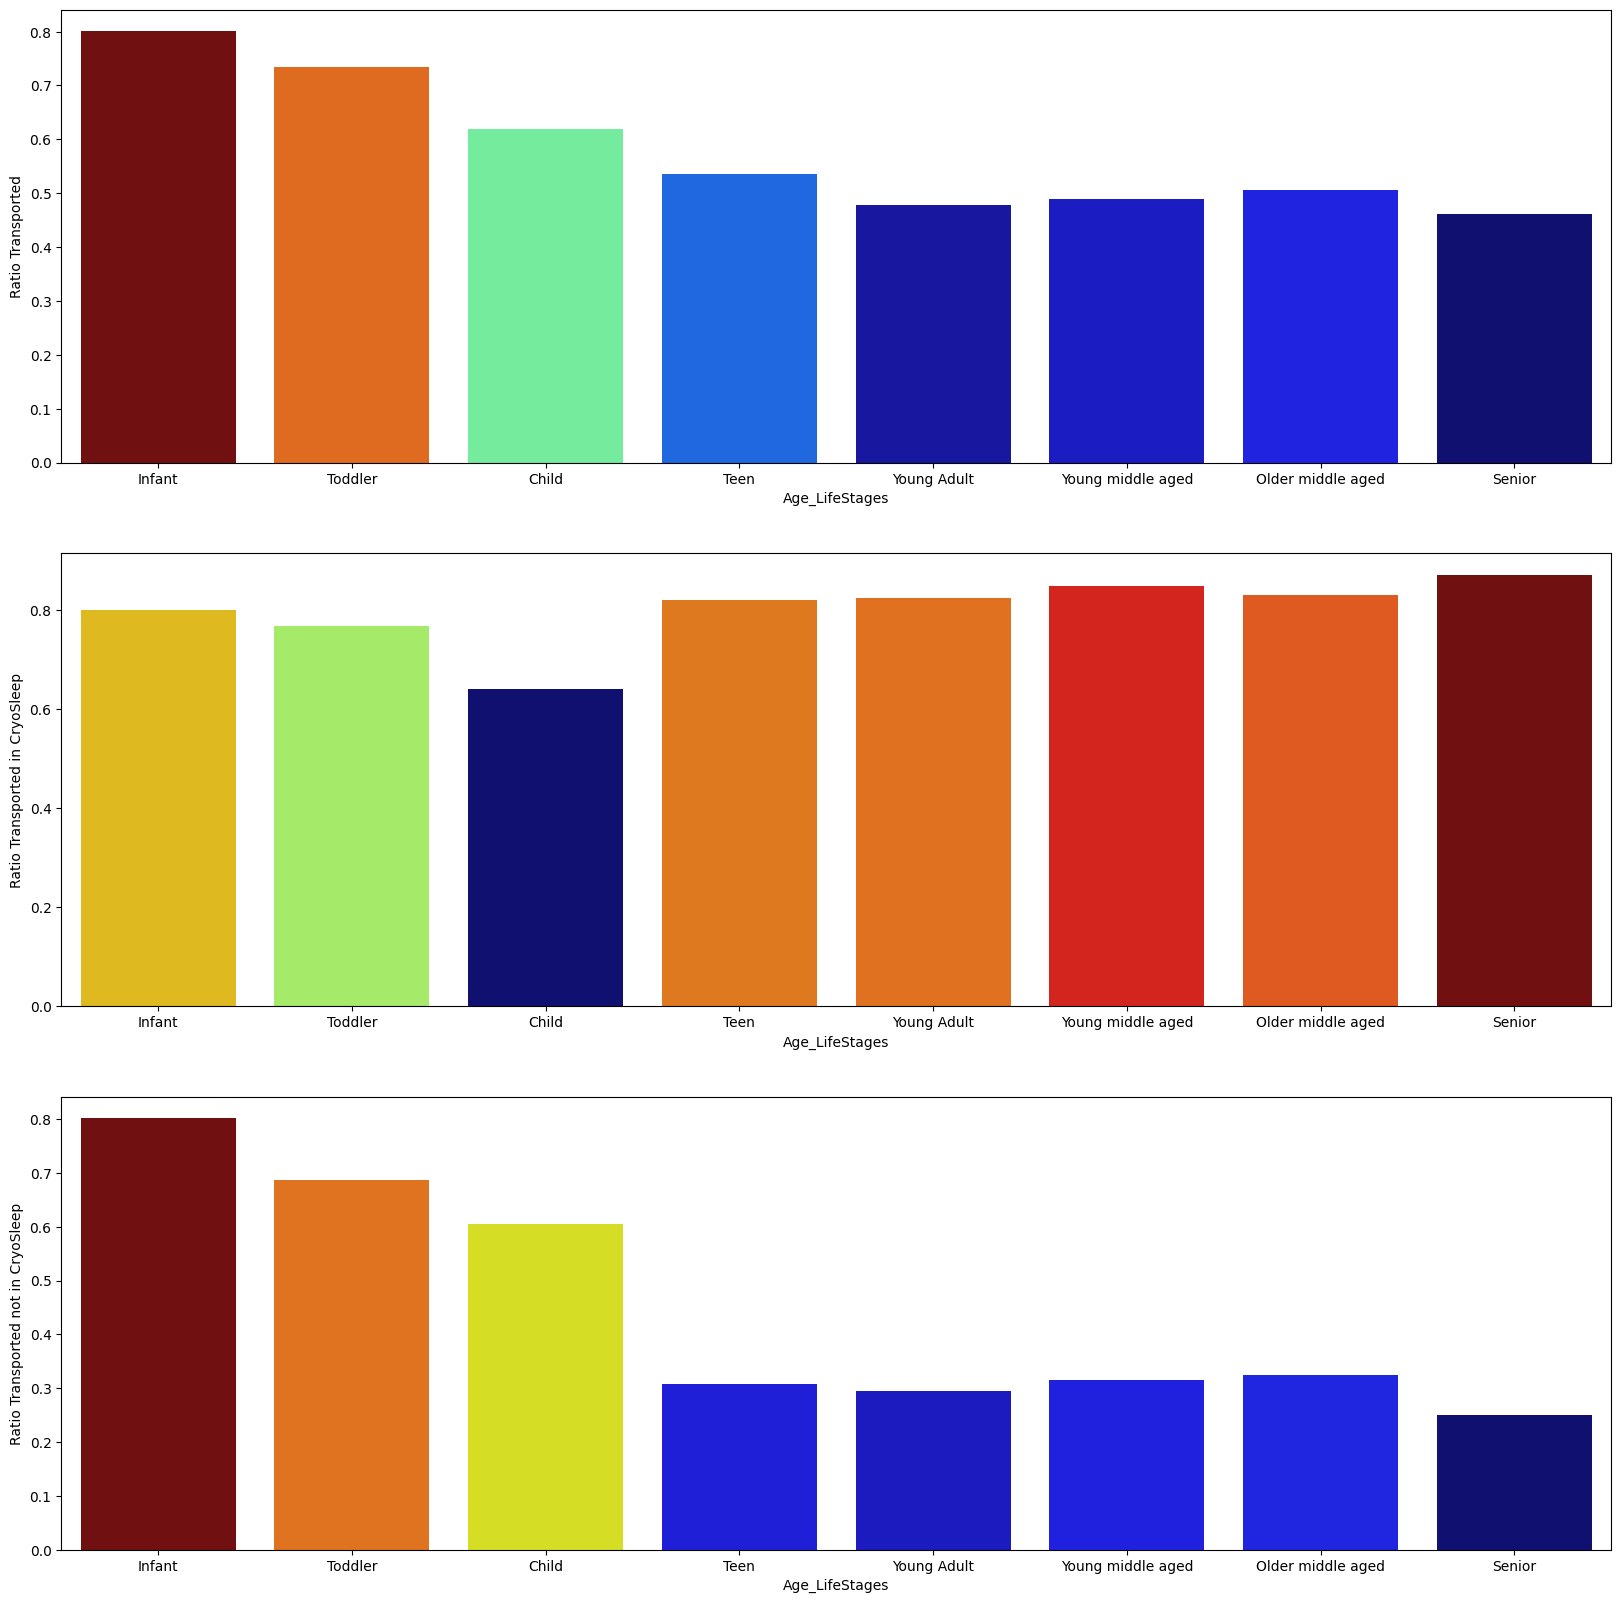

In [25]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'Age_LifeStages', nbins = bins, cat = True, cat_bins = LifeStages_choices)

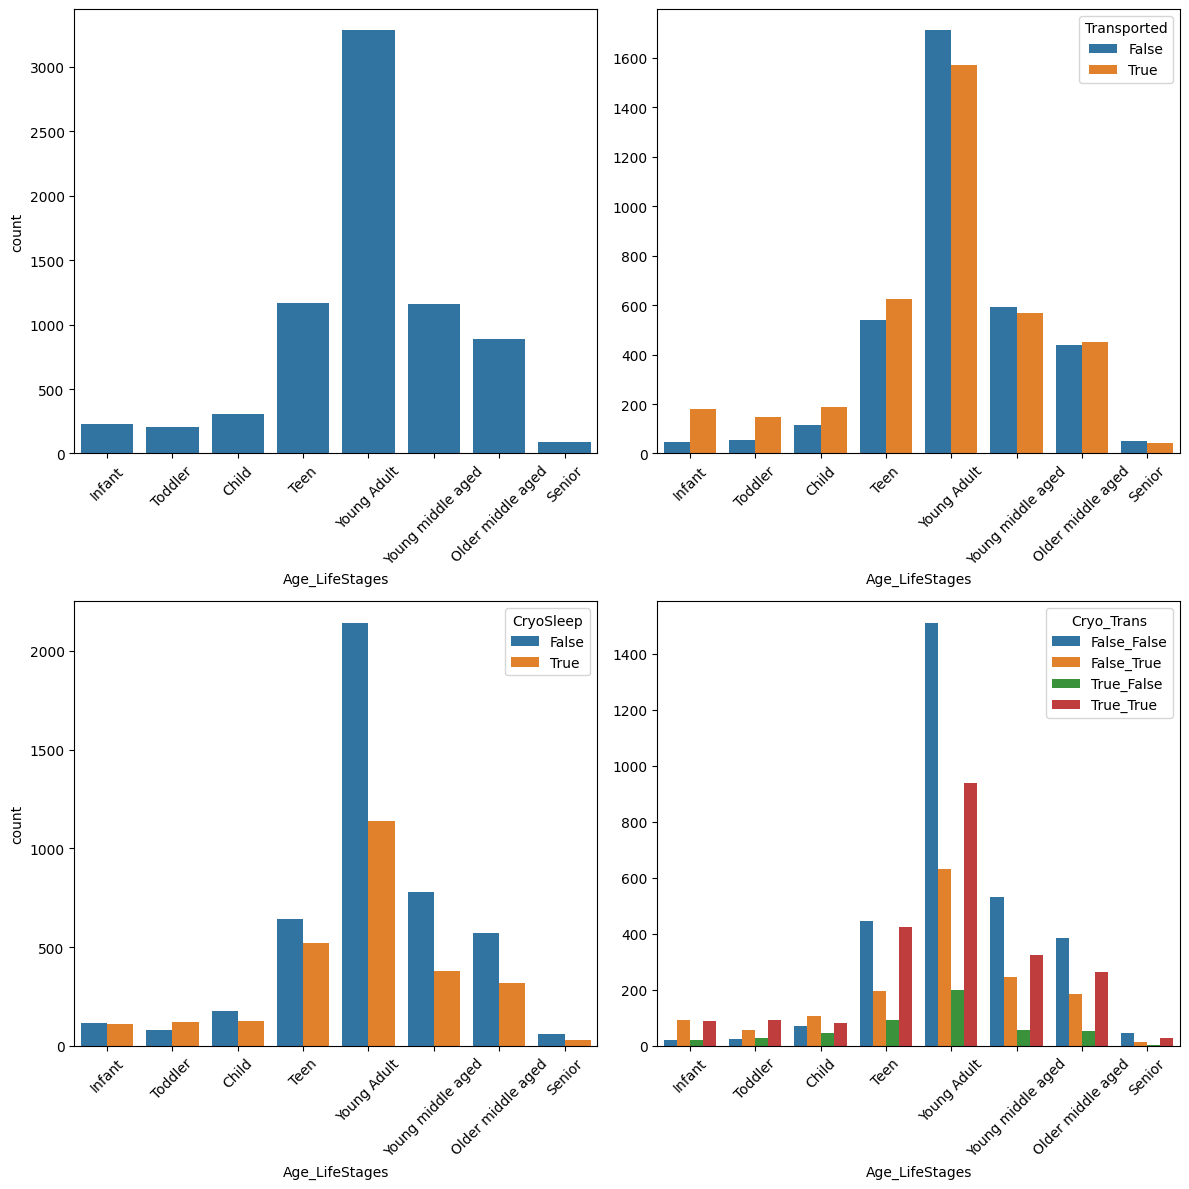

In [26]:
plot_CryoTrans_Counts(df0, 'Age_LifeStages', LifeStages_choices)

### Observations
* Passengers that spend very little or none on Luxury items are more likely to be transported
* However, passengers in CryoSleep are more likely to be transported and of course, cannot be using any of the luxury items.
* Correcting for CryoSleep, we see that among passengers not in Cryosleep, those that spend little in Spa, RoomSevice, and VRDeck are more likely to be transported compared to big spenders. However, it is the opposite for FoodCourt and ShoppingMall
* Among under age passengers that were not transported, they are a lot more likely to be in Cryosleep. In other words, young passengers that are not in Cryosleep are more likely to transported.
* There is a stronger correlation between being transported and the average of "non-essential luxury". Averaging "essential luxury" (FoodCourt and ShoppingMall) doesn't have the same effect

### Now, let's examine the effect of these features on few ML algorithms
The reported score below is the kfold accuracy score

In [27]:
nfolds = 10

In [28]:
df0.CryoSleep = df0.CryoSleep.astype(int)
df0.Transported = df0.Transported.astype(int)

In [29]:
basic_list = ['CryoSleep']
features_list = ['Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'Spa']
List2:  ['CryoSleep', 'Spa', 'RoomService']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck']
List4:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt']
List5:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall']
List6:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std,List5_mean,List5_std,List6_mean,List6_std
Naive Bayes,0.7215,0.0179,0.7215,0.0179,0.7308,0.0219,0.7606,0.0242,0.7576,0.0242,0.7502,0.0222,0.7502,0.0216
Logistic Regression,0.7215,0.0179,0.7215,0.0179,0.7315,0.0190,0.7566,0.0224,0.7673,0.0199,0.7700,0.0189,0.7699,0.0190
LightGBM,0.7215,0.0179,0.7196,0.0193,0.7337,0.0215,0.7725,0.0223,0.7927,0.0170,0.7943,0.0198,0.7951,0.0195
CatBoost,0.7215,0.0179,0.7214,0.0177,0.7318,0.0216,0.7740,0.0212,0.7936,0.0149,0.7961,0.0164,0.7968,0.0159


In [30]:
basic_list = ['CryoSleep']
features_list = ['Lux_non_Essential', 'Lux_Essential', 'Age']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'Lux_non_Essential']
List2:  ['CryoSleep', 'Lux_non_Essential', 'Lux_Essential']
List3:  ['CryoSleep', 'Lux_non_Essential', 'Lux_Essential', 'Age']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7215,0.0179,0.7495,0.0216,0.7367,0.0231,0.7376,0.0220
Logistic Regression,0.7215,0.0179,0.7573,0.0244,0.7670,0.0136,0.7681,0.0139
LightGBM,0.7215,0.0179,0.7659,0.0216,0.7729,0.0192,0.7710,0.0209
CatBoost,0.7215,0.0179,0.7654,0.0208,0.7729,0.0196,0.7729,0.0212


In [31]:
basic_list = ['CryoSleep']
features_list = ['Lux_non_Essential', 'FoodCourt', 'ShoppingMall', 'Age']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'Lux_non_Essential']
List2:  ['CryoSleep', 'Lux_non_Essential', 'FoodCourt']
List3:  ['CryoSleep', 'Lux_non_Essential', 'FoodCourt', 'ShoppingMall']
List4:  ['CryoSleep', 'Lux_non_Essential', 'FoodCourt', 'ShoppingMall', 'Age']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std
Naive Bayes,0.7215,0.0179,0.7495,0.0216,0.7423,0.0240,0.7383,0.0207,0.7382,0.0218
Logistic Regression,0.7215,0.0179,0.7573,0.0244,0.7671,0.0204,0.7700,0.0181,0.7697,0.0182
LightGBM,0.7215,0.0179,0.7659,0.0216,0.7849,0.0183,0.7890,0.0176,0.7886,0.0183
CatBoost,0.7215,0.0179,0.7654,0.0208,0.7868,0.0148,0.7916,0.0161,0.7890,0.0168


In [32]:
basic_list = ['CryoSleep', 'VRDeck']
features_list = ['Lux_non_Essential', 'FoodCourt', 'ShoppingMall', 'Age']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'VRDeck']
List1:  ['CryoSleep', 'VRDeck', 'Lux_non_Essential']
List2:  ['CryoSleep', 'VRDeck', 'Lux_non_Essential', 'FoodCourt']
List3:  ['CryoSleep', 'VRDeck', 'Lux_non_Essential', 'FoodCourt', 'ShoppingMall']
List4:  ['CryoSleep', 'VRDeck', 'Lux_non_Essential', 'FoodCourt', 'ShoppingMall', 'Age']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std
Naive Bayes,0.7215,0.0179,0.7624,0.0221,0.7550,0.0217,0.7391,0.0208,0.7402,0.0226
Logistic Regression,0.7215,0.0179,0.7568,0.0241,0.7676,0.0202,0.7697,0.0179,0.7697,0.0179
LightGBM,0.7214,0.0177,0.7721,0.0205,0.7876,0.0160,0.7895,0.0156,0.7897,0.0161
CatBoost,0.7221,0.0179,0.7715,0.0209,0.7879,0.0158,0.7912,0.0148,0.7904,0.0169


In [33]:
basic_list = ['CryoSleep']
features_list = ['Age', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'Age']
List2:  ['CryoSleep', 'Age', 'ShoppingMall']
List3:  ['CryoSleep', 'Age', 'ShoppingMall', 'FoodCourt']
List4:  ['CryoSleep', 'Age', 'ShoppingMall', 'FoodCourt', 'VRDeck']
List5:  ['CryoSleep', 'Age', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService']
List6:  ['CryoSleep', 'Age', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std,List5_mean,List5_std,List6_mean,List6_std
Naive Bayes,0.7215,0.0179,0.7215,0.0179,0.7240,0.0181,0.7357,0.0179,0.7025,0.0254,0.7202,0.0197,0.7502,0.0216
Logistic Regression,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7256,0.0154,0.7301,0.0165,0.7406,0.0181,0.7699,0.0190
LightGBM,0.7215,0.0179,0.7404,0.0248,0.7471,0.0247,0.7592,0.0200,0.7659,0.0168,0.7807,0.0163,0.7951,0.0195
CatBoost,0.7215,0.0179,0.7390,0.0219,0.7458,0.0227,0.7603,0.0183,0.7733,0.0176,0.7811,0.0150,0.7962,0.0158


In [34]:
df1 = df0.copy()
df1.Age_LifeStages = (df1.Age_LifeStages.map({val: idx for idx, val in enumerate(LifeStages_choices)})).astype(int)
df1.Age_Brackets = (df1.Age_Brackets.map({val: idx for idx, val in enumerate(Brackets_choices)})).astype(int)

In [35]:
# basic_list = ['CryoSleep']
features_list = ['Age_LifeStages', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'Age_LifeStages']
List2:  ['CryoSleep', 'Age_LifeStages', 'ShoppingMall']
List3:  ['CryoSleep', 'Age_LifeStages', 'ShoppingMall', 'FoodCourt']
List4:  ['CryoSleep', 'Age_LifeStages', 'ShoppingMall', 'FoodCourt', 'VRDeck']
List5:  ['CryoSleep', 'Age_LifeStages', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService']
List6:  ['CryoSleep', 'Age_LifeStages', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std,List5_mean,List5_std,List6_mean,List6_std
Naive Bayes,0.7215,0.0179,0.7353,0.0193,0.7371,0.0207,0.7400,0.0251,0.7099,0.0271,0.7202,0.0190,0.7477,0.0207
Logistic Regression,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7269,0.0157,0.7316,0.0172,0.7456,0.0189,0.7688,0.0186
LightGBM,0.7215,0.0179,0.7404,0.0248,0.7473,0.0241,0.7643,0.0201,0.7693,0.0160,0.7815,0.0166,0.7947,0.0197
CatBoost,0.7215,0.0179,0.7404,0.0248,0.7473,0.0259,0.7629,0.0214,0.7747,0.0216,0.7819,0.0180,0.7960,0.0167


In [36]:
basic_list = ['CryoSleep']
features_list = ['Age_Brackets', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'Age_Brackets']
List2:  ['CryoSleep', 'Age_Brackets', 'ShoppingMall']
List3:  ['CryoSleep', 'Age_Brackets', 'ShoppingMall', 'FoodCourt']
List4:  ['CryoSleep', 'Age_Brackets', 'ShoppingMall', 'FoodCourt', 'VRDeck']
List5:  ['CryoSleep', 'Age_Brackets', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService']
List6:  ['CryoSleep', 'Age_Brackets', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std,List5_mean,List5_std,List6_mean,List6_std
Naive Bayes,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7032,0.0251,0.7206,0.0195,0.7509,0.0221
Logistic Regression,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7249,0.0162,0.7307,0.0171,0.7411,0.0171,0.7701,0.0185
LightGBM,0.7215,0.0179,0.7404,0.0248,0.7482,0.0243,0.7614,0.0200,0.7691,0.0175,0.7802,0.0165,0.7949,0.0179
CatBoost,0.7215,0.0179,0.7404,0.0248,0.7506,0.0253,0.7625,0.0224,0.7742,0.0222,0.7813,0.0193,0.7962,0.0168


In [37]:
df1['Infant'] = np.where(df1.Age_LifeStages == 0, 1, 0)
df1['Toddler'] = np.where(df1.Age_LifeStages == 1, 1, 0)
df1['Child'] = np.where(df1.Age_LifeStages == 2, 1, 0)
df1['Under_13'] = np.where(df1.Age_Brackets == 0, 1, 0)
df1['Teen'] = np.where(df1.Age_LifeStages == 3, 1, 0)
df1['Young Adult'] = np.where(df1.Age_LifeStages == 4, 1, 0)

In [38]:
basic_list = ['CryoSleep']
features_list = ['Infant', 'Toddler', 'Child', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'Infant']
List2:  ['CryoSleep', 'Infant', 'Toddler']
List3:  ['CryoSleep', 'Infant', 'Toddler', 'Child']
List4:  ['CryoSleep', 'Infant', 'Toddler', 'Child', 'ShoppingMall']
List5:  ['CryoSleep', 'Infant', 'Toddler', 'Child', 'ShoppingMall', 'FoodCourt']
List6:  ['CryoSleep', 'Infant', 'Toddler', 'Child', 'ShoppingMall', 'FoodCourt', 'VRDeck']
List7:  ['CryoSleep', 'Infant', 'Toddler', 'Child', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService']
List8:  ['CryoSleep', 'Infant', 'Toddler', 'Child', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std,List5_mean,List5_std,List6_mean,List6_std,List7_mean,List7_std,List8_mean,List8_std
Naive Bayes,0.7215,0.0179,0.7311,0.0181,0.7353,0.0193,0.7404,0.0248,0.7404,0.0248,0.7404,0.0248,0.7404,0.0248,0.7404,0.0248,0.7363,0.0228
Logistic Regression,0.7215,0.0179,0.7311,0.0181,0.7311,0.0179,0.7311,0.0179,0.7309,0.0179,0.7331,0.0159,0.7456,0.0158,0.7525,0.0154,0.7681,0.0141
LightGBM,0.7215,0.0179,0.7311,0.0181,0.7353,0.0193,0.7404,0.0248,0.7498,0.0255,0.7625,0.0207,0.7655,0.0184,0.7786,0.0160,0.7946,0.0199
CatBoost,0.7215,0.0179,0.7311,0.0181,0.7353,0.0193,0.7404,0.0248,0.7488,0.0256,0.7607,0.0167,0.7714,0.0168,0.7823,0.0164,0.7966,0.0171


In [39]:
basic_list = ['CryoSleep']
features_list = ['Under_13', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'Under_13']
List2:  ['CryoSleep', 'Under_13', 'ShoppingMall']
List3:  ['CryoSleep', 'Under_13', 'ShoppingMall', 'FoodCourt']
List4:  ['CryoSleep', 'Under_13', 'ShoppingMall', 'FoodCourt', 'VRDeck']
List5:  ['CryoSleep', 'Under_13', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService']
List6:  ['CryoSleep', 'Under_13', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std,List5_mean,List5_std,List6_mean,List6_std
Naive Bayes,0.7215,0.0179,0.7404,0.0248,0.7404,0.0248,0.7404,0.0248,0.7404,0.0248,0.7211,0.0192,0.7449,0.0210
Logistic Regression,0.7215,0.0179,0.7361,0.0193,0.7337,0.0185,0.7243,0.0159,0.7382,0.0173,0.7618,0.0206,0.7729,0.0199
LightGBM,0.7215,0.0179,0.7404,0.0248,0.7487,0.0261,0.7615,0.0206,0.7706,0.0155,0.7797,0.0173,0.7947,0.0180
CatBoost,0.7215,0.0179,0.7404,0.0248,0.7487,0.0255,0.7635,0.0203,0.7741,0.0198,0.7841,0.0193,0.7957,0.0174


In [40]:
df1['Above_35'] = np.where(df1.Age_Bin > 7, 1, 0)

In [41]:
basic_list = ['CryoSleep']
features_list = ['Under_13', 'Above_35', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'Under_13']
List2:  ['CryoSleep', 'Under_13', 'Above_35']
List3:  ['CryoSleep', 'Under_13', 'Above_35', 'ShoppingMall']
List4:  ['CryoSleep', 'Under_13', 'Above_35', 'ShoppingMall', 'FoodCourt']
List5:  ['CryoSleep', 'Under_13', 'Above_35', 'ShoppingMall', 'FoodCourt', 'VRDeck']
List6:  ['CryoSleep', 'Under_13', 'Above_35', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService']
List7:  ['CryoSleep', 'Under_13', 'Above_35', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std,List5_mean,List5_std,List6_mean,List6_std,List7_mean,List7_std
Naive Bayes,0.7215,0.0179,0.7404,0.0248,0.7404,0.0248,0.7404,0.0248,0.7404,0.0248,0.7404,0.0248,0.7207,0.0205,0.7442,0.0210
Logistic Regression,0.7215,0.0179,0.7361,0.0193,0.7361,0.0193,0.7337,0.0185,0.7241,0.0159,0.7371,0.0166,0.7603,0.0215,0.7737,0.0198
LightGBM,0.7215,0.0179,0.7404,0.0248,0.7404,0.0248,0.7495,0.0255,0.7611,0.0213,0.7697,0.0161,0.7797,0.0170,0.7947,0.0180
CatBoost,0.7215,0.0179,0.7404,0.0248,0.7404,0.0248,0.7484,0.0267,0.7640,0.0212,0.7734,0.0211,0.7854,0.0185,0.7979,0.0157


In [42]:
basic_list = ['CryoSleep', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']

In [43]:
features_list = ['Age']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds, repeats = 5)

List0:  ['CryoSleep', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']
List1:  ['CryoSleep', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa', 'Age']


,List0_mean,List0_std,List1_mean,List1_std
Naive Bayes,0.7502,0.0169,0.7500,0.0163
Logistic Regression,0.7694,0.0157,0.7695,0.0157
LightGBM,0.7940,0.0155,0.7946,0.0161
CatBoost,0.7960,0.0147,0.7961,0.0143


In [44]:
features_list = ['Age_LifeStages']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds, repeats = 5)

List0:  ['CryoSleep', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']
List1:  ['CryoSleep', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa', 'Age_LifeStages']


,List0_mean,List0_std,List1_mean,List1_std
Naive Bayes,0.7502,0.0169,0.7482,0.0164
Logistic Regression,0.7694,0.0157,0.7688,0.0156
LightGBM,0.7940,0.0155,0.7947,0.0161
CatBoost,0.7960,0.0147,0.7962,0.0143


In [45]:
features_list = ['Age_Brackets']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds, repeats = 5)

List0:  ['CryoSleep', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']
List1:  ['CryoSleep', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa', 'Age_Brackets']


,List0_mean,List0_std,List1_mean,List1_std
Naive Bayes,0.7502,0.0169,0.7505,0.0164
Logistic Regression,0.7694,0.0157,0.7698,0.0155
LightGBM,0.7940,0.0155,0.7952,0.0158
CatBoost,0.7960,0.0147,0.7958,0.0140


In [46]:
features_list = ['Under_13', 'Teen', 'Young Adult']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds, repeats = 5)

List0:  ['CryoSleep', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa']
List1:  ['CryoSleep', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa', 'Under_13']
List2:  ['CryoSleep', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa', 'Under_13', 'Teen']
List3:  ['CryoSleep', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa', 'Under_13', 'Teen', 'Young Adult']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7502,0.0169,0.7446,0.0158,0.7453,0.0160,0.7451,0.0164
Logistic Regression,0.7694,0.0157,0.7729,0.0160,0.7724,0.0159,0.7735,0.0155
LightGBM,0.7940,0.0155,0.7951,0.0158,0.7951,0.0158,0.7951,0.0158
CatBoost,0.7960,0.0147,0.7964,0.0146,0.7963,0.0146,0.7957,0.0143


In [47]:
features_list = ['Above_35']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list + ['Under_13'], features_list, Kfold = nfolds, repeats = 5)

List0:  ['CryoSleep', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa', 'Under_13']
List1:  ['CryoSleep', 'ShoppingMall', 'FoodCourt', 'VRDeck', 'RoomService', 'Spa', 'Under_13', 'Above_35']


,List0_mean,List0_std,List1_mean,List1_std
Naive Bayes,0.7446,0.0158,0.7440,0.0160
Logistic Regression,0.7730,0.0159,0.7736,0.0158
LightGBM,0.7951,0.0158,0.7951,0.0158
CatBoost,0.7964,0.0146,0.7966,0.0140


# Closer look at Homeplanets, Destinations, and Decks

In [48]:
Features00 = Luxury_Features + ['Under_13']
Features0 = Luxury_Features + ['Age_LifeStages']
df0_base = df1[Features0 + ['Under_13']].copy(deep = True)
Features = ['CryoSleep', 'Transported', 'HomePlanet', 'Destination', 'deck']
df0 = df_clean[Features].copy(deep = True)
df0['HomePlanet_deck'] = df0.HomePlanet + df0.deck
Features = Features + ['HomePlanet_deck']

df0.Transported = df0.Transported.astype(int)
df0.CryoSleep = df0.CryoSleep.astype(int)

In [49]:
print(df0.HomePlanet.unique())
print(df0.Destination.unique())
print(df0.HomePlanet_deck.unique())

['Europa' 'Earth' 'Mars']
['TRAPPIST-1e' 'PSO J318.5-22' '55 Cancri e']
['EuropaB' 'EarthF' 'EuropaA' 'EarthG' 'MarsF' 'EarthE' 'EuropaC'
 'EuropaD' 'MarsD' 'MarsE' 'EuropaE' 'EuropaT']


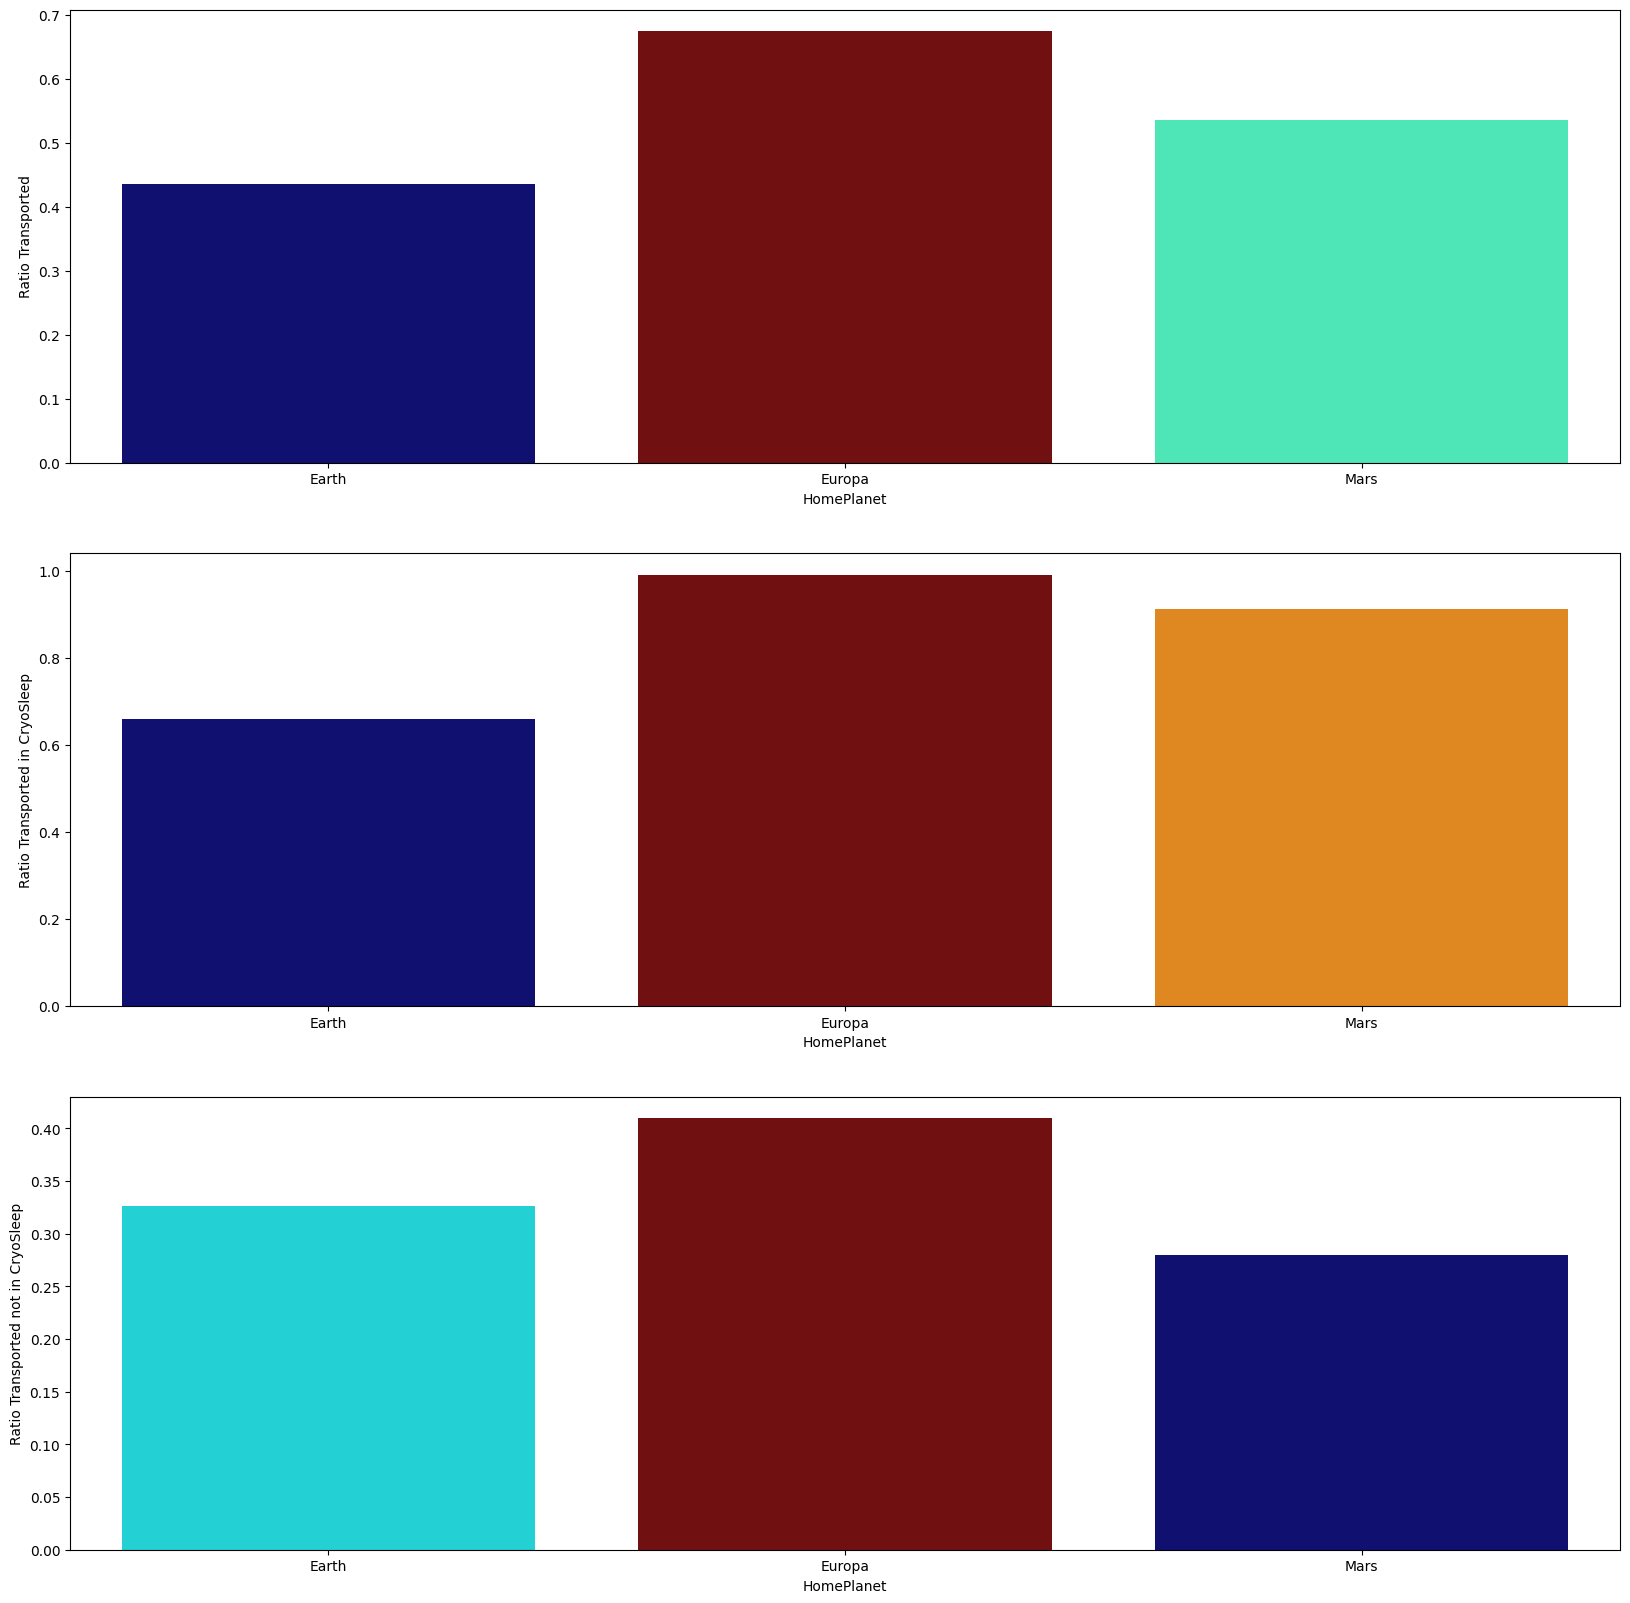

In [50]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'HomePlanet', cat = True)

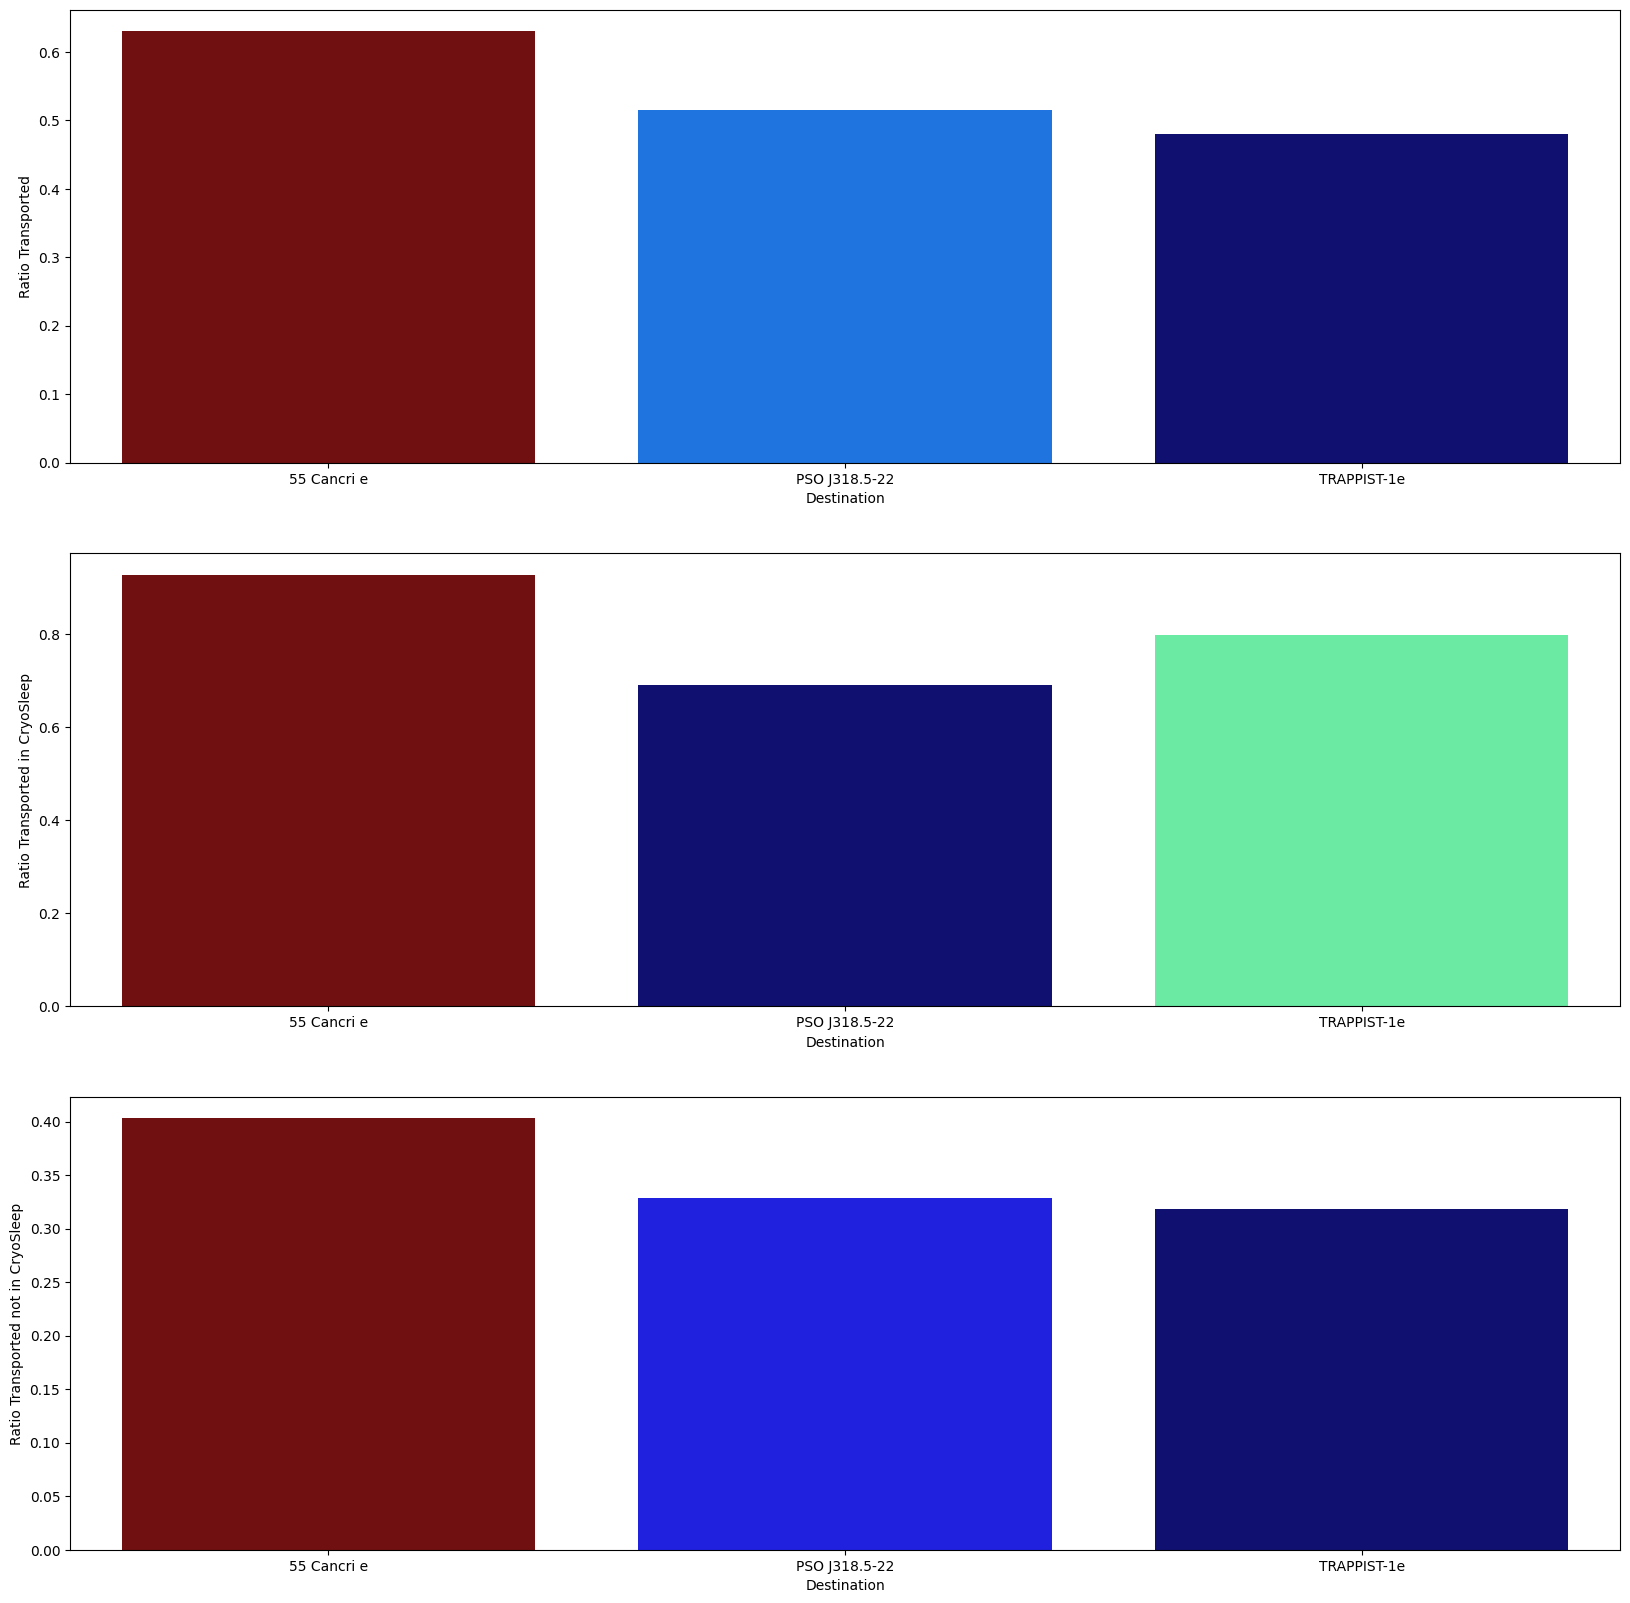

In [51]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'Destination', cat = True)

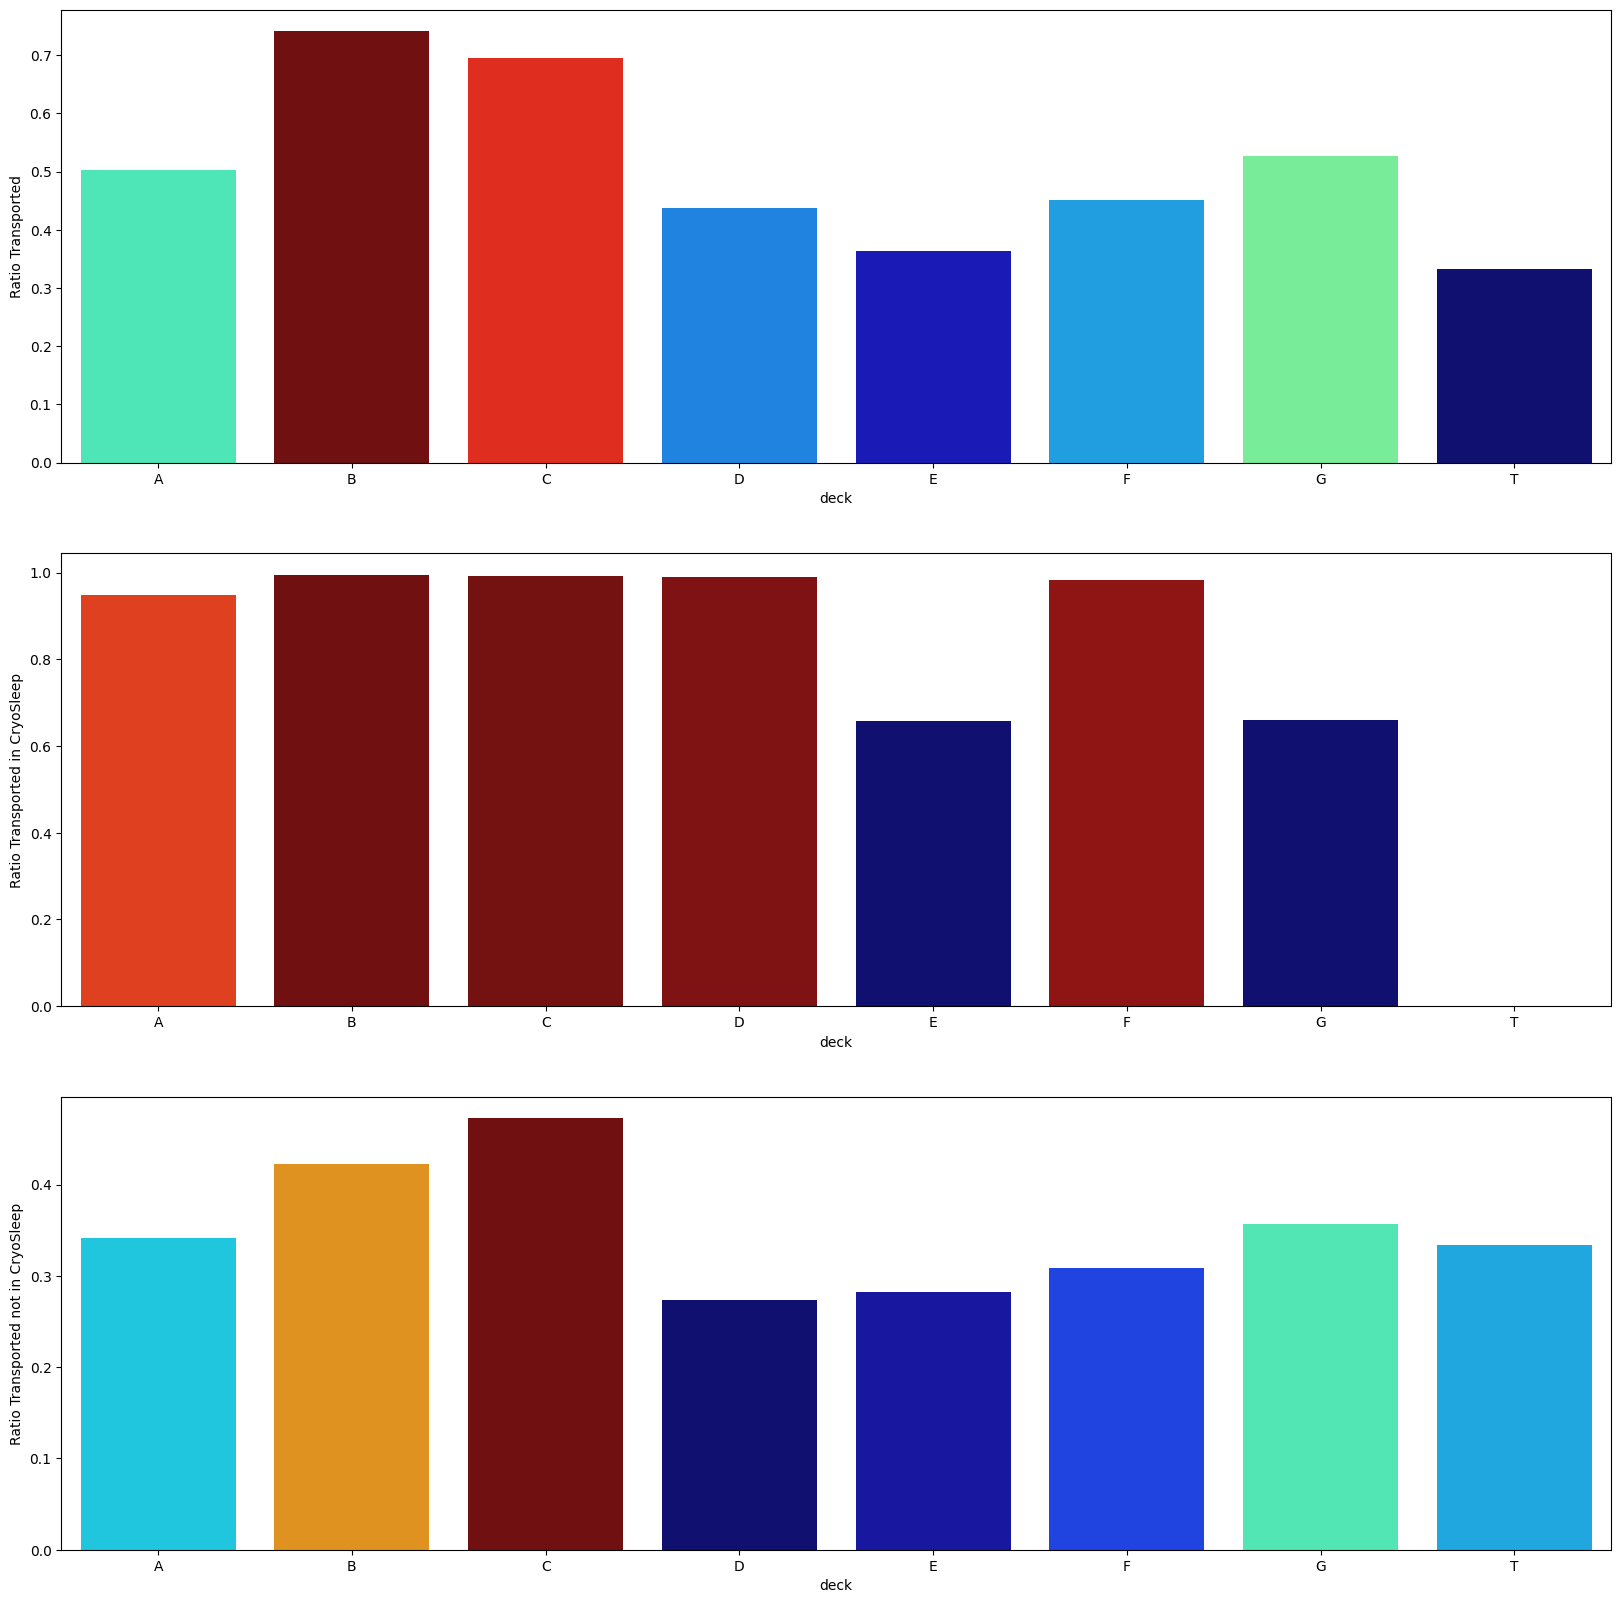

In [52]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'deck', cat = True)

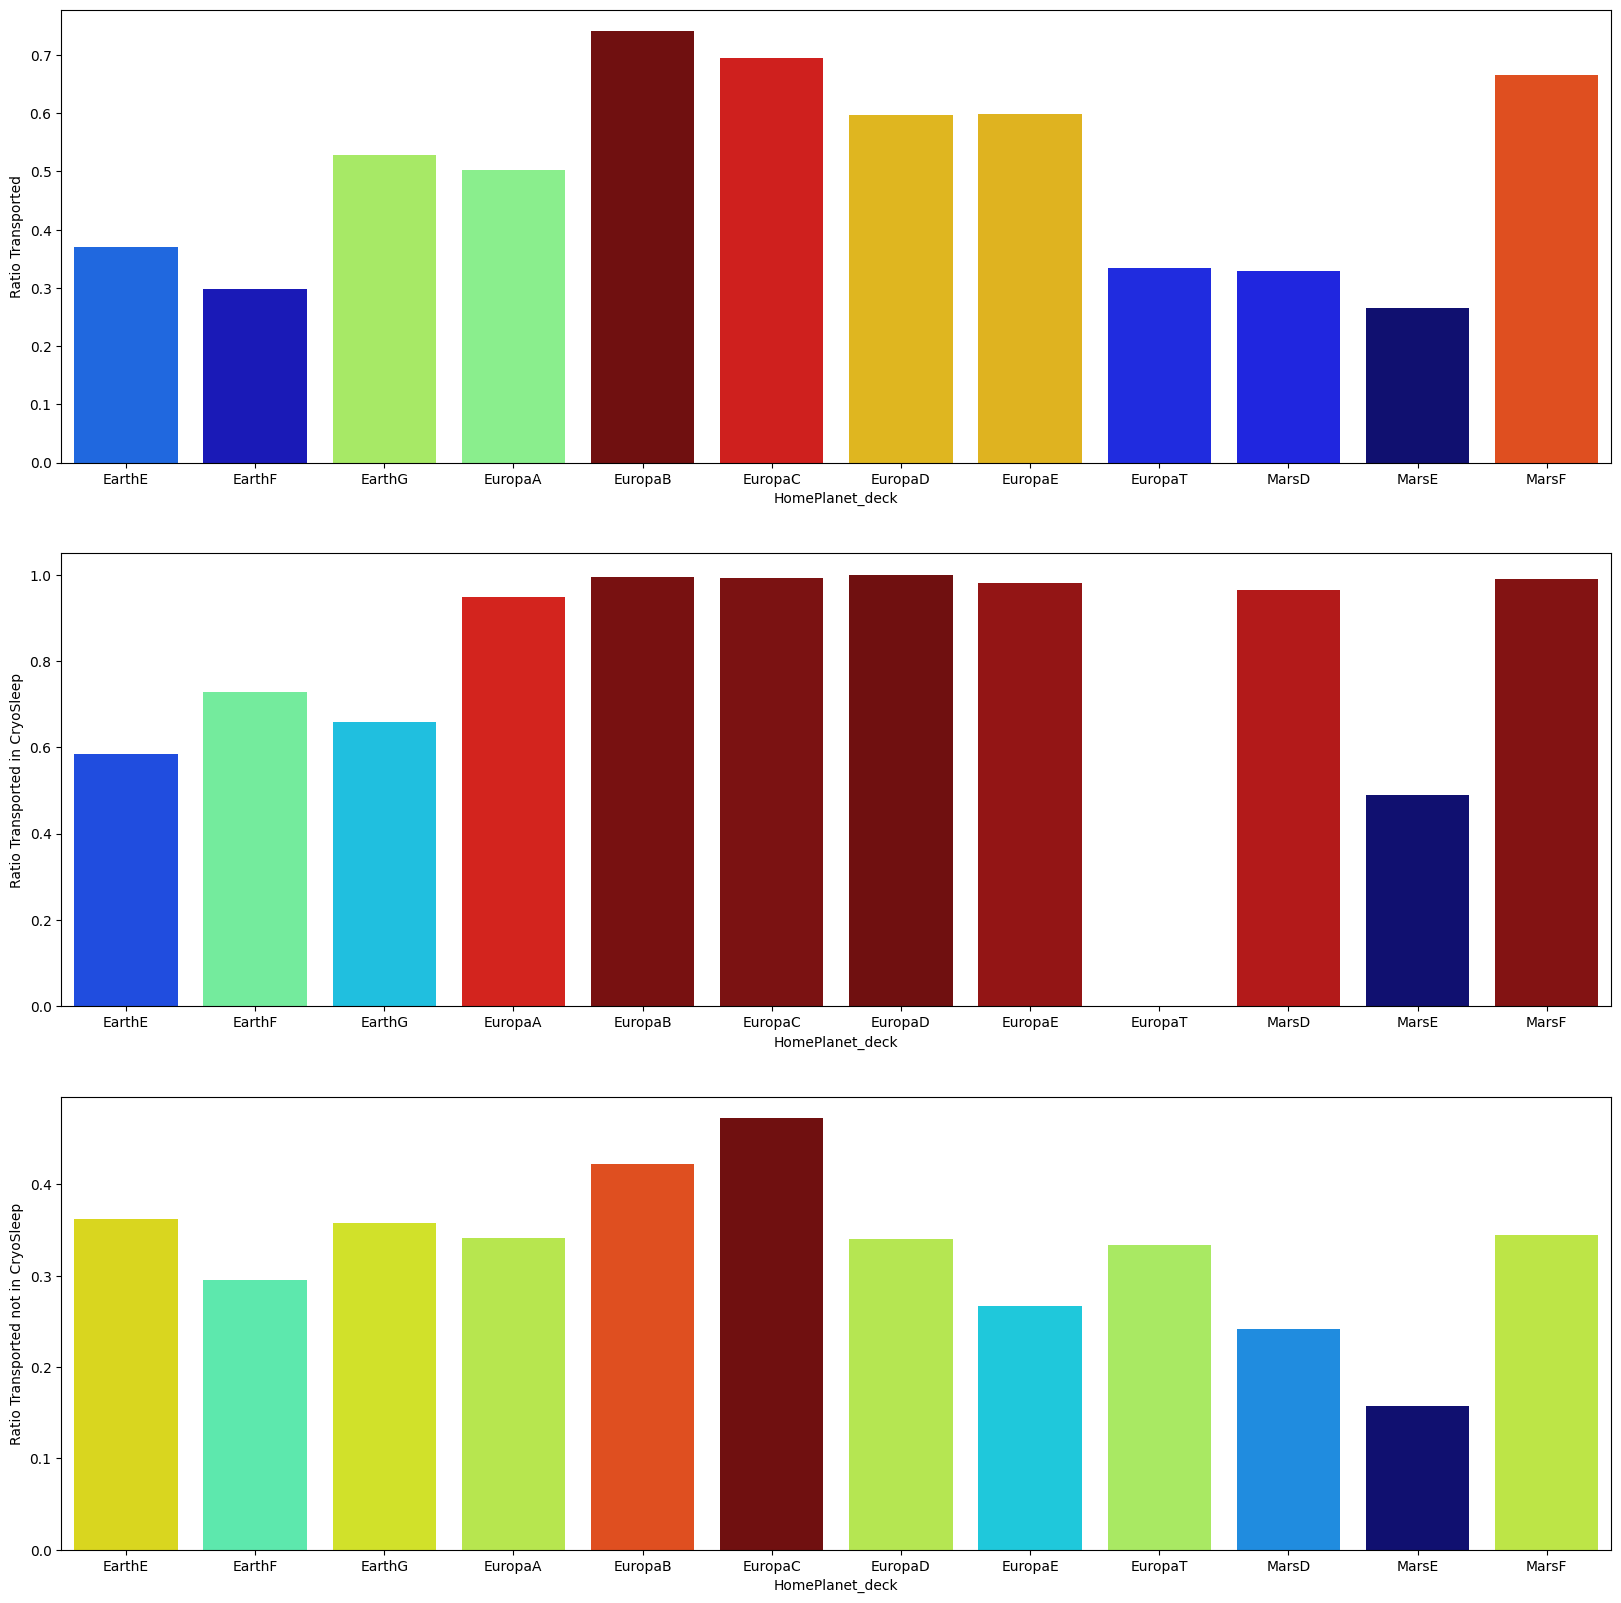

In [53]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'HomePlanet_deck', cat = True)

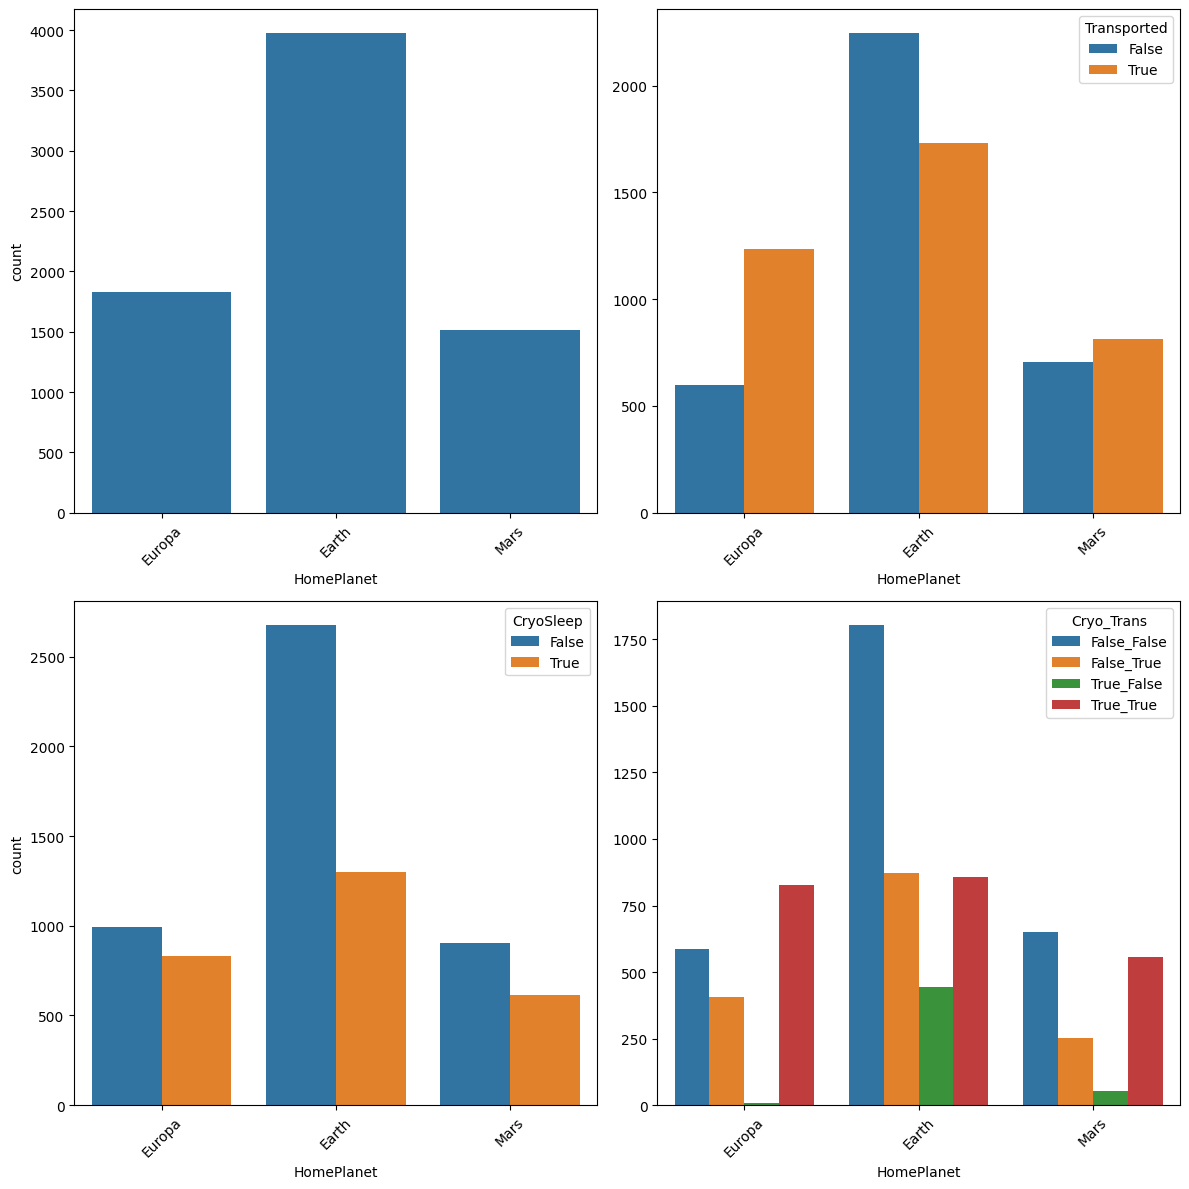

In [54]:
plot_CryoTrans_Counts(df0, 'HomePlanet', df0.HomePlanet.unique().tolist())

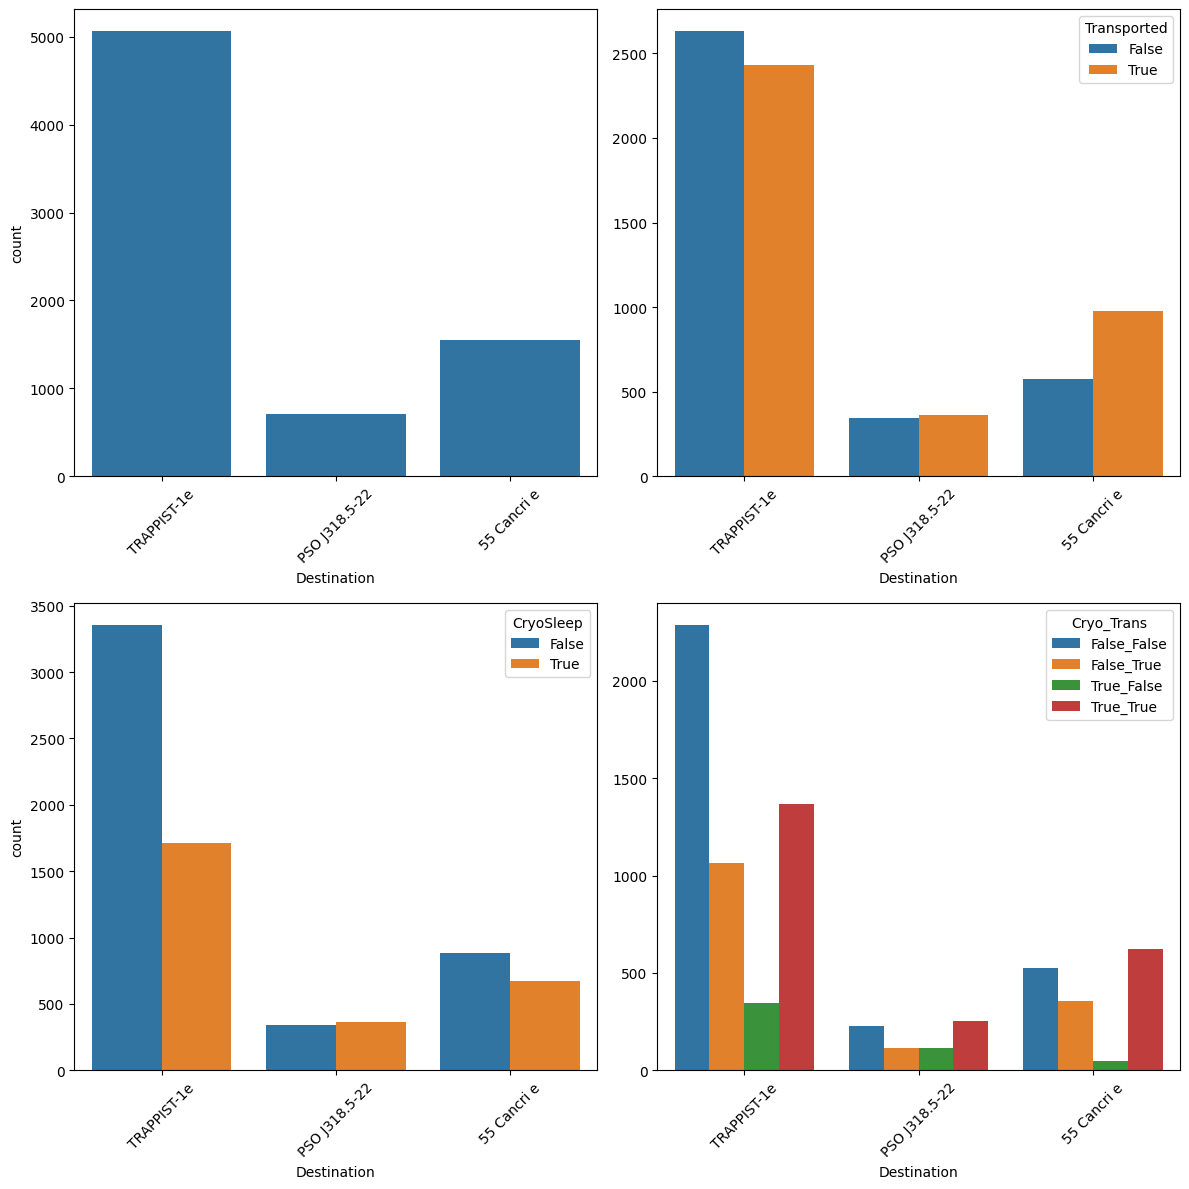

In [55]:
plot_CryoTrans_Counts(df0, 'Destination', df0.Destination.unique().tolist())

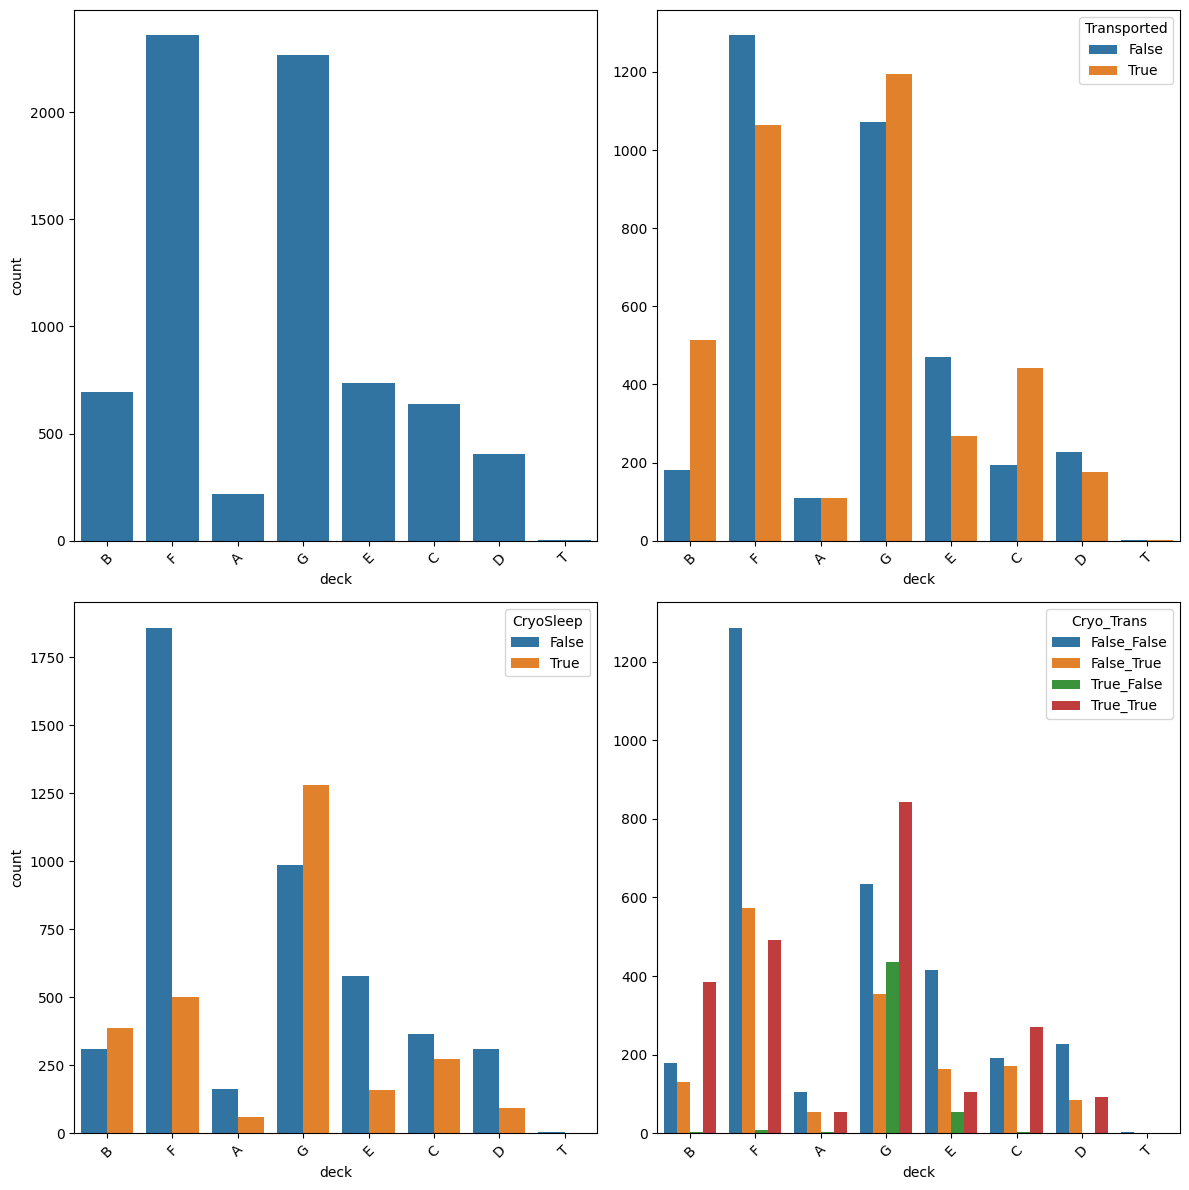

In [56]:
plot_CryoTrans_Counts(df0, 'deck', df0.deck.unique().tolist())

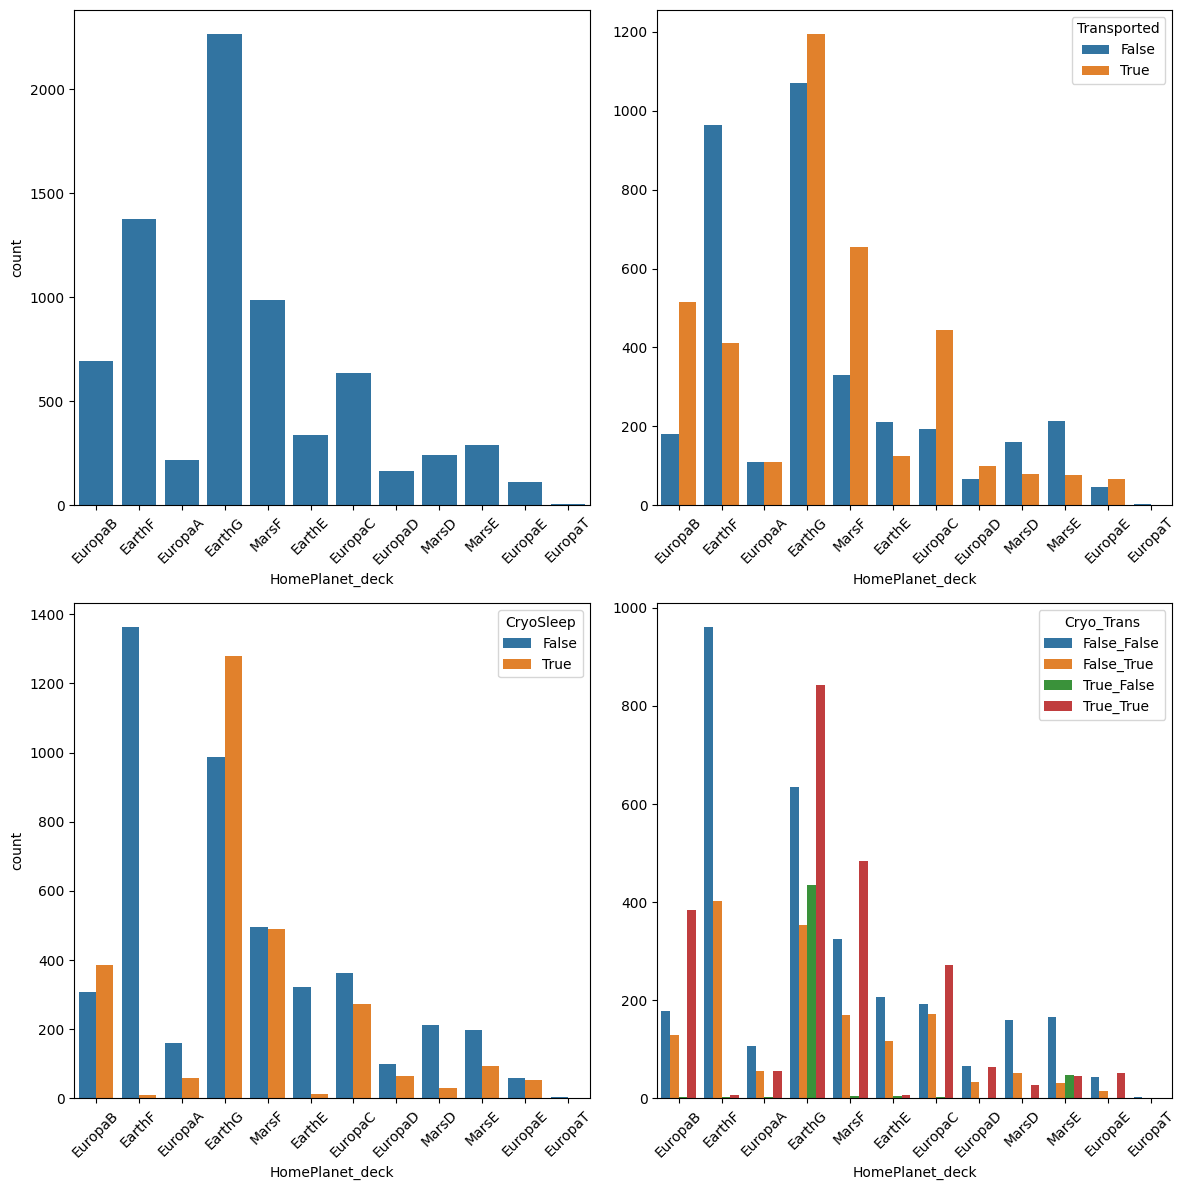

In [57]:
plot_CryoTrans_Counts(df0, 'HomePlanet_deck', df0.HomePlanet_deck.unique().tolist())

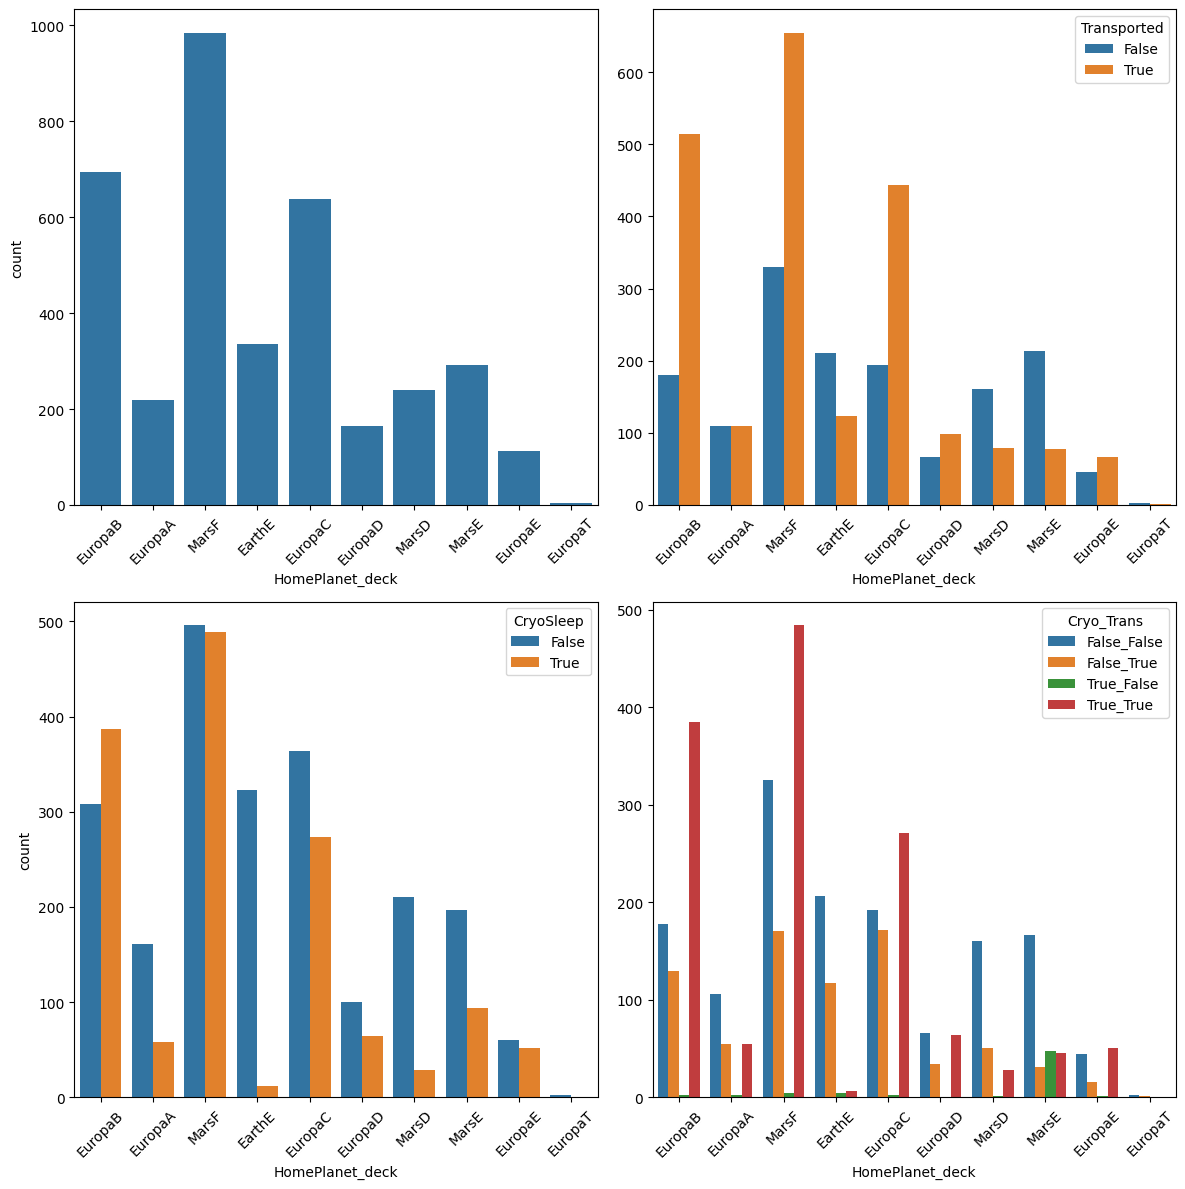

In [58]:
df0_temp = df0[(df0.HomePlanet_deck != 'EarthG') & (df0.HomePlanet_deck != 'EarthF')]
plot_CryoTrans_Counts(df0_temp, 'HomePlanet_deck', df0_temp.HomePlanet_deck.unique().tolist())

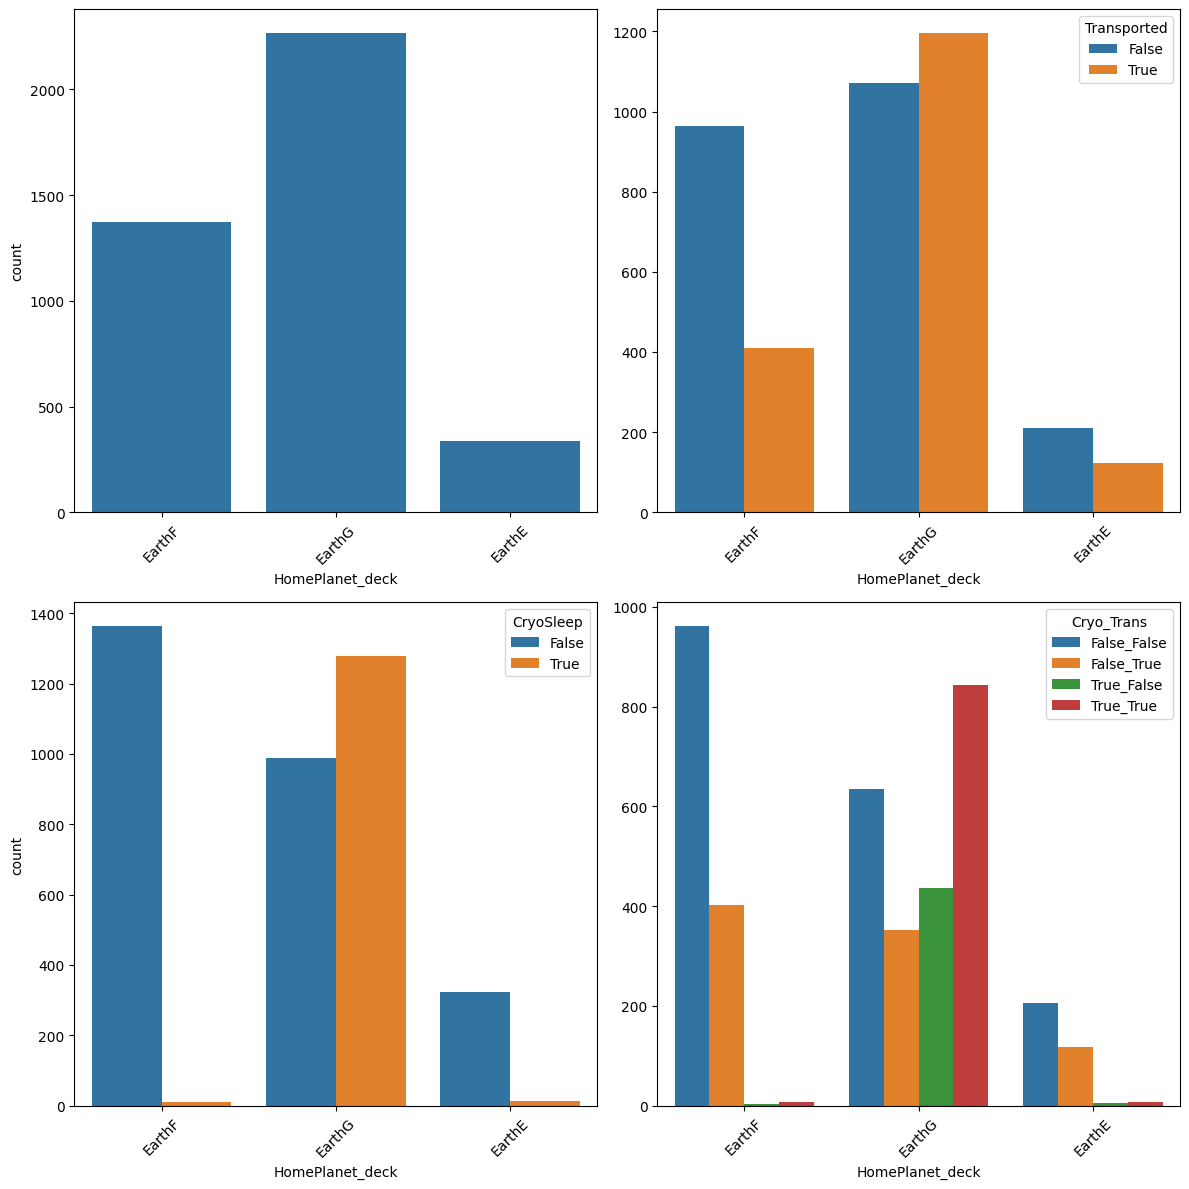

In [59]:
df0_temp = df0[df0.HomePlanet == 'Earth']
plot_CryoTrans_Counts(df0_temp, 'HomePlanet_deck', df0_temp.HomePlanet_deck.unique().tolist())

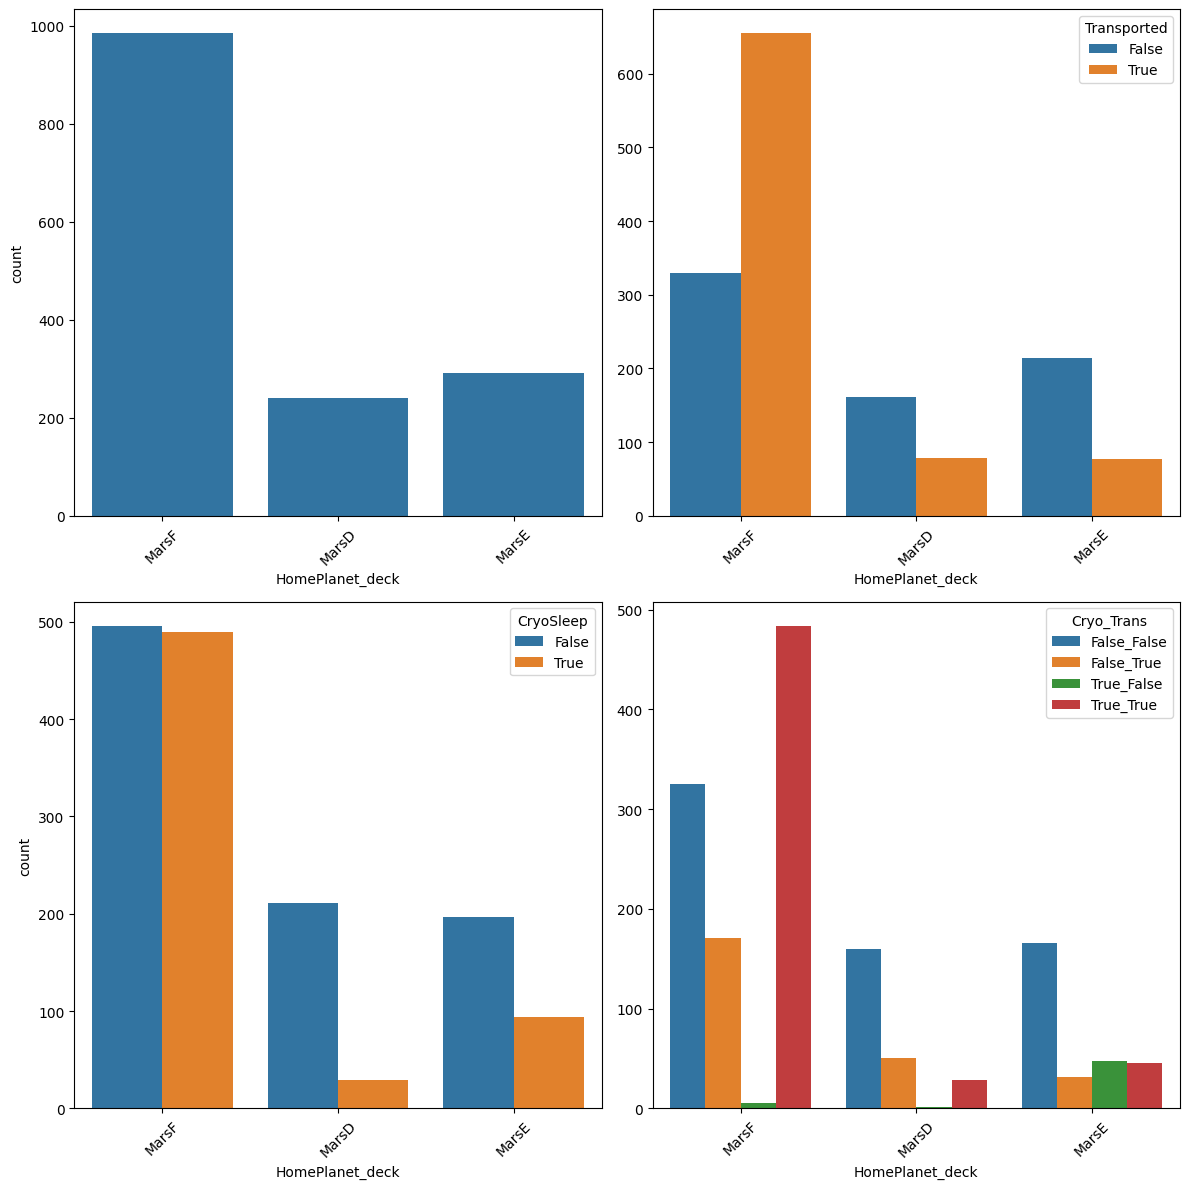

In [60]:
df0_temp = df0[df0.HomePlanet == 'Mars']
plot_CryoTrans_Counts(df0_temp, 'HomePlanet_deck', df0_temp.HomePlanet_deck.unique().tolist())

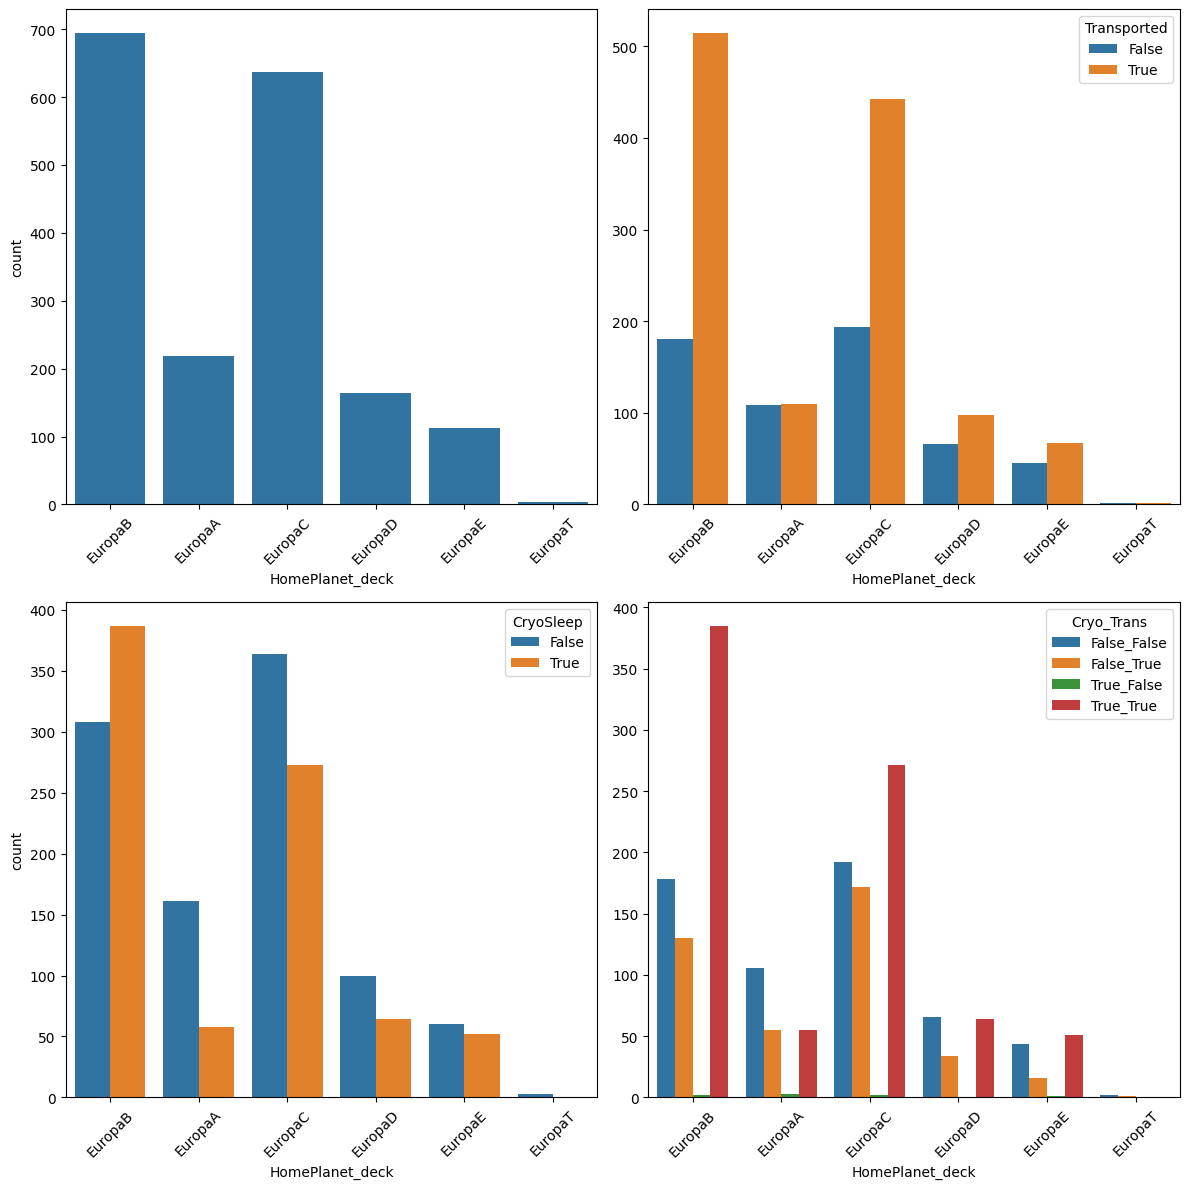

In [61]:
df0_temp = df0[df0.HomePlanet == 'Europa']
plot_CryoTrans_Counts(df0_temp, 'HomePlanet_deck', df0_temp.HomePlanet_deck.unique().tolist())

### Now, let's examine the effect of HomePlanet, Destination, and Deck on few ML algorithms

In [62]:
df1 = pd.concat([df0[['CryoSleep', 'Transported']], df0_base], axis = 1)
for feature in ['HomePlanet', 'Destination', 'deck', 'HomePlanet_deck']:
    prefix = feature if feature != 'HomePlanet_deck' else 'HD'
    one_hot_encoded = pd.get_dummies(df0[feature], prefix = prefix).astype(int)
    df1 = pd.concat([df1, one_hot_encoded], axis = 1)

HomePlanet_Features = [col for col in df1.columns if col.startswith('HomePlanet_')]
Destination_Features = [col for col in df1.columns if col.startswith('Destination_')]
deck_Features = [col for col in df1.columns if col.startswith('deck_')]
HomePlanet_deck_Features = [col for col in df1.columns if col.startswith('HD_')]

In [63]:
basic_list = ['CryoSleep']
features_list = HomePlanet_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'HomePlanet_Earth']
List2:  ['CryoSleep', 'HomePlanet_Earth', 'HomePlanet_Europa']
List3:  ['CryoSleep', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7215,0.0179,0.7215,0.0179,0.6969,0.0099,0.6969,0.0099
Logistic Regression,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179
LightGBM,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179
CatBoost,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179


In [64]:
basic_list = ['CryoSleep'] + Features0
features_list = HomePlanet_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HomePlanet_Earth']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HomePlanet_Earth', 'HomePlanet_Europa']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7477,0.0207,0.7468,0.0212,0.7456,0.0216,0.7460,0.0217
Logistic Regression,0.7688,0.0186,0.7723,0.0136,0.7756,0.0154,0.7756,0.0154
LightGBM,0.7947,0.0197,0.7955,0.0182,0.7968,0.0184,0.7968,0.0182
CatBoost,0.7962,0.0164,0.7938,0.0138,0.7916,0.0151,0.7939,0.0138


In [65]:
basic_list = ['CryoSleep']
features_list = Destination_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'Destination_55 Cancri e']
List2:  ['CryoSleep', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22']
List3:  ['CryoSleep', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7215,0.0179,0.6998,0.0238,0.6998,0.0238,0.6982,0.0211
Logistic Regression,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179
LightGBM,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179
CatBoost,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179


In [66]:
basic_list = ['CryoSleep'] + Features0
features_list = Destination_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'Destination_55 Cancri e']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7477,0.0207,0.7486,0.0204,0.7488,0.0204,0.7487,0.0208
Logistic Regression,0.7688,0.0186,0.7684,0.0135,0.7707,0.0179,0.7707,0.0179
LightGBM,0.7947,0.0197,0.7961,0.0184,0.7966,0.0187,0.7964,0.0187
CatBoost,0.7962,0.0164,0.7962,0.0170,0.7965,0.0163,0.7960,0.0168


In [67]:
basic_list = ['CryoSleep']
features_list = deck_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'deck_A']
List2:  ['CryoSleep', 'deck_A', 'deck_B']
List3:  ['CryoSleep', 'deck_A', 'deck_B', 'deck_C']
List4:  ['CryoSleep', 'deck_A', 'deck_B', 'deck_C', 'deck_D']
List5:  ['CryoSleep', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E']
List6:  ['CryoSleep', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F']
List7:  ['CryoSleep', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G']
List8:  ['CryoSleep', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_T']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std,List5_mean,List5_std,List6_mean,List6_std,List7_mean,List7_std,List8_mean,List8_std
Naive Bayes,0.7215,0.0179,0.7215,0.0179,0.7150,0.0162,0.7122,0.0116,0.6998,0.0119,0.6930,0.0121,0.6930,0.0121,0.6930,0.0121,0.6756,0.0544
Logistic Regression,0.7215,0.0179,0.7215,0.0179,0.7150,0.0162,0.7122,0.0116,0.7122,0.0116,0.7122,0.0116,0.7122,0.0116,0.7122,0.0116,0.7122,0.0116
LightGBM,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179
CatBoost,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179


In [68]:
basic_list = ['CryoSleep'] + Features0
features_list = deck_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'deck_A']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'deck_A', 'deck_B']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'deck_A', 'deck_B', 'deck_C']
List4:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'deck_A', 'deck_B', 'deck_C', 'deck_D']
List5:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E']
List6:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F']
List7:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std,List5_mean,List5_std,List6_mean,List6_std,List7_mean,List7_std,List8_mean,List8_std
Naive Bayes,0.7477,0.0207,0.7477,0.0204,0.7473,0.0204,0.7525,0.0195,0.7539,0.0184,0.7562,0.0178,0.7568,0.0177,0.7568,0.0182,0.7435,0.0489
Logistic Regression,0.7688,0.0186,0.7691,0.0181,0.7715,0.0160,0.7742,0.0175,0.7748,0.0179,0.7771,0.0177,0.7774,0.0150,0.7770,0.0145,0.7770,0.0145
LightGBM,0.7947,0.0197,0.7947,0.0197,0.7957,0.0186,0.7954,0.0188,0.7954,0.0184,0.7954,0.0184,0.7942,0.0182,0.7949,0.0184,0.7949,0.0184
CatBoost,0.7962,0.0164,0.7960,0.0169,0.7969,0.0175,0.7991,0.0150,0.7990,0.0160,0.8043,0.0165,0.8032,0.0156,0.8009,0.0125,0.8013,0.0140


In [69]:
basic_list = ['CryoSleep']
features_list = HomePlanet_deck_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep']
List1:  ['CryoSleep', 'HD_EarthE']
List2:  ['CryoSleep', 'HD_EarthE', 'HD_EarthF']
List3:  ['CryoSleep', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List4:  ['CryoSleep', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA']
List5:  ['CryoSleep', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA', 'HD_EuropaB']
List6:  ['CryoSleep', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC']
List7:  ['CryoSleep', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD']
List8:  ['CryoSleep', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE']
List9:  ['CryoSleep', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_EuropaT']
List10:  ['CryoSleep', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_EuropaT', 'HD_MarsD']
List11:  ['CryoS

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std,List5_mean,List5_std,List6_mean,List6_std,List7_mean,List7_std,List8_mean,List8_std,List9_mean,List9_std,List10_mean,List10_std,List11_mean,List11_std,List12_mean,List12_std
Naive Bayes,0.7215,0.0179,0.7213,0.0178,0.7213,0.0178,0.7213,0.0178,0.7167,0.0250,0.7140,0.0155,0.7113,0.0112,0.7069,0.0109,0.7031,0.0097,0.6845,0.0546,0.6819,0.0510,0.6603,0.0466,0.6658,0.0415
Logistic Regression,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7150,0.0162,0.7122,0.0116,0.7122,0.0116,0.7122,0.0116,0.7122,0.0116,0.7122,0.0116,0.7122,0.0116,0.7122,0.0116
LightGBM,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7204,0.0173,0.7204,0.0173
CatBoost,0.7215,0.0179,0.7211,0.0182,0.7211,0.0182,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179,0.7215,0.0179


In [70]:
basic_list = ['CryoSleep'] + Features0
features_list = HomePlanet_deck_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EarthE']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EarthE', 'HD_EarthF']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List4:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA']
List5:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA', 'HD_EuropaB']
List6:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC']
List7:  ['Cryo

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std,List5_mean,List5_std,List6_mean,List6_std,List7_mean,List7_std,List8_mean,List8_std,List9_mean,List9_std,List10_mean,List10_std,List11_mean,List11_std,List12_mean,List12_std
Naive Bayes,0.7477,0.0207,0.7488,0.0205,0.7458,0.0254,0.7461,0.0252,0.7461,0.0251,0.7476,0.0241,0.7532,0.0209,0.7508,0.0213,0.7471,0.0208,0.7338,0.0461,0.7307,0.0452,0.7353,0.0487,0.7372,0.0496
Logistic Regression,0.7688,0.0186,0.7688,0.0187,0.7695,0.0201,0.7673,0.0136,0.7680,0.0139,0.7680,0.0147,0.7727,0.0145,0.7751,0.0156,0.7744,0.0152,0.7744,0.0152,0.7744,0.0152,0.7767,0.0157,0.7766,0.0155
LightGBM,0.7947,0.0197,0.7949,0.0199,0.7951,0.0197,0.7955,0.0184,0.7955,0.0184,0.7954,0.0183,0.7960,0.0183,0.7960,0.0183,0.7960,0.0183,0.7960,0.0183,0.7960,0.0183,0.7942,0.0180,0.7947,0.0169
CatBoost,0.7962,0.0164,0.7961,0.0176,0.7964,0.0158,0.7934,0.0153,0.7946,0.0144,0.7951,0.0121,0.7981,0.0137,0.7984,0.0120,0.7951,0.0143,0.7964,0.0128,0.7961,0.0136,0.8016,0.0128,0.8003,0.0141


In [71]:
HomePlanet_deck_Features2 = ['HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']

In [72]:
basic_list = ['CryoSleep'] + Features0
features_list = HomePlanet_deck_Features2
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC']
List4:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD']
List5:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE']
List6:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD']
L

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std,List5_mean,List5_std,List6_mean,List6_std,List7_mean,List7_std,List8_mean,List8_std,List9_mean,List9_std,List10_mean,List10_std,List11_mean,List11_std
Naive Bayes,0.7477,0.0207,0.7477,0.0204,0.7473,0.0204,0.7525,0.0195,0.7505,0.0203,0.7458,0.0208,0.7452,0.0196,0.7521,0.0163,0.7517,0.0202,0.7512,0.0172,0.7518,0.0227,0.7517,0.0230
Logistic Regression,0.7688,0.0186,0.7692,0.0180,0.7715,0.0160,0.7741,0.0175,0.7755,0.0178,0.7764,0.0178,0.7766,0.0176,0.7792,0.0164,0.7755,0.0181,0.7742,0.0179,0.7749,0.0162,0.7766,0.0155
LightGBM,0.7947,0.0197,0.7947,0.0197,0.7957,0.0186,0.7954,0.0188,0.7955,0.0179,0.7954,0.0178,0.7954,0.0178,0.7951,0.0189,0.7955,0.0192,0.7955,0.0192,0.7955,0.0192,0.7947,0.0169
CatBoost,0.7962,0.0164,0.7960,0.0169,0.7969,0.0175,0.7991,0.0150,0.7987,0.0152,0.7996,0.0176,0.8032,0.0159,0.8028,0.0155,0.7999,0.0138,0.8005,0.0160,0.7986,0.0148,0.7987,0.0140


In [73]:
basic_list = ['CryoSleep'] + Features0 + HomePlanet_deck_Features2
features_list = Destination_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_Mars

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7517,0.0230,0.7499,0.0195,0.7502,0.0195,0.7482,0.0195
Logistic Regression,0.7766,0.0155,0.7785,0.0152,0.7783,0.0150,0.7783,0.0150
LightGBM,0.7947,0.0169,0.7947,0.0169,0.7947,0.0169,0.7949,0.0169
CatBoost,0.7987,0.0140,0.8007,0.0140,0.8054,0.0108,0.8048,0.0114


In [74]:
basic_list = ['CryoSleep'] + Features0 + HomePlanet_Features + deck_Features
features_list = Destination_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_T']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_T', 'Destination_55 Cancri e']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_T', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars', 'deck_A', 'deck_B', 'deck_C', 'de

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7390,0.0467,0.7400,0.0431,0.7404,0.0428,0.7396,0.0420
Logistic Regression,0.7771,0.0124,0.7778,0.0129,0.7778,0.0131,0.7778,0.0131
LightGBM,0.7957,0.0184,0.7955,0.0181,0.7955,0.0181,0.7957,0.0180
CatBoost,0.8009,0.0154,0.8016,0.0141,0.8028,0.0099,0.8029,0.0109


In [75]:
deck_Features2 = ['deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G']
basic_list = ['CryoSleep'] + Features0 + deck_Features2
features_list = Destination_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'Destination_55 Cancri e']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7568,0.0182,0.7564,0.0170,0.7559,0.0171,0.7574,0.0179
Logistic Regression,0.7770,0.0145,0.7764,0.0125,0.7764,0.0125,0.7764,0.0125
LightGBM,0.7949,0.0184,0.7949,0.0184,0.7950,0.0182,0.7950,0.0182
CatBoost,0.8009,0.0125,0.8017,0.0139,0.8016,0.0145,0.8043,0.0111


In [76]:
basic_list = ['CryoSleep'] + Features0 + deck_Features2
features_list = HomePlanet_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'HomePlanet_Earth']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'HomePlanet_Earth', 'HomePlanet_Europa']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'deck_A', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7568,0.0182,0.7554,0.0201,0.7546,0.0182,0.7551,0.0182
Logistic Regression,0.7770,0.0145,0.7744,0.0141,0.7770,0.0124,0.7770,0.0124
LightGBM,0.7949,0.0184,0.7957,0.0186,0.7958,0.0184,0.7957,0.0184
CatBoost,0.8009,0.0125,0.8013,0.0142,0.8001,0.0135,0.8021,0.0160


In [77]:
basic_list = ['CryoSleep'] + Features00 + HomePlanet_deck_Features2
features_list = Destination_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22']
List3:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Under_13', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_Mars

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7505,0.0213,0.7486,0.0195,0.7484,0.0195,0.7473,0.0198
Logistic Regression,0.7721,0.0173,0.7753,0.0163,0.7757,0.0167,0.7757,0.0167
LightGBM,0.7946,0.0168,0.7946,0.0170,0.7947,0.0168,0.7946,0.0170
CatBoost,0.8009,0.0151,0.8005,0.0141,0.8001,0.0120,0.8002,0.0139


#### Check if looking at the letters in name make any difference. This is probably a long shot

In [78]:
df2 = pd.concat([df1, df_clean[list(string.ascii_lowercase)]], axis = 1)

In [79]:
basic_list = ['CryoSleep'] + Features0 + HomePlanet_deck_Features2 + Destination_Features
features_list = list(string.ascii_lowercase)[:5]
Compare_Ordered_Feature_Lists(df2, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'a']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'a', 'b'

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std,List5_mean,List5_std
Naive Bayes,0.7482,0.0195,0.7482,0.0198,0.7480,0.0198,0.7480,0.0195,0.7483,0.0196,0.7477,0.0192
Logistic Regression,0.7782,0.0150,0.7785,0.0161,0.7774,0.0159,0.7775,0.0158,0.7775,0.0151,0.7771,0.0153
LightGBM,0.7949,0.0169,0.7949,0.0169,0.7949,0.0169,0.7949,0.0169,0.7949,0.0169,0.7949,0.0169
CatBoost,0.8048,0.0114,0.8020,0.0139,0.8016,0.0125,0.8028,0.0133,0.8021,0.0115,0.8003,0.0151


In [80]:
features_list = list(string.ascii_lowercase)[5:10] 
Compare_Ordered_Feature_Lists(df2, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'f']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'f', 'g'

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std,List5_mean,List5_std
Naive Bayes,0.7482,0.0195,0.7487,0.0193,0.7490,0.0197,0.7492,0.0198,0.7475,0.0203,0.7473,0.0200
Logistic Regression,0.7783,0.0150,0.7786,0.0153,0.7788,0.0156,0.7786,0.0162,0.7779,0.0159,0.7785,0.0177
LightGBM,0.7949,0.0169,0.7949,0.0169,0.7949,0.0169,0.7949,0.0169,0.7949,0.0169,0.7949,0.0169
CatBoost,0.8048,0.0114,0.8018,0.0137,0.8005,0.0118,0.8033,0.0111,0.8029,0.0108,0.7996,0.0148


In [81]:
features_list = list(string.ascii_lowercase)[10:18]
Compare_Ordered_Feature_Lists(df2, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'k']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'k', 'l'

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std,List5_mean,List5_std,List6_mean,List6_std,List7_mean,List7_std,List8_mean,List8_std
Naive Bayes,0.7482,0.0195,0.7480,0.0193,0.7477,0.0193,0.7483,0.0189,0.7477,0.0187,0.7482,0.0187,0.7482,0.0202,0.7480,0.0211,0.7473,0.0210
Logistic Regression,0.7783,0.0150,0.7777,0.0147,0.7774,0.0162,0.7774,0.0162,0.7779,0.0161,0.7777,0.0164,0.7770,0.0162,0.7763,0.0163,0.7763,0.0162
LightGBM,0.7949,0.0169,0.7949,0.0169,0.7947,0.0168,0.7947,0.0168,0.7947,0.0168,0.7947,0.0168,0.7947,0.0168,0.7947,0.0168,0.7947,0.0168
CatBoost,0.8048,0.0114,0.8028,0.0124,0.8009,0.0135,0.7996,0.0125,0.8031,0.0144,0.7996,0.0145,0.8021,0.0132,0.8007,0.0132,0.8005,0.0133


In [82]:
features_list = list(string.ascii_lowercase)[18:26]
Compare_Ordered_Feature_Lists(df2, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 's']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 's', 't'

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std,List5_mean,List5_std,List6_mean,List6_std,List7_mean,List7_std,List8_mean,List8_std
Naive Bayes,0.7482,0.0195,0.7482,0.0197,0.7472,0.0185,0.7471,0.0194,0.7473,0.0195,0.7468,0.0189,0.7456,0.0192,0.7443,0.0186,0.7442,0.0194
Logistic Regression,0.7782,0.0150,0.7783,0.0143,0.7759,0.0140,0.7742,0.0148,0.7745,0.0151,0.7755,0.0154,0.7756,0.0152,0.7757,0.0150,0.7757,0.0150
LightGBM,0.7949,0.0169,0.7949,0.0169,0.7949,0.0169,0.7949,0.0169,0.7949,0.0169,0.7949,0.0169,0.7949,0.0169,0.7949,0.0169,0.7949,0.0169
CatBoost,0.8048,0.0114,0.8026,0.0121,0.8020,0.0127,0.8033,0.0114,0.8017,0.0124,0.7994,0.0141,0.8036,0.0112,0.8024,0.0108,0.8007,0.0119


In [83]:
features_list = ['g', 'l', 'y', 'z']
Compare_Ordered_Feature_Lists(df2, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e']
List1:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'g']
List2:  ['CryoSleep', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'g', 'l'

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std
Naive Bayes,0.7482,0.0195,0.7490,0.0201,0.7479,0.0201,0.7476,0.0195,0.7476,0.0196
Logistic Regression,0.7783,0.0150,0.7778,0.0158,0.7782,0.0169,0.7782,0.0163,0.7772,0.0164
LightGBM,0.7949,0.0169,0.7949,0.0169,0.7947,0.0168,0.7947,0.0168,0.7947,0.0168
CatBoost,0.8048,0.0114,0.8029,0.0123,0.8021,0.0106,0.8017,0.0139,0.8018,0.0115


# Closer look at GroupId, ppId, G1, G2, G3, G4, Sizes (Group, Family, Cabin), First and Last names Lengths, and Cabin Number

In [84]:
df_clean.columns

Index(['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'RoomService',
       'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Transported', 'GroupId',
       'ppId', 'GroupSize', 'G1', 'G2', 'G3', 'G4', 'deck', 'Cabin Number',
       'side', 'FamilySize', 'FirstNameLength', 'LastNameLength',
       'GroupFamilySize', 'CabinFamilySize', 'CabinGroupSize', 'CabinSize',
       'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n',
       'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z'],
      dtype='object')

In [85]:
Features = ['CryoSleep', 'Transported', 'GroupId', 'ppId', 'G1', 'G2', 'G3', 'G4', 'Cabin Number', 'GroupSize', 'FamilySize', 'CabinSize',
            'GroupFamilySize', 'CabinFamilySize', 'CabinGroupSize', 'FirstNameLength', 'LastNameLength']
df0 = df_clean[Features].copy(deep = True)
int_features = ['CryoSleep', 'Transported', 'GroupId', 'Cabin Number', 'G1', 'G2', 'G3', 'G4', 'FirstNameLength', 'LastNameLength']
df0[int_features] = df0[int_features].astype(int)
for feature in ['GroupSize', 'GroupFamilySize', 'CabinFamilySize', 'CabinGroupSize', 'CabinSize', 'FamilySize']:
    df0[feature] = np.expm1(df0[feature]).round(0).astype(int)

In [86]:
df0.nunique()

CryoSleep             2
Transported           2
GroupId            5422
ppId                  8
G1                   10
G2                   10
G3                   10
G4                   10
Cabin Number       1762
GroupSize             8
FamilySize           19
CabinSize             8
GroupFamilySize       8
CabinFamilySize       7
CabinGroupSize        8
FirstNameLength       5
LastNameLength        9
dtype: int64

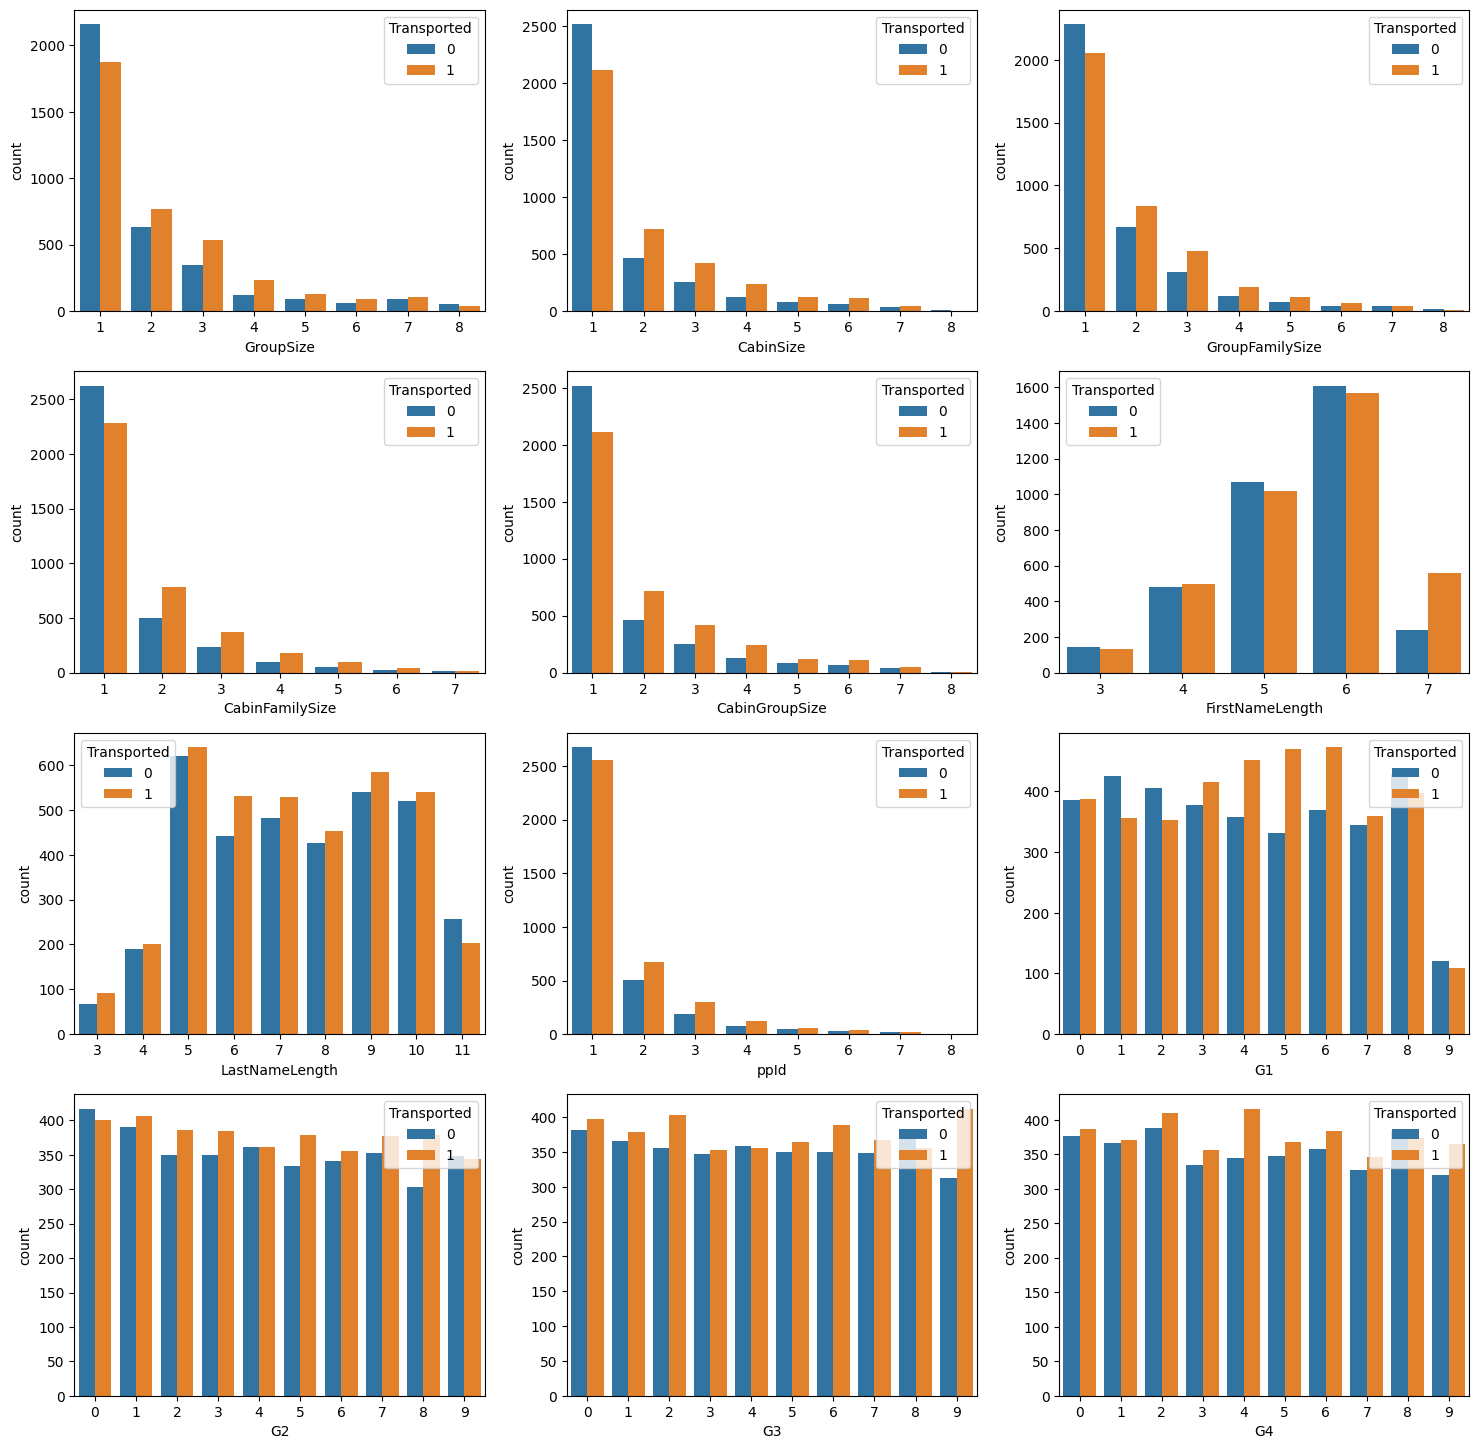

In [87]:
my_list = ['GroupSize', 'CabinSize', 'GroupFamilySize', 'CabinFamilySize', 'CabinGroupSize', 
           'FirstNameLength', 'LastNameLength', 'ppId', 'G1', 'G2', 'G3', 'G4']
plt.figure(figsize = (18, 18))
x = 1
for k in range(12):
    plt.subplot(4, 3, x)        
    sns.countplot(x = my_list[k], hue = 'Transported', data = df0)
    x += 1

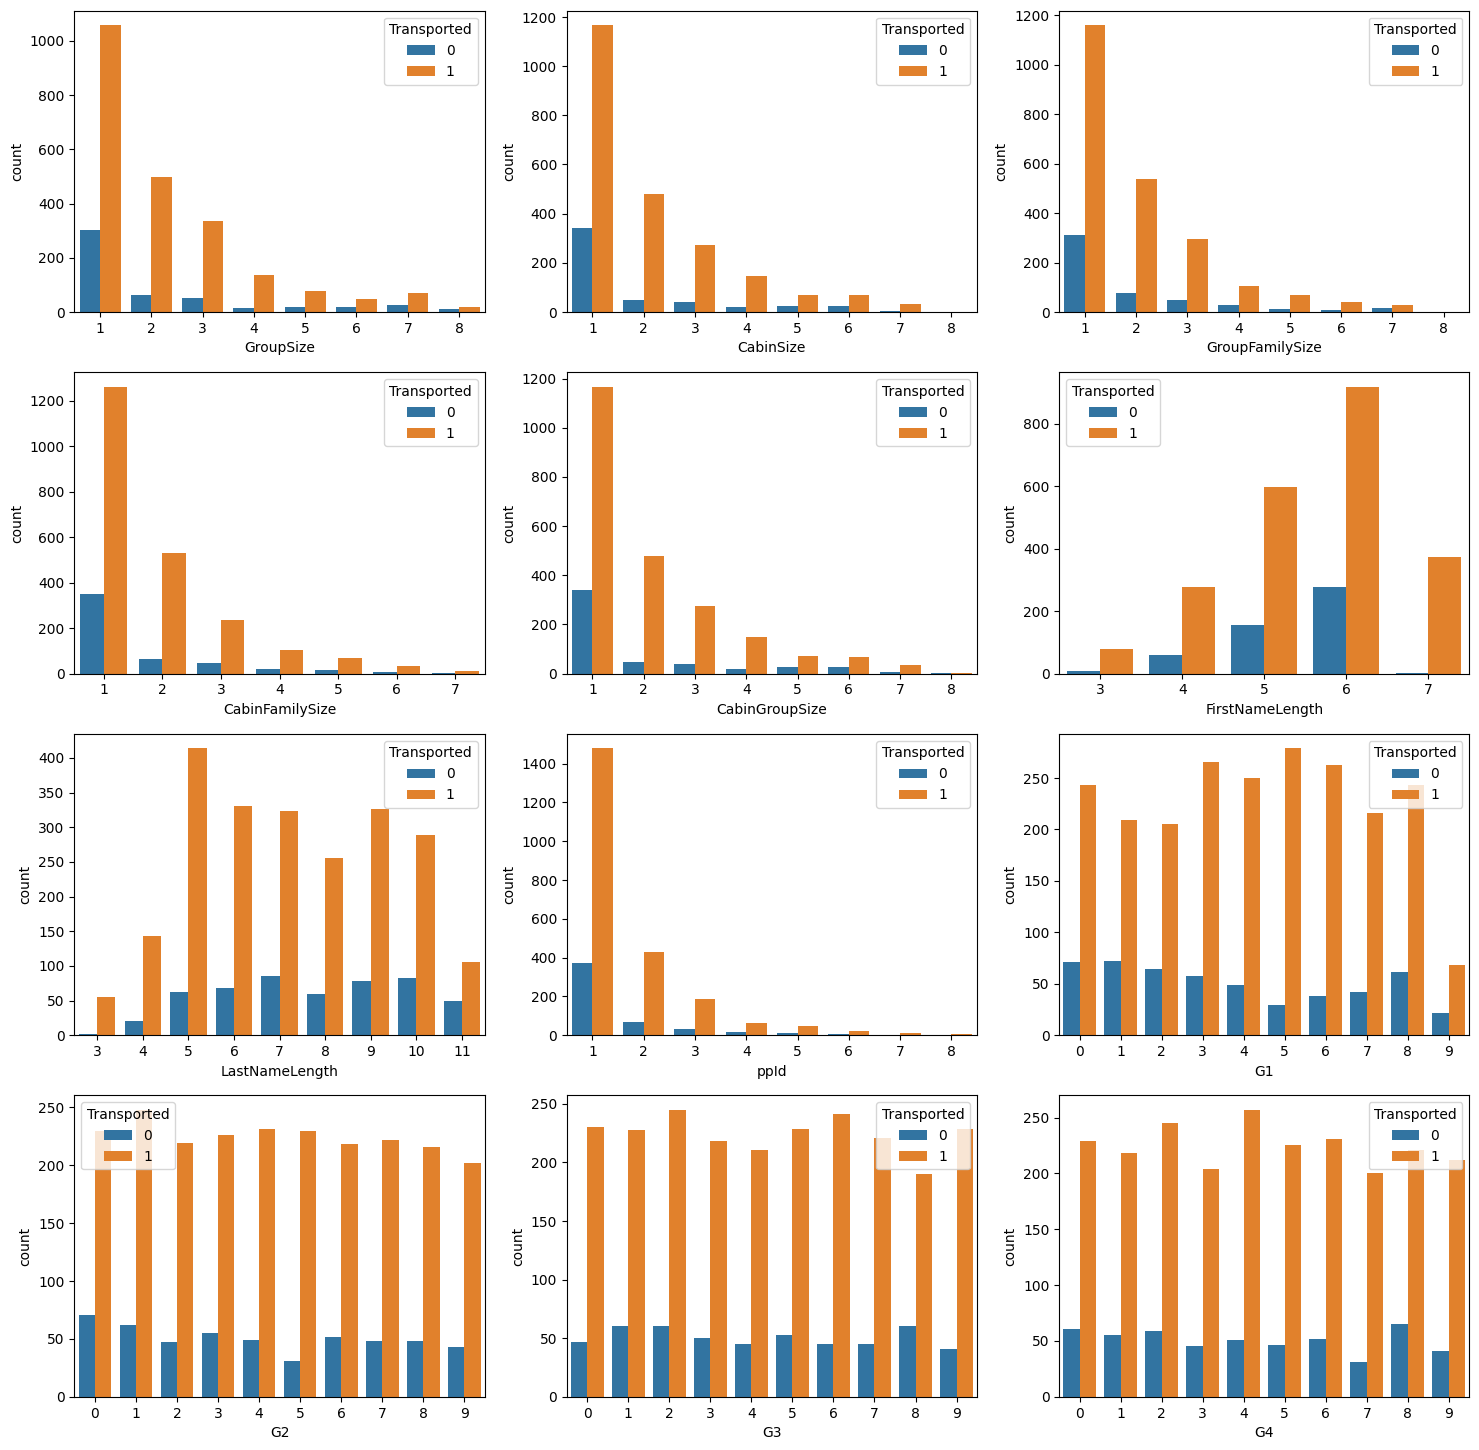

In [88]:
plt.figure(figsize = (18, 18))
x = 1
for k in range(12):
    plt.subplot(4, 3, x)        
    sns.countplot(x = my_list[k], hue = 'Transported', data = df0[df0.CryoSleep == 1])
    x += 1

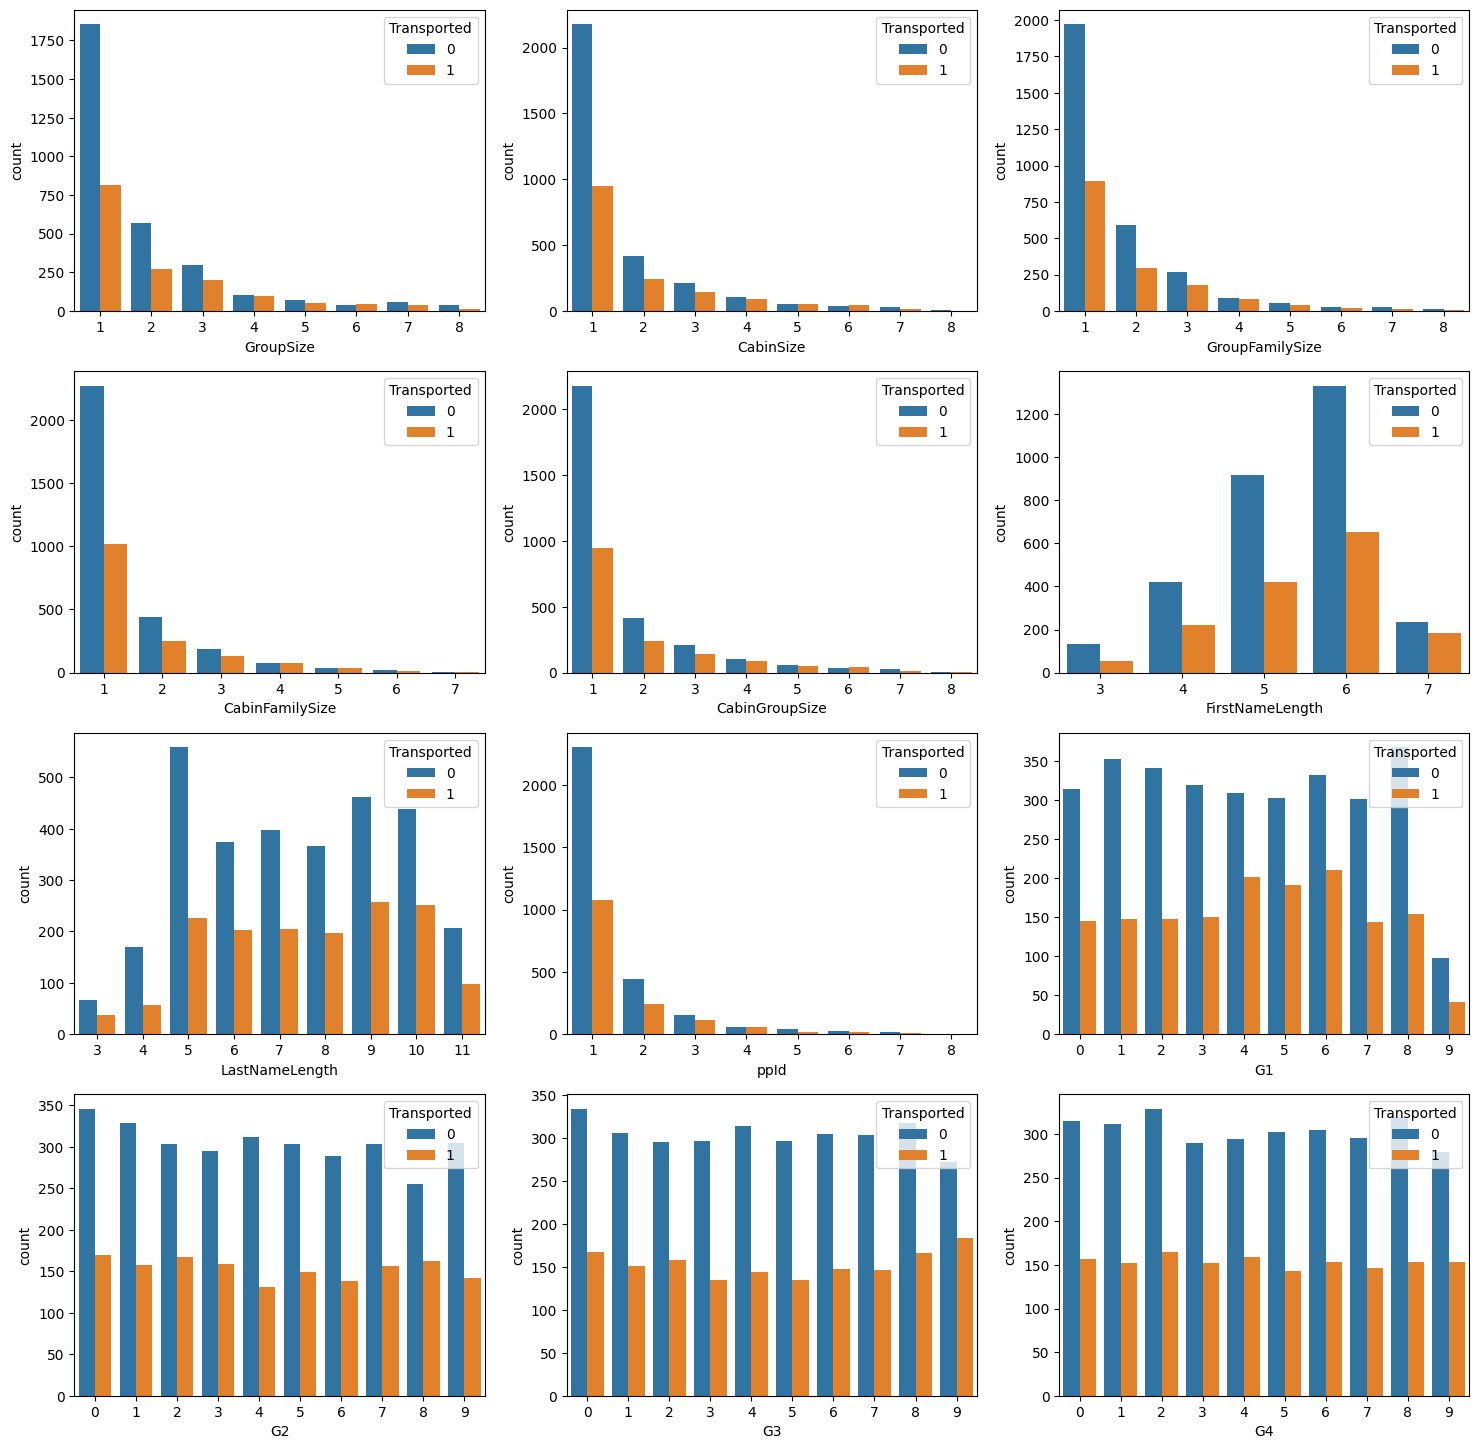

In [89]:
plt.figure(figsize = (18, 18))
x = 1
for k in range(12):
    plt.subplot(4, 3, x)        
    sns.countplot(x = my_list[k], hue = 'Transported', data = df0[df0.CryoSleep == 0])
    x += 1

#### FamilySize

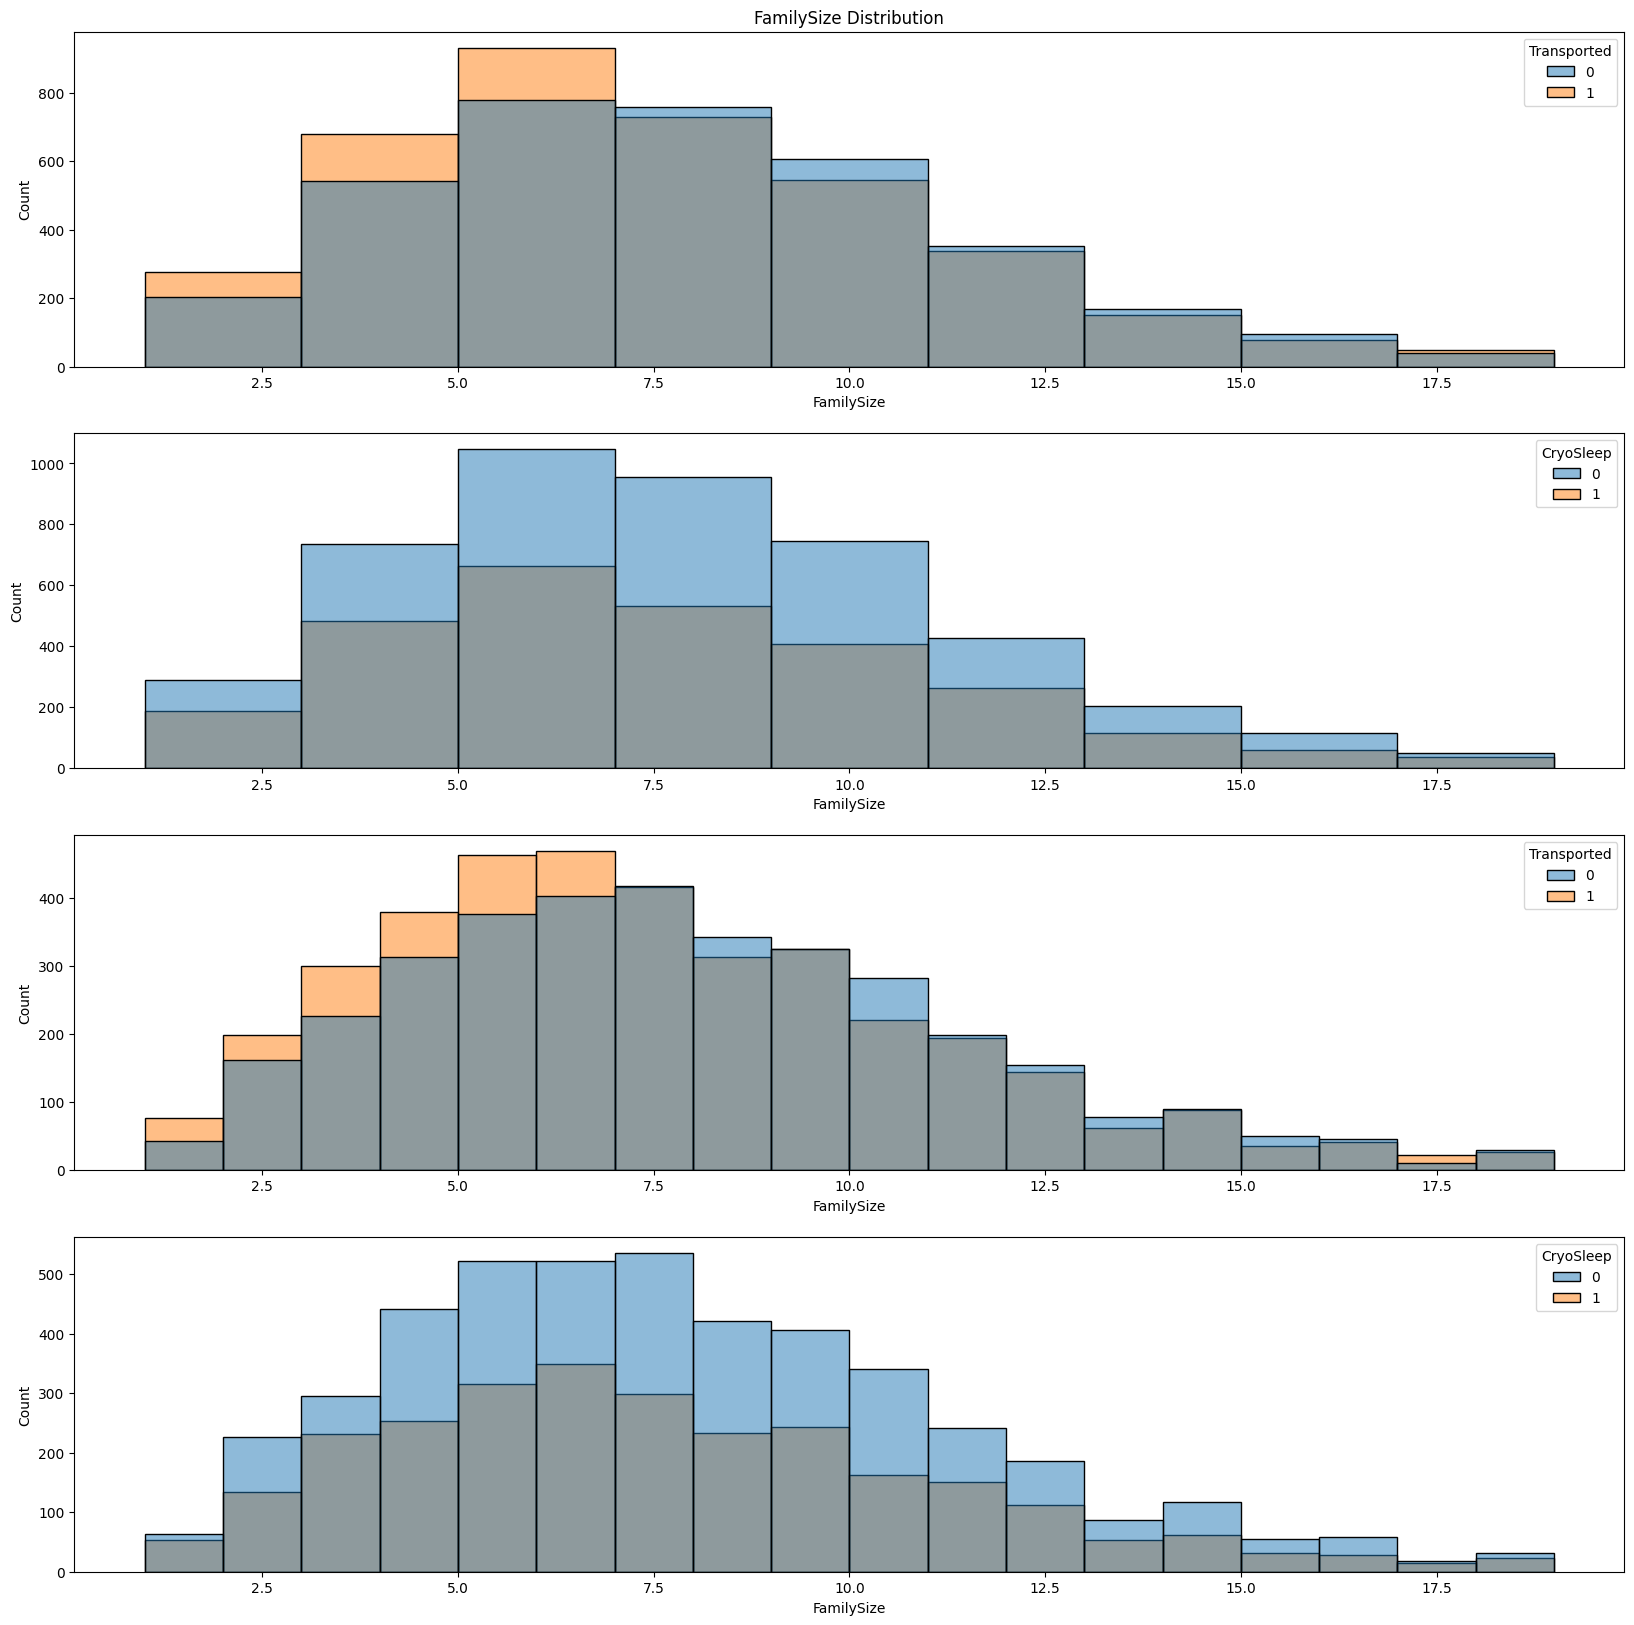

In [90]:
plot_hists_by_Cryo_and_Transported(df0, 'FamilySize', bins = 9)

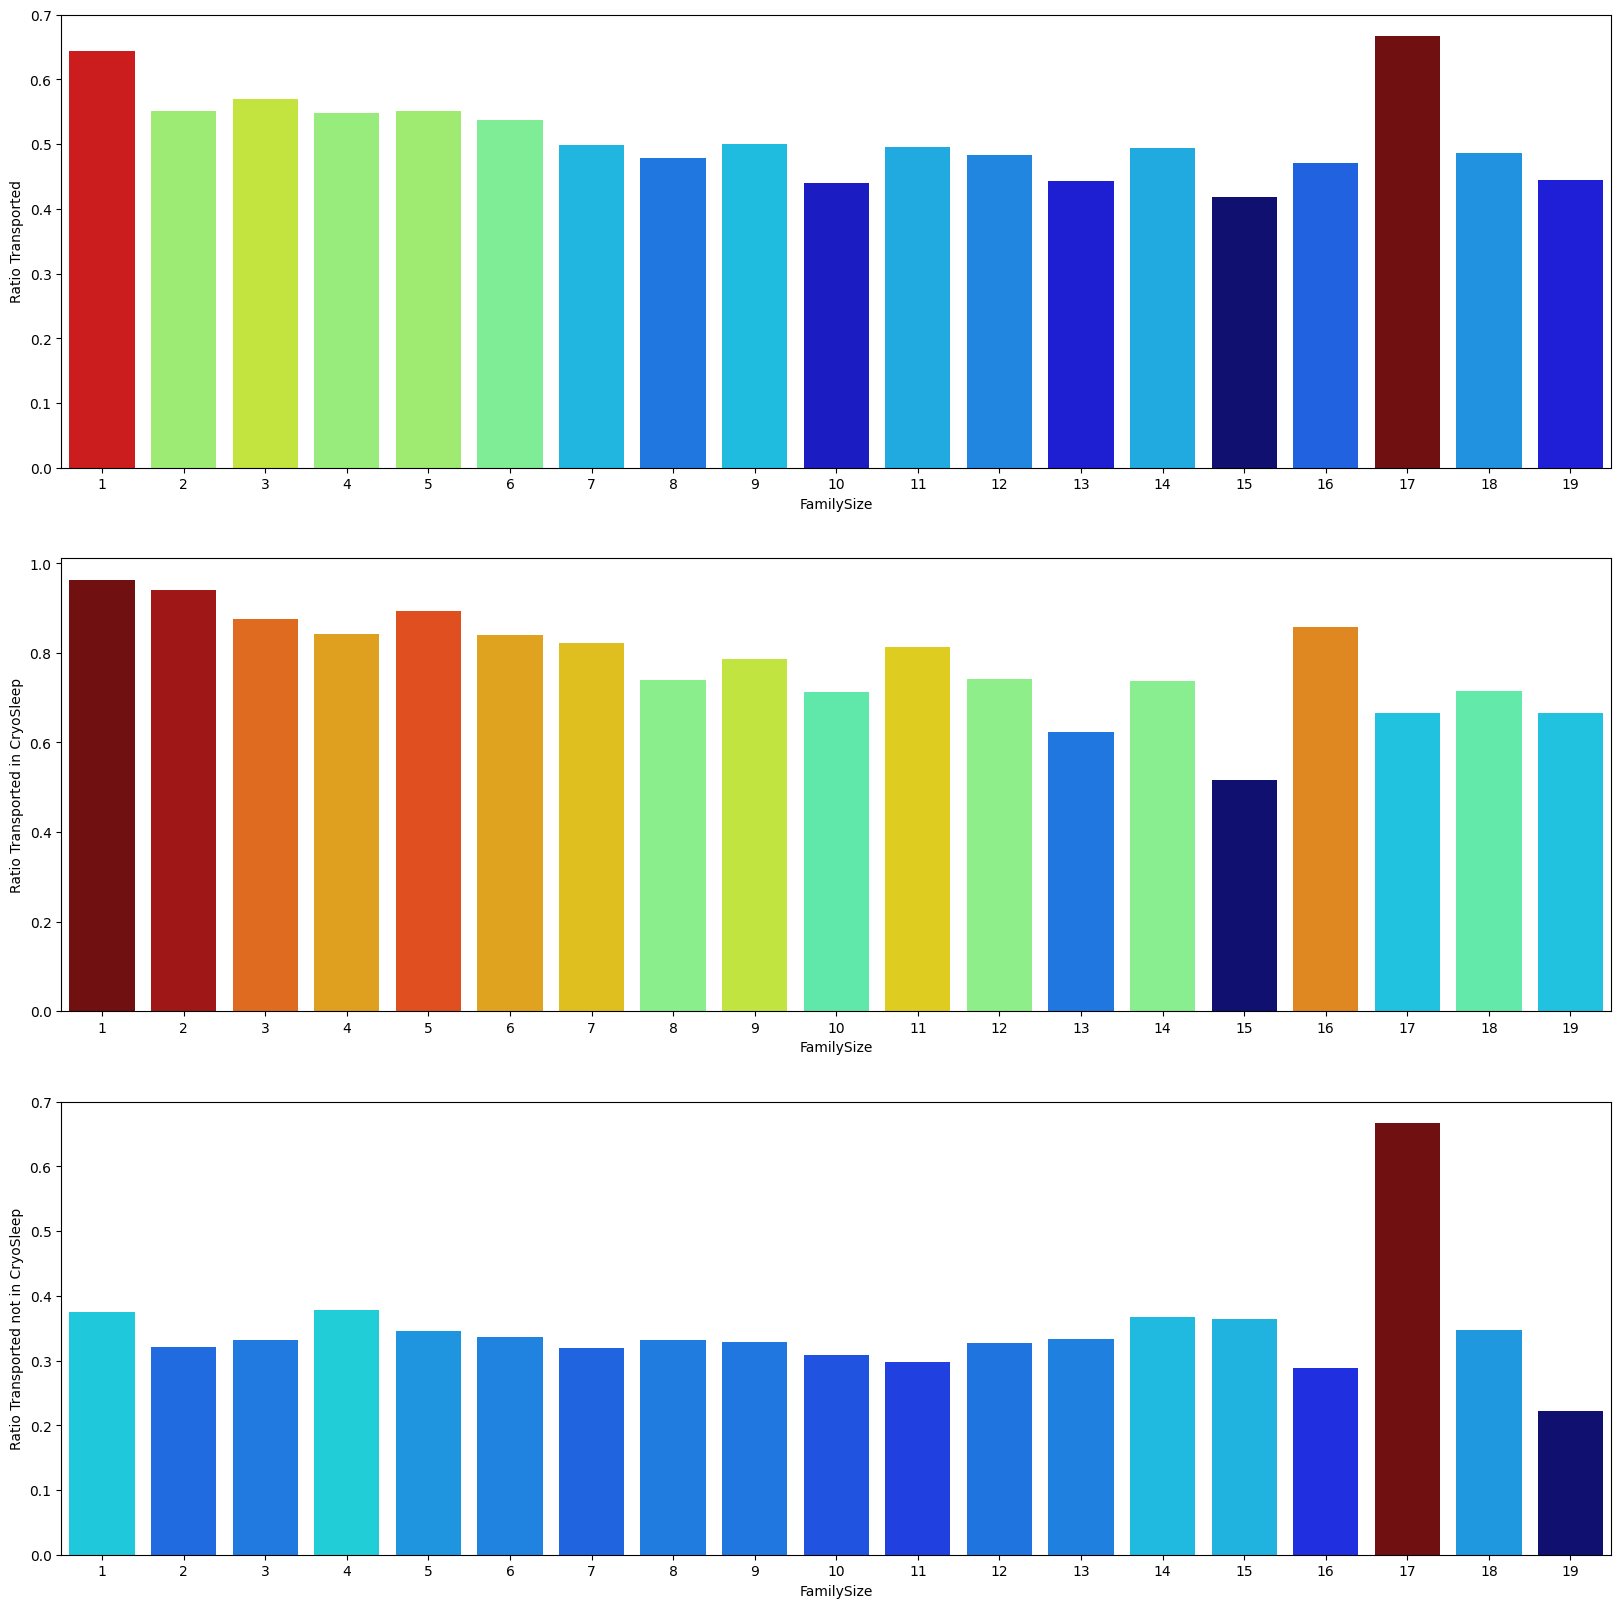

In [91]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'FamilySize', cat = True)

<Axes: xlabel='FamilySize', ylabel='count'>

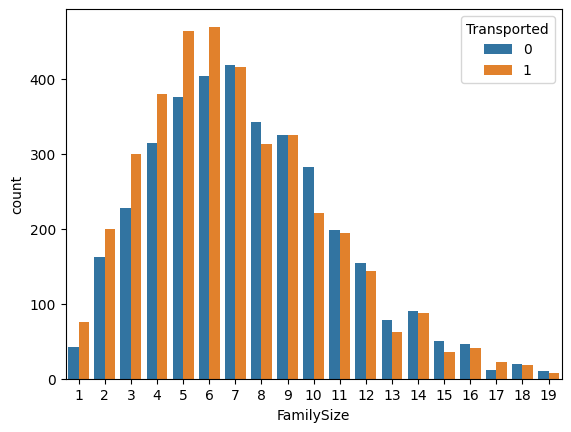

In [92]:
sns.countplot(x = 'FamilySize', hue = 'Transported', data = df0)

<Axes: xlabel='FamilySize', ylabel='count'>

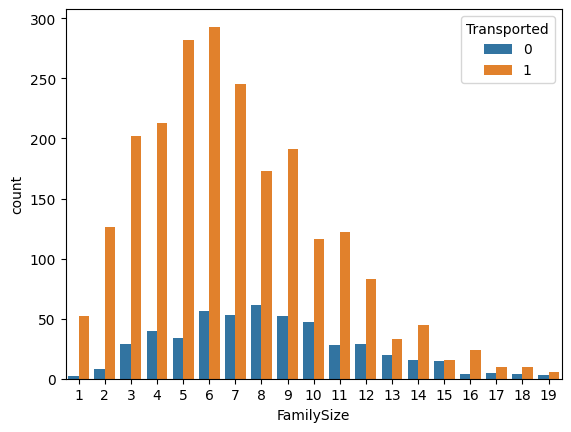

In [93]:
sns.countplot(x = 'FamilySize', hue = 'Transported', data = df0[df0.CryoSleep == 1])

<Axes: xlabel='FamilySize', ylabel='count'>

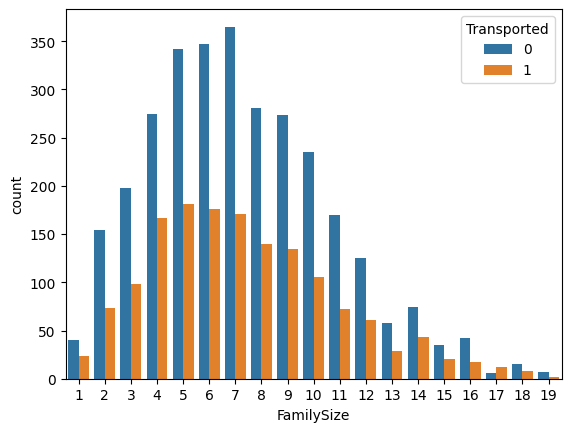

In [94]:
sns.countplot(x = 'FamilySize', hue = 'Transported', data = df0[df0.CryoSleep == 0])

#### Cabin Number & GroupId

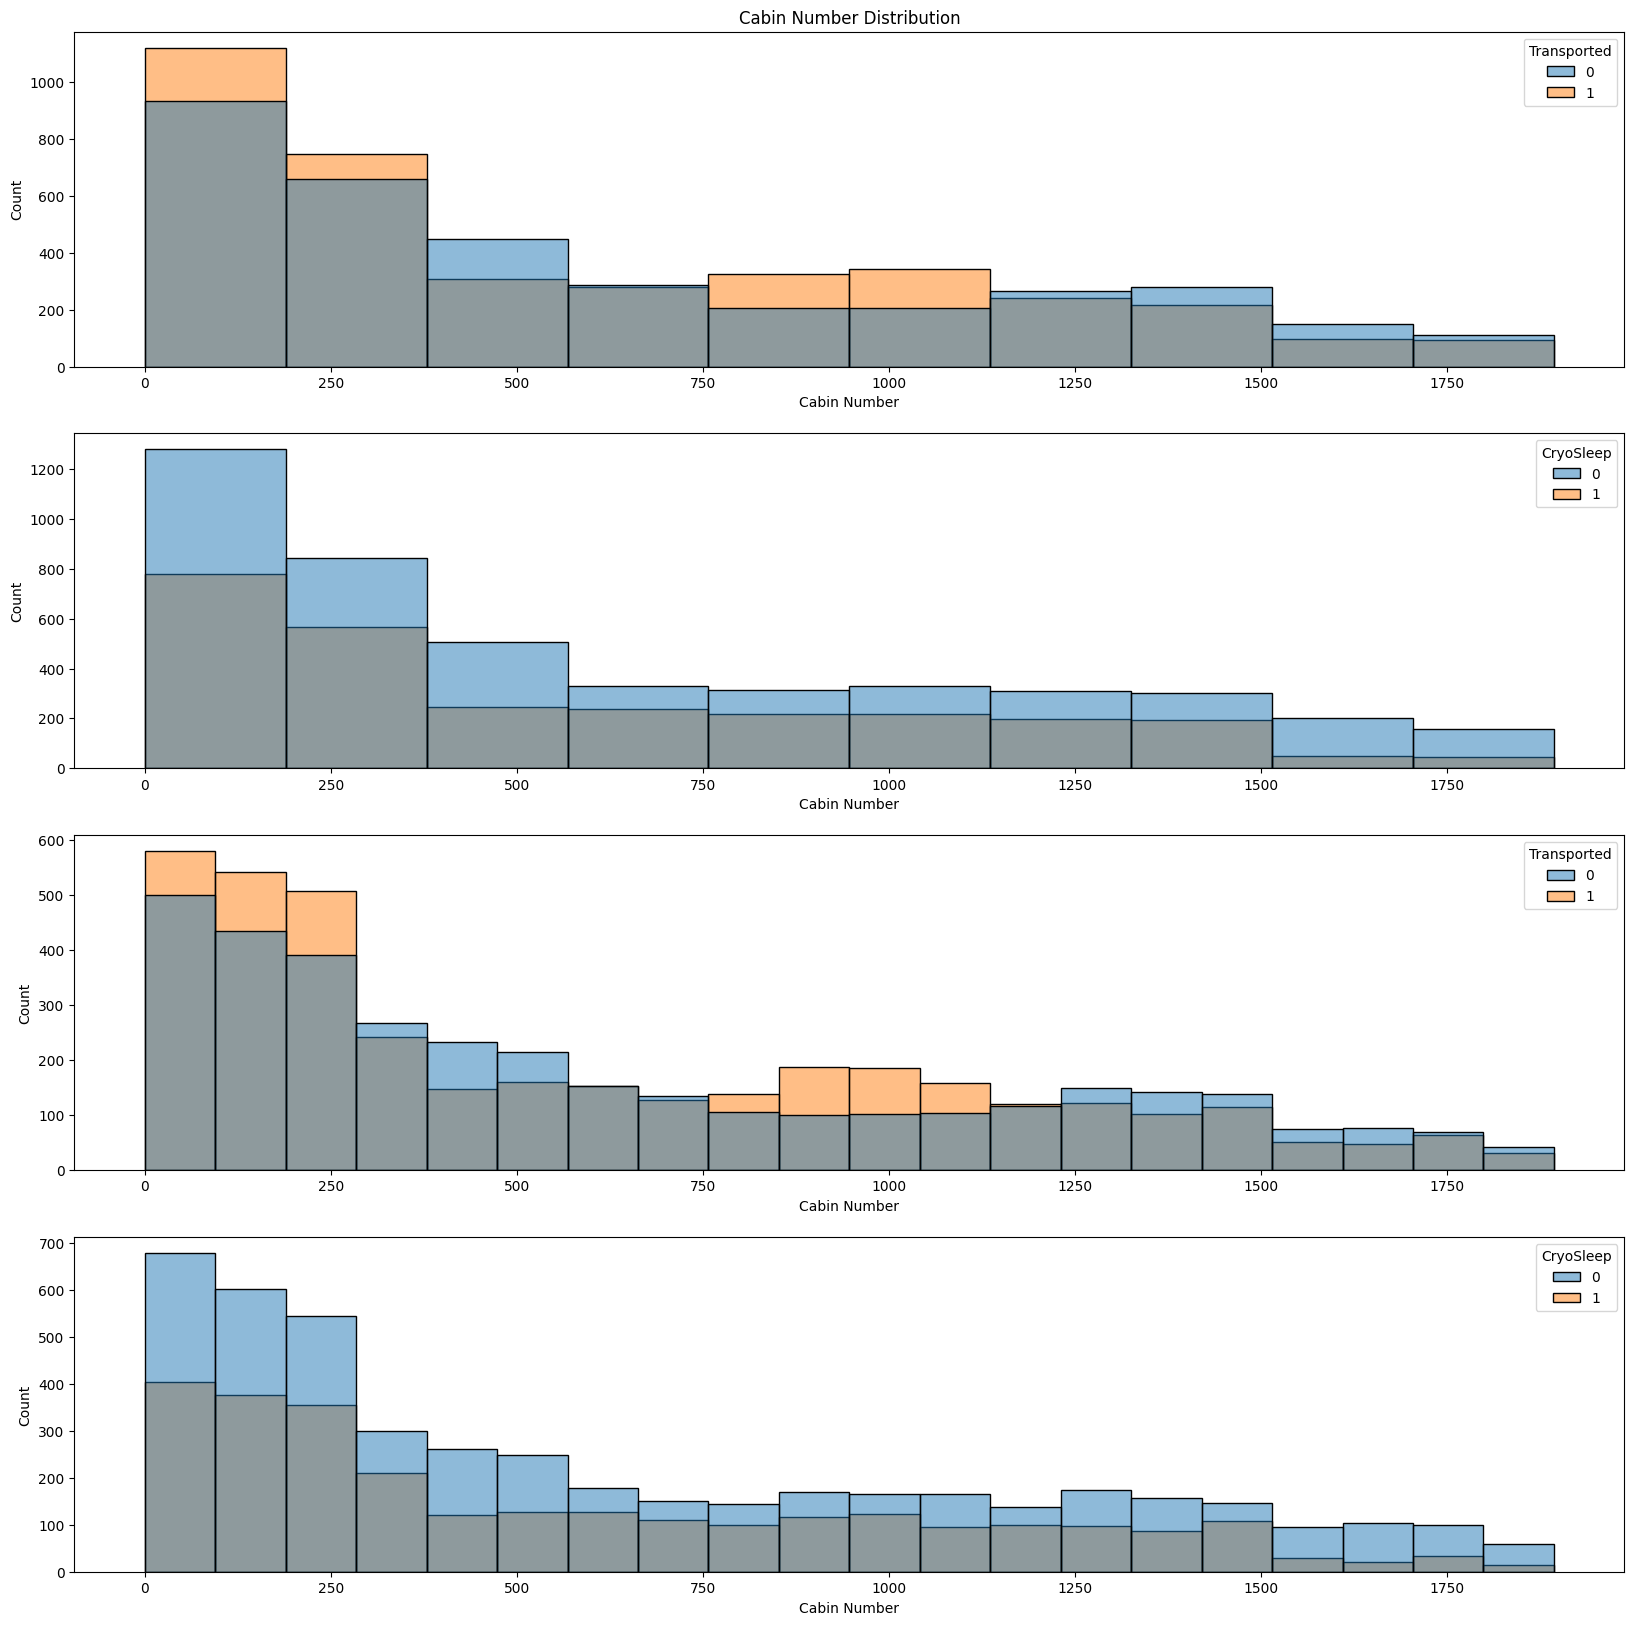

In [95]:
plot_hists_by_Cryo_and_Transported(df0, 'Cabin Number')

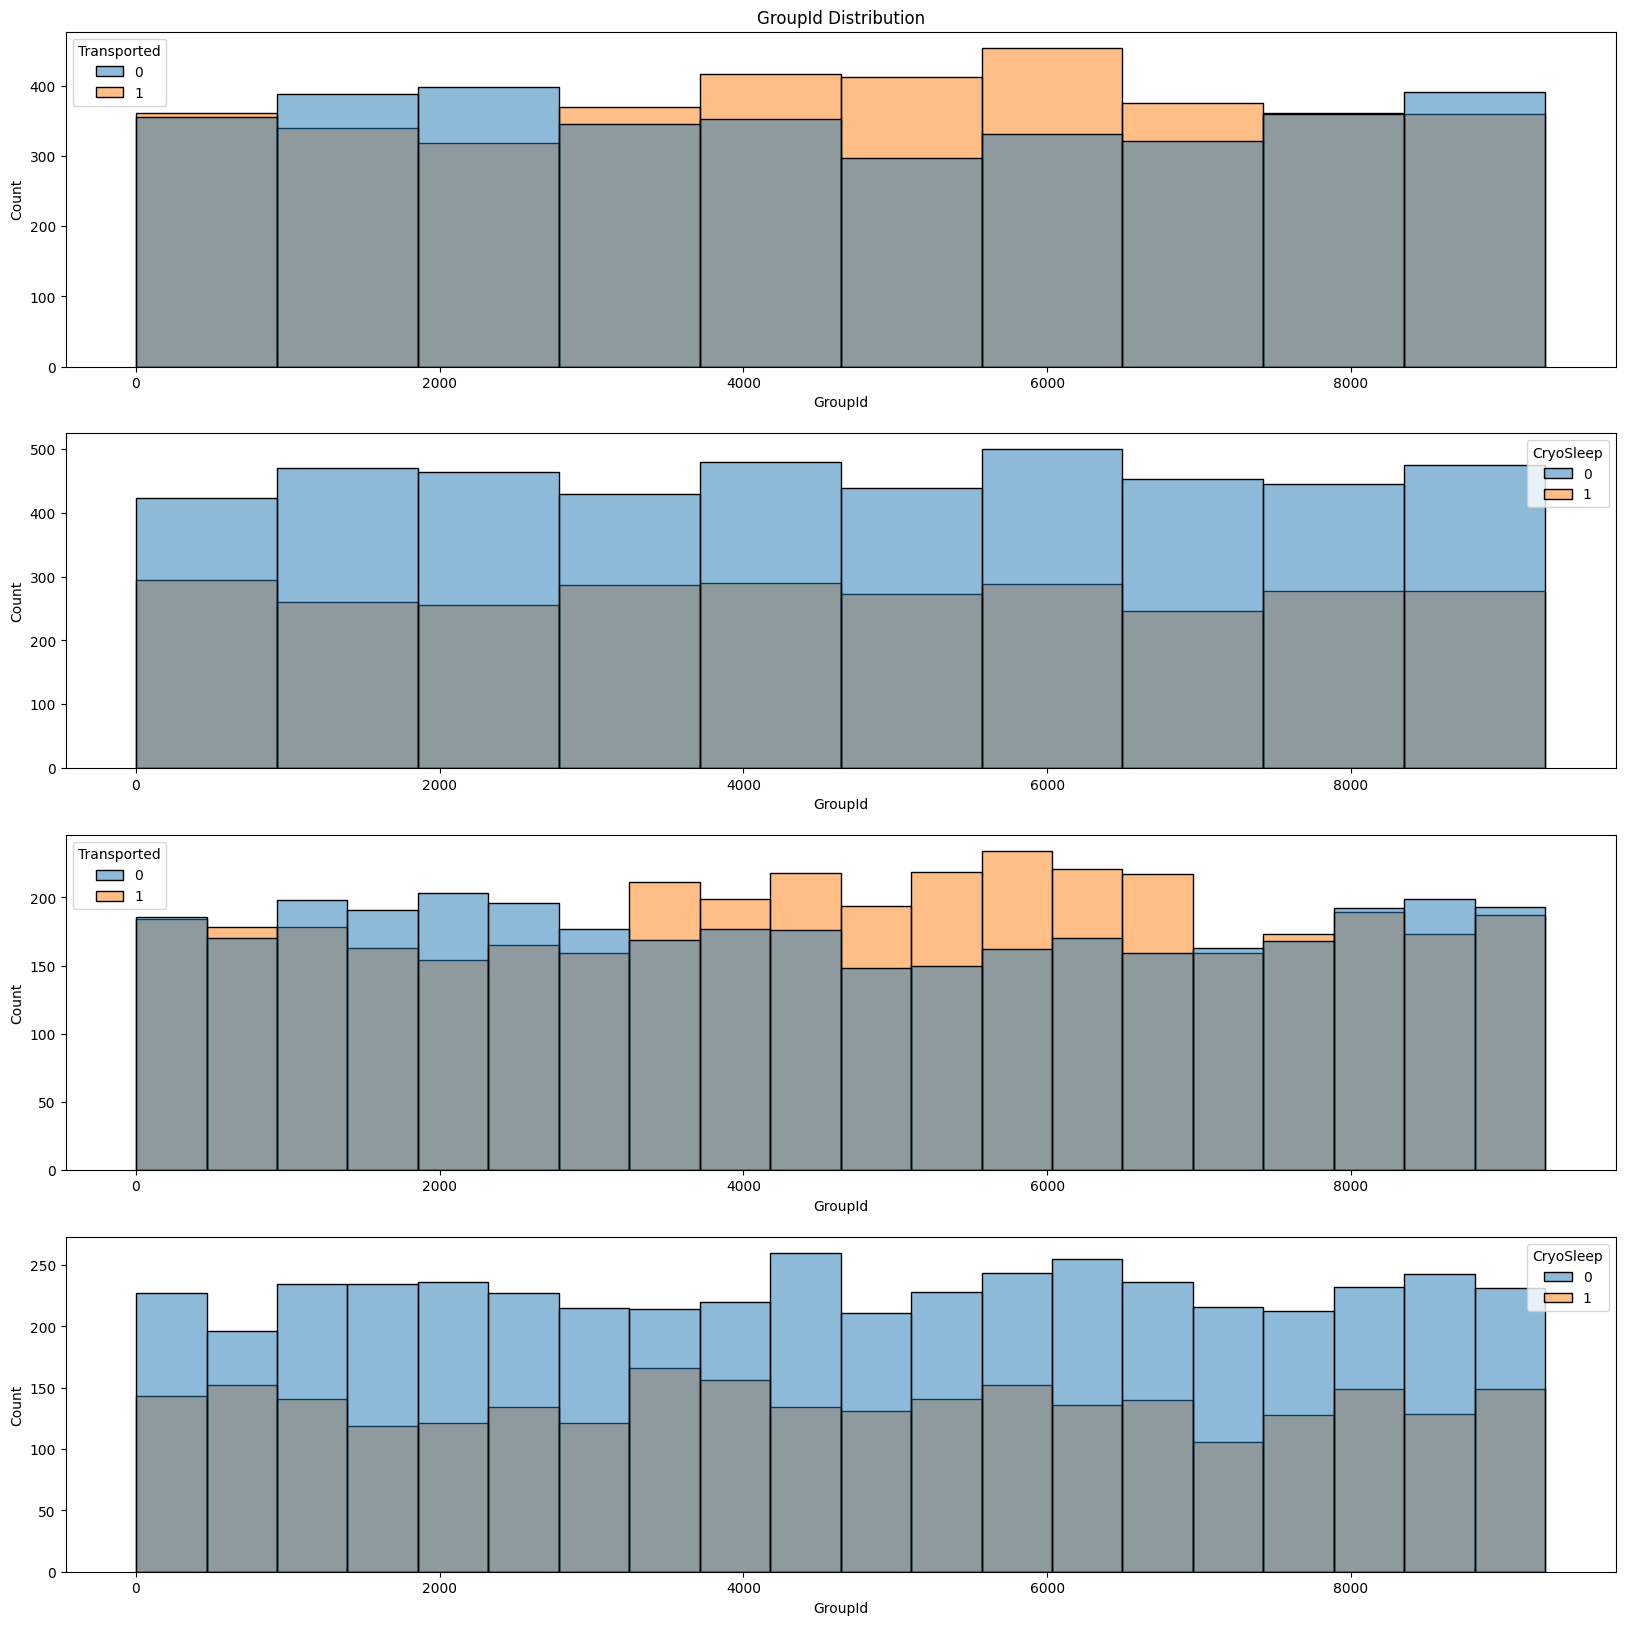

In [96]:
plot_hists_by_Cryo_and_Transported(df0, 'GroupId')

#### Looking at the histograms above we can see that for cabin numbers there are 4 main predictive regions while for GroupId we have 3 main predictive regions. Let's look even closer to see if these are simply explained by a difference in ratio of passengers in cryosleep vs not cryosleep since we know that the former are a lot more likely to be transported than the latter.

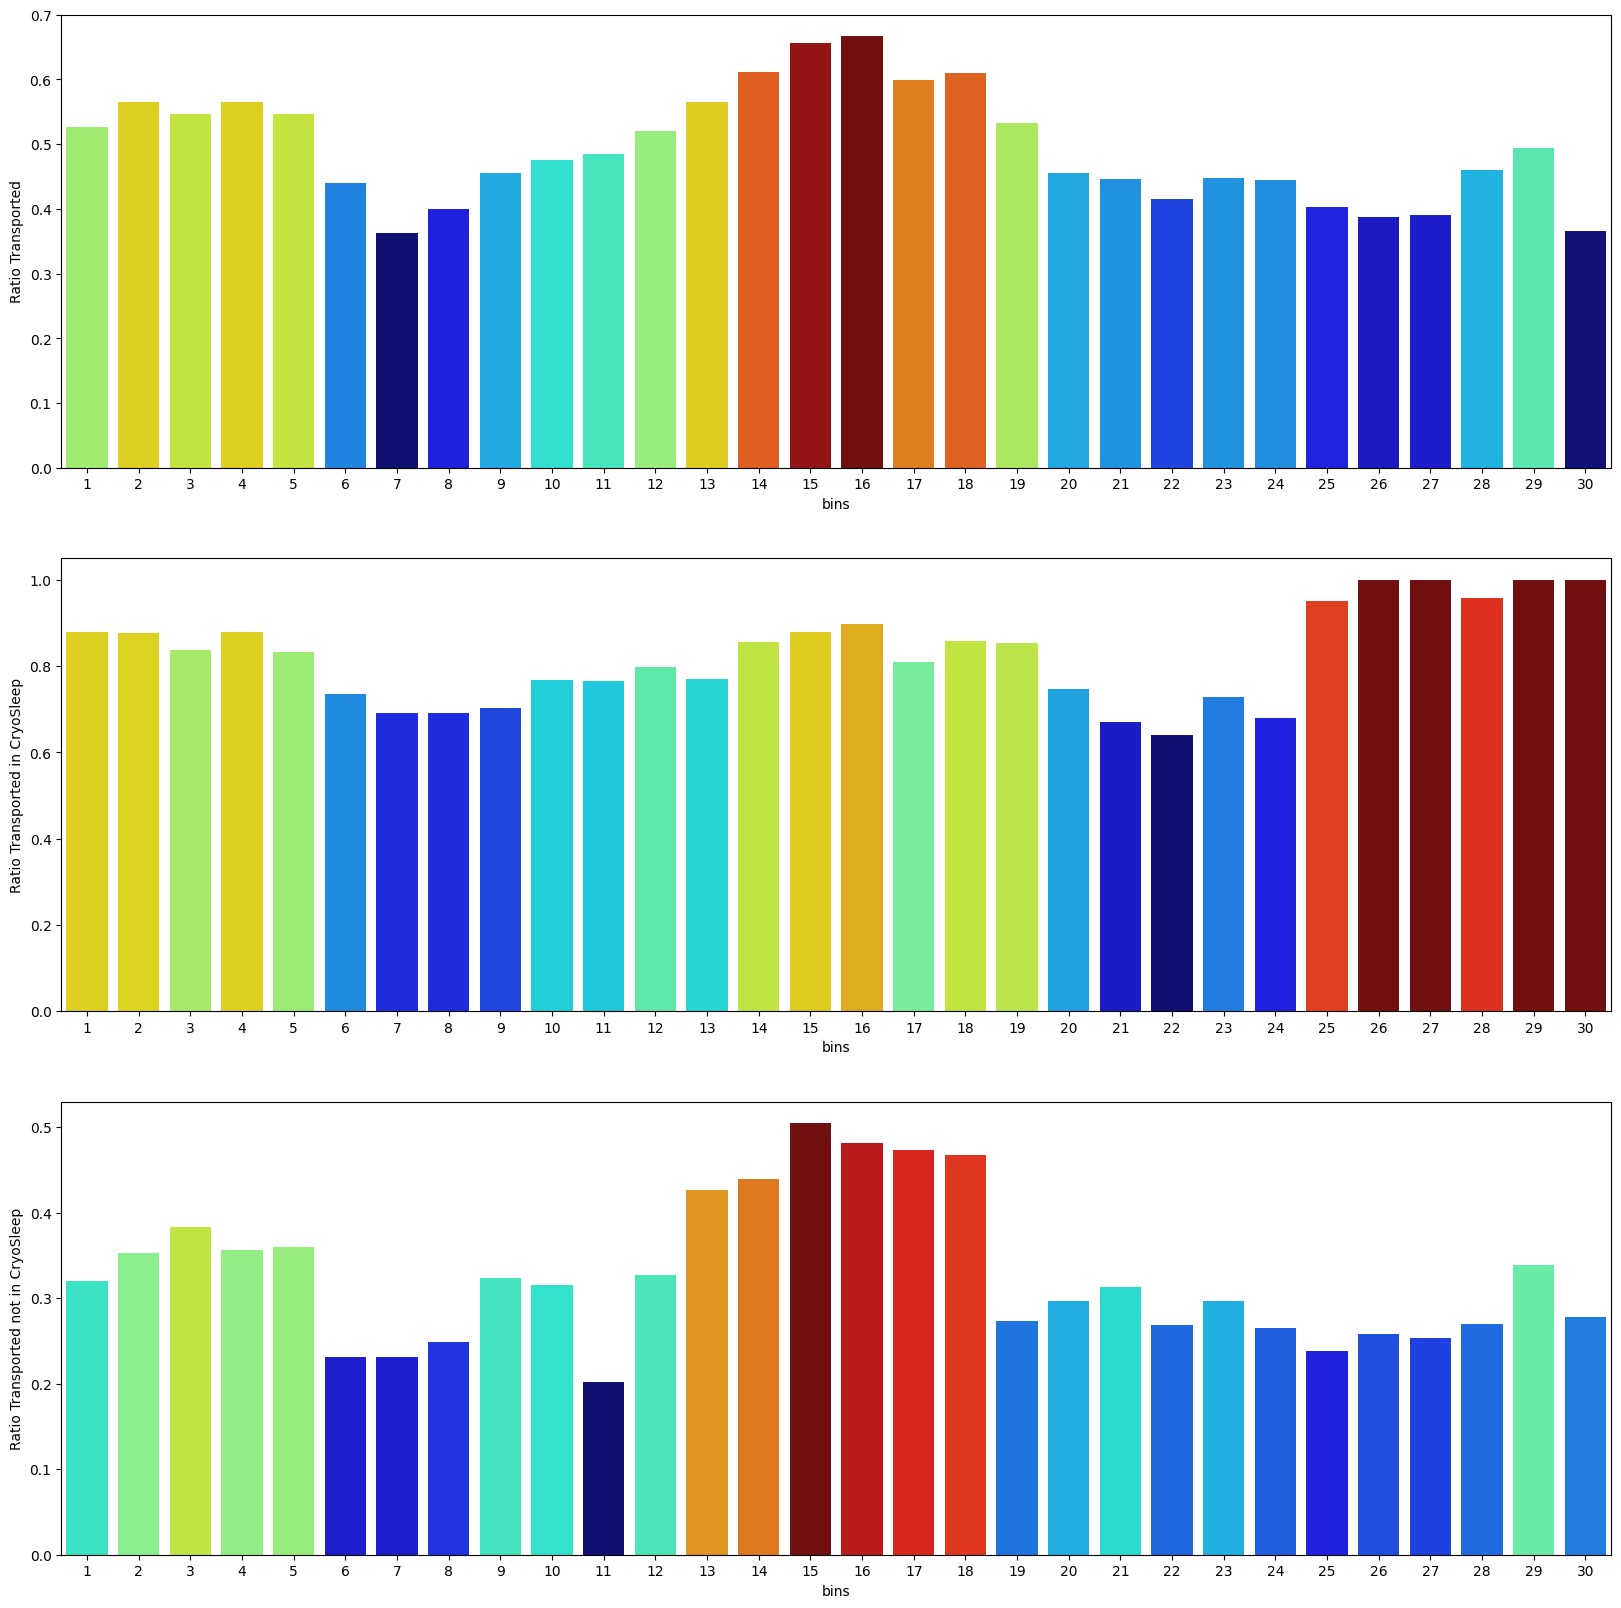

In [97]:
CaBin_ranges, df_num_groups = plot_ratios_by_Cryo_and_Transported(df0, 'Cabin Number', nbins = 30)

In [98]:
CaBin_ranges

[(np.float64(0.0), np.float64(63.1)),
 (np.float64(63.1), np.float64(126.3)),
 (np.float64(126.3), np.float64(189.4)),
 (np.float64(189.4), np.float64(252.5)),
 (np.float64(252.5), np.float64(315.7)),
 (np.float64(315.7), np.float64(378.8)),
 (np.float64(378.8), np.float64(441.9)),
 (np.float64(441.9), np.float64(505.1)),
 (np.float64(505.1), np.float64(568.2)),
 (np.float64(568.2), np.float64(631.3)),
 (np.float64(631.3), np.float64(694.5)),
 (np.float64(694.5), np.float64(757.6)),
 (np.float64(757.6), np.float64(820.7)),
 (np.float64(820.7), np.float64(883.9)),
 (np.float64(883.9), np.float64(947.0)),
 (np.float64(947.0), np.float64(1010.1)),
 (np.float64(1010.1), np.float64(1073.3)),
 (np.float64(1073.3), np.float64(1136.4)),
 (np.float64(1136.4), np.float64(1199.5)),
 (np.float64(1199.5), np.float64(1262.7)),
 (np.float64(1262.7), np.float64(1325.8)),
 (np.float64(1325.8), np.float64(1388.9)),
 (np.float64(1388.9), np.float64(1452.1)),
 (np.float64(1452.1), np.float64(1515.2)),
 (n

#### With this more detailed view we can find 5 main cabin regions:
* Region1: bins 1 - 5 ==> range = [0, 316)
* Region2: bins 6 - 12 ==> range = [316, 758)
* Region3: bins 13 - 18 ==> range = [758, 1137)
* Region4: bins 19 - 24 ==> range = [1137, 1516)
* Region5: bins 25 - 30 ==> range = [1516, inf)

In [99]:
bin_edges = [0, 316, 758, 1137, 1516]
df0 = Get_Regions(df0, 'Cabin Number', 'Region', bin_edges)

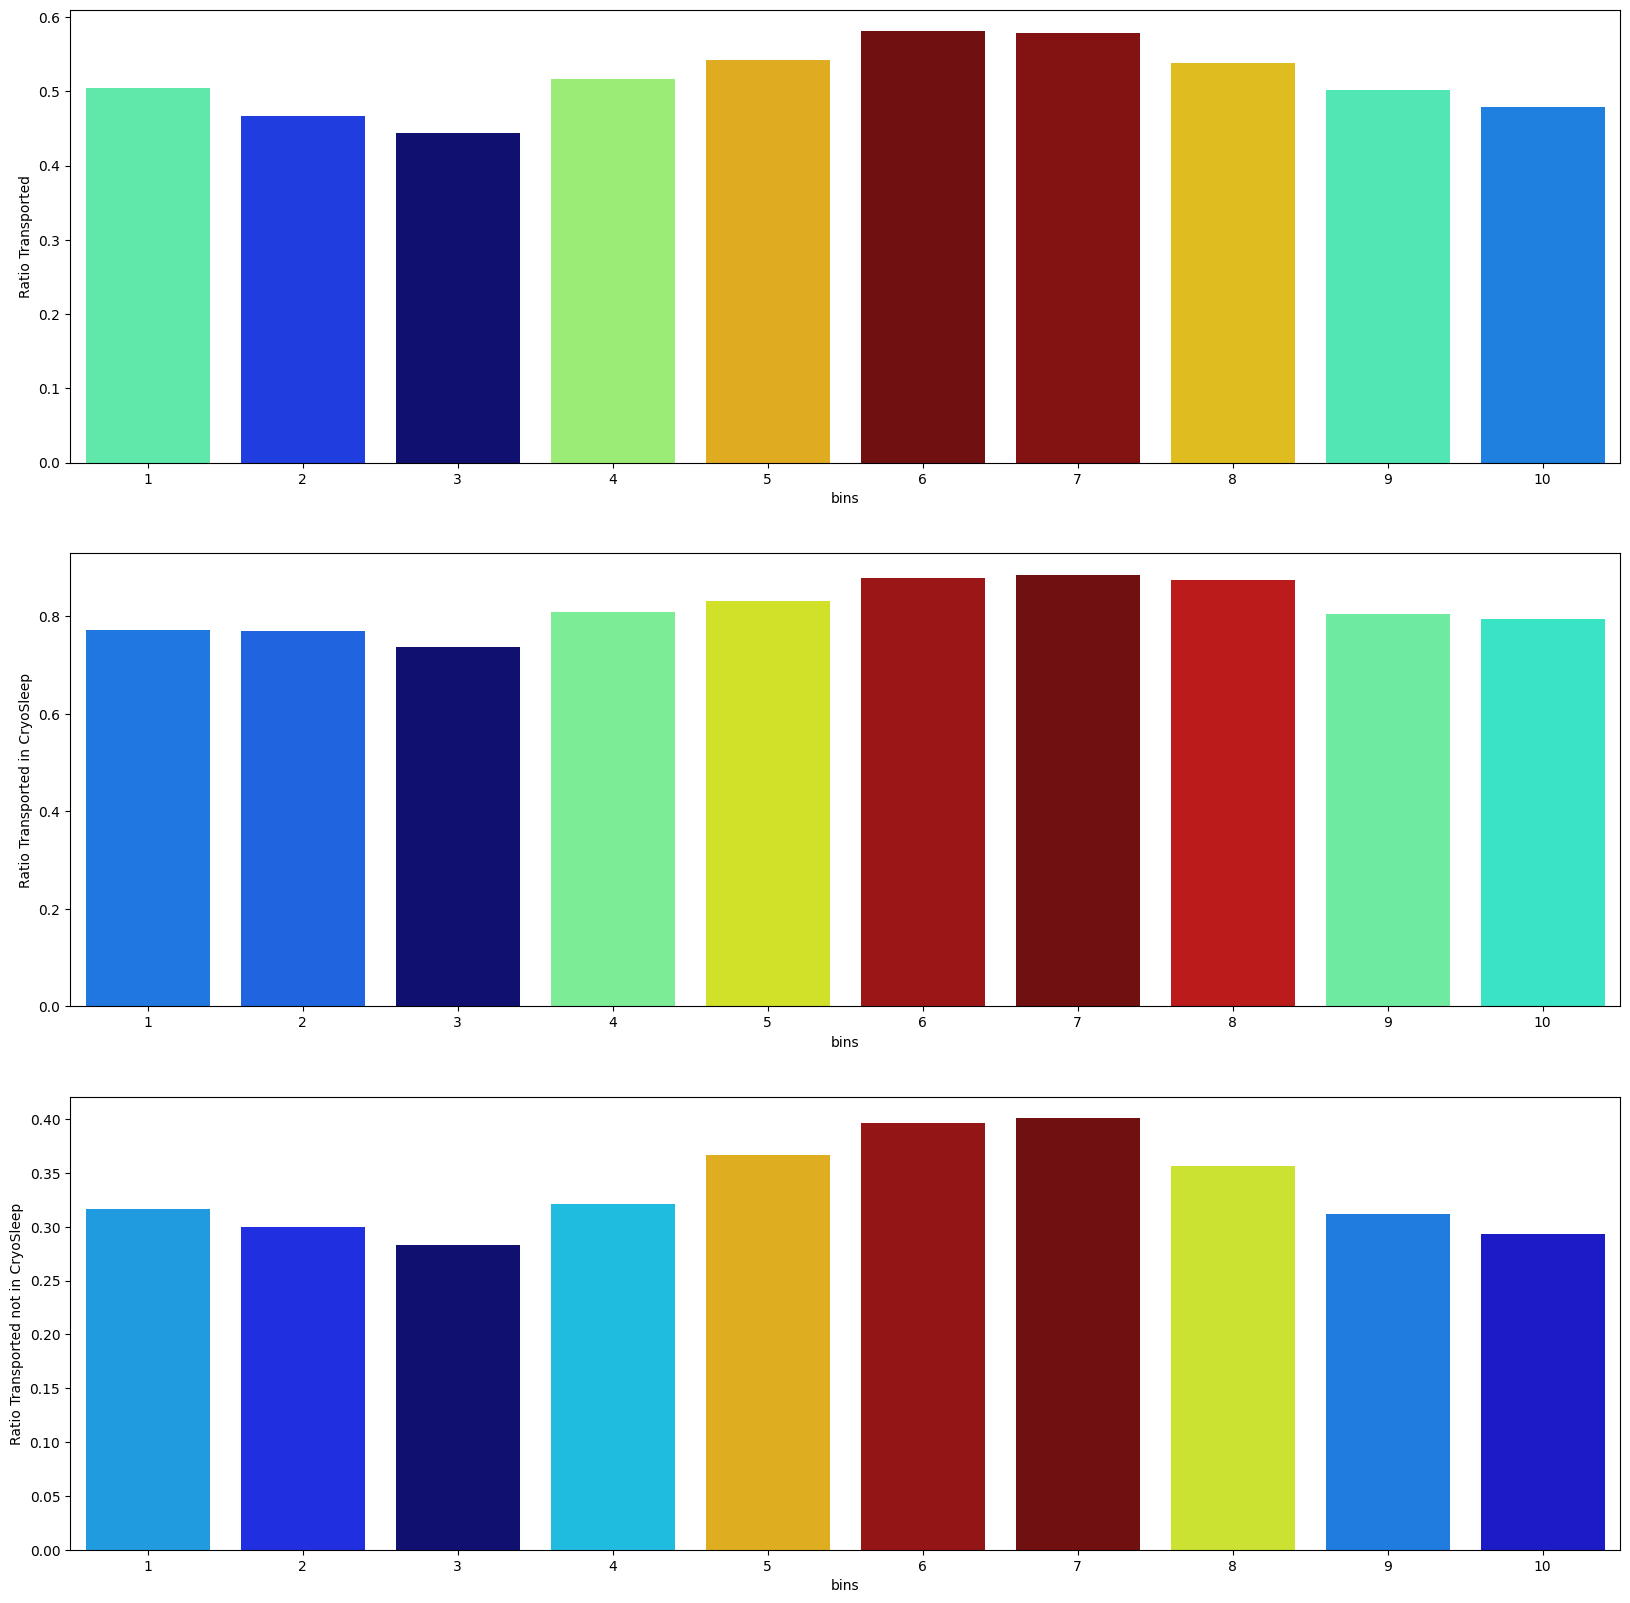

In [100]:
GrBin_ranges, df_num_groups = plot_ratios_by_Cryo_and_Transported(df0, 'GroupId', nbins = 10)

In [101]:
GrBin_ranges

[(np.float64(1.0), np.float64(928.9)),
 (np.float64(928.9), np.float64(1856.8)),
 (np.float64(1856.8), np.float64(2784.7)),
 (np.float64(2784.7), np.float64(3712.6)),
 (np.float64(3712.6), np.float64(4640.5)),
 (np.float64(4640.5), np.float64(5568.4)),
 (np.float64(5568.4), np.float64(6496.3)),
 (np.float64(6496.3), np.float64(7424.2)),
 (np.float64(7424.2), np.float64(8352.1)),
 (np.float64(8352.1), np.float64(9280.0))]

#### Similarly we find 5 main GroupId groups:
* Group1: bins 1 - 4 ==> range = [1, 3713)
* Group2: bins 5 ==> range = [3713, 4641)
* Group3: bins 6 - 7 ==> range = [4641, 6497)
* Group4: bins 8 ==> range = [6497, 7425)
* Group5: bins 9 - 10 ==> range = [7425, inf)
#### It might also be helpful to keep G1. We need to see the effect on prediction

In [102]:
bin_edges = [1, 3713, 4641, 6497, 7425]
df0 = Get_Regions(df0, 'GroupId', 'Batch', bin_edges)

#### CabinSize, GroupSize, & ppId

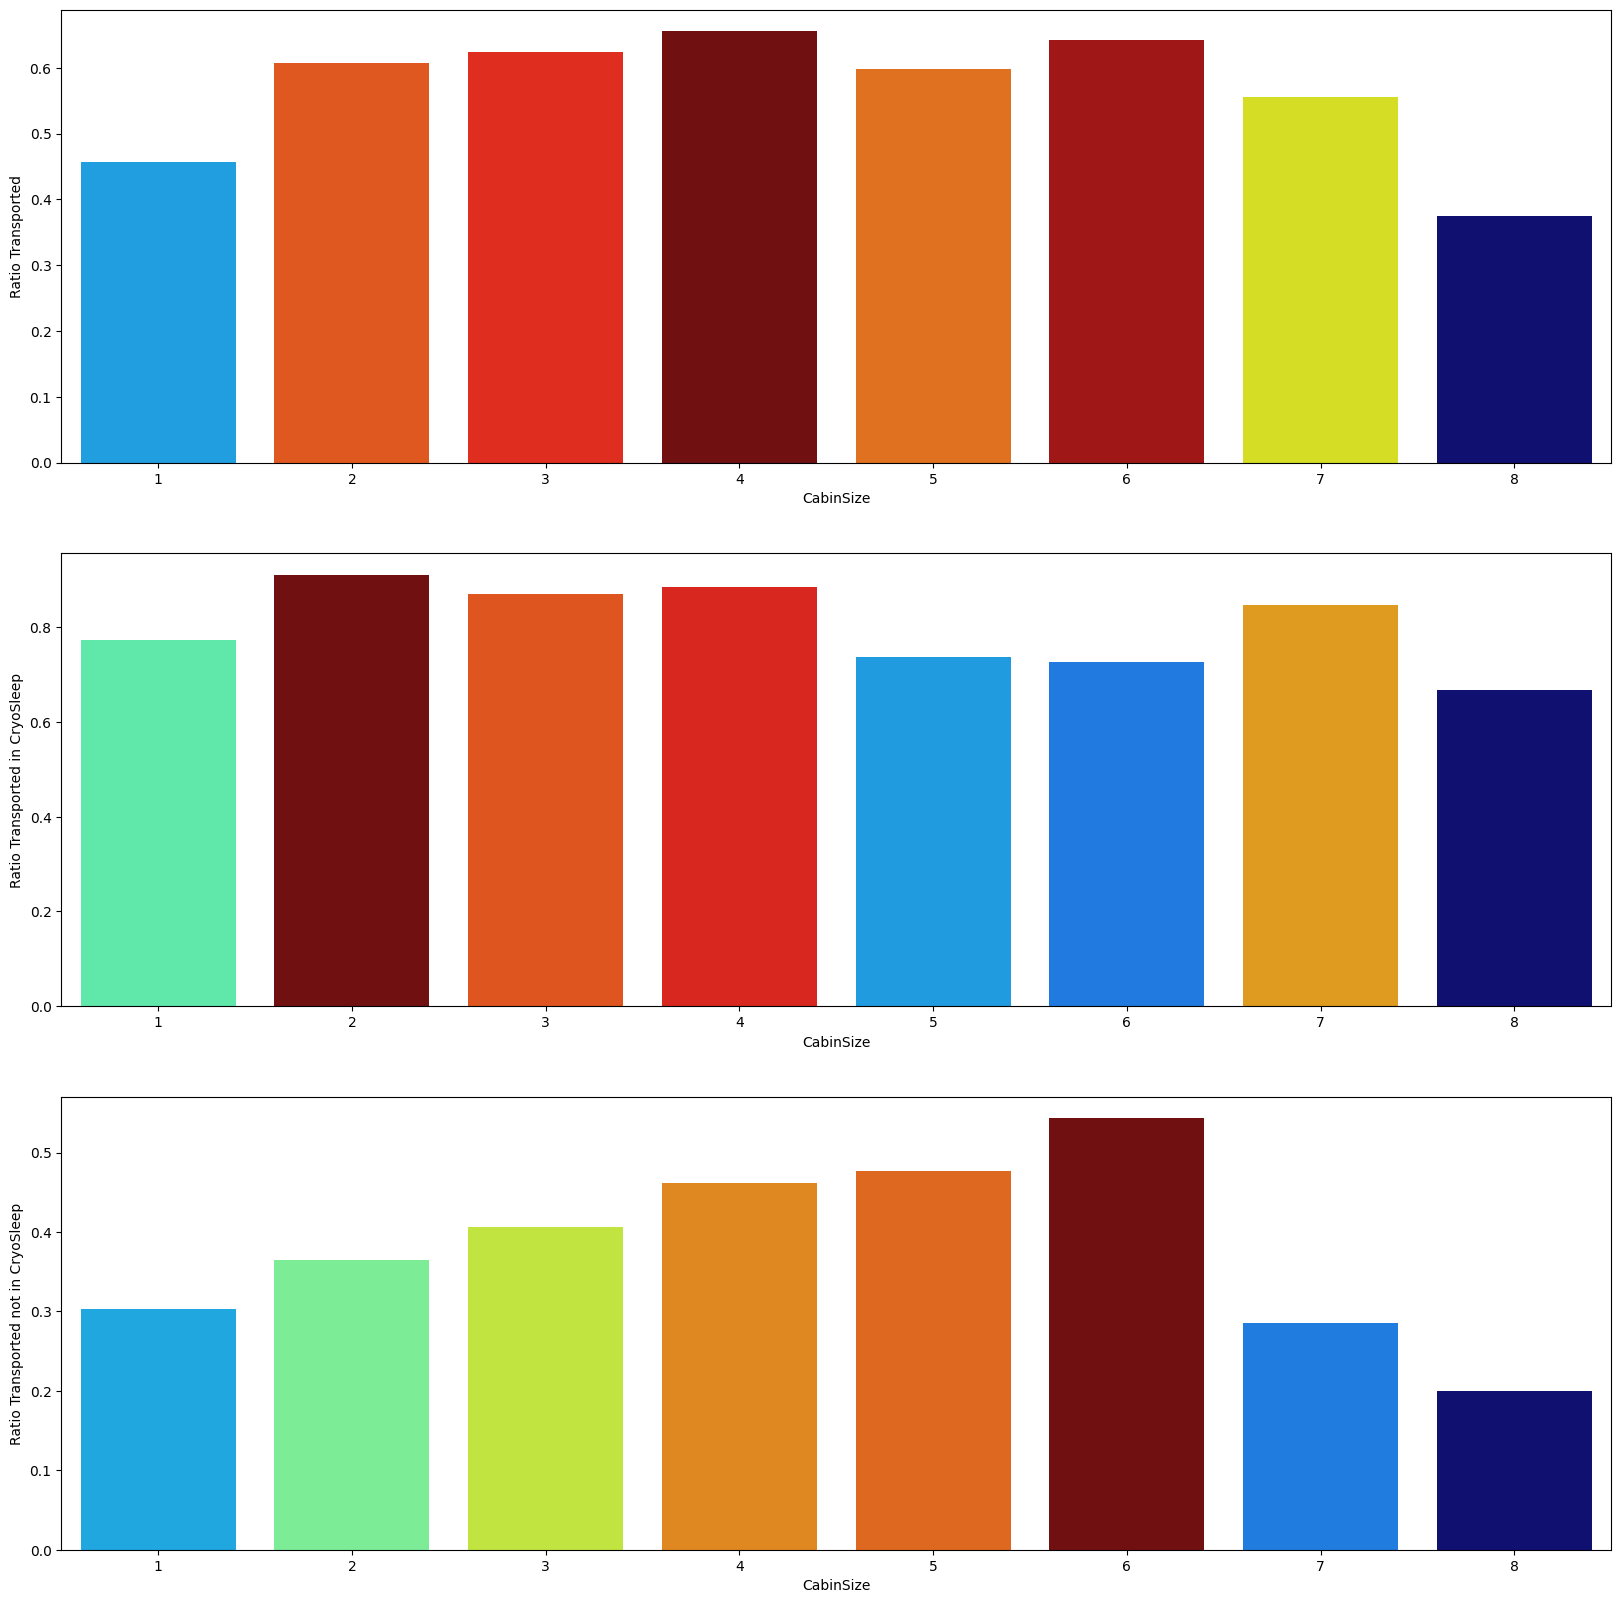

In [103]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'CabinSize', cat = True)

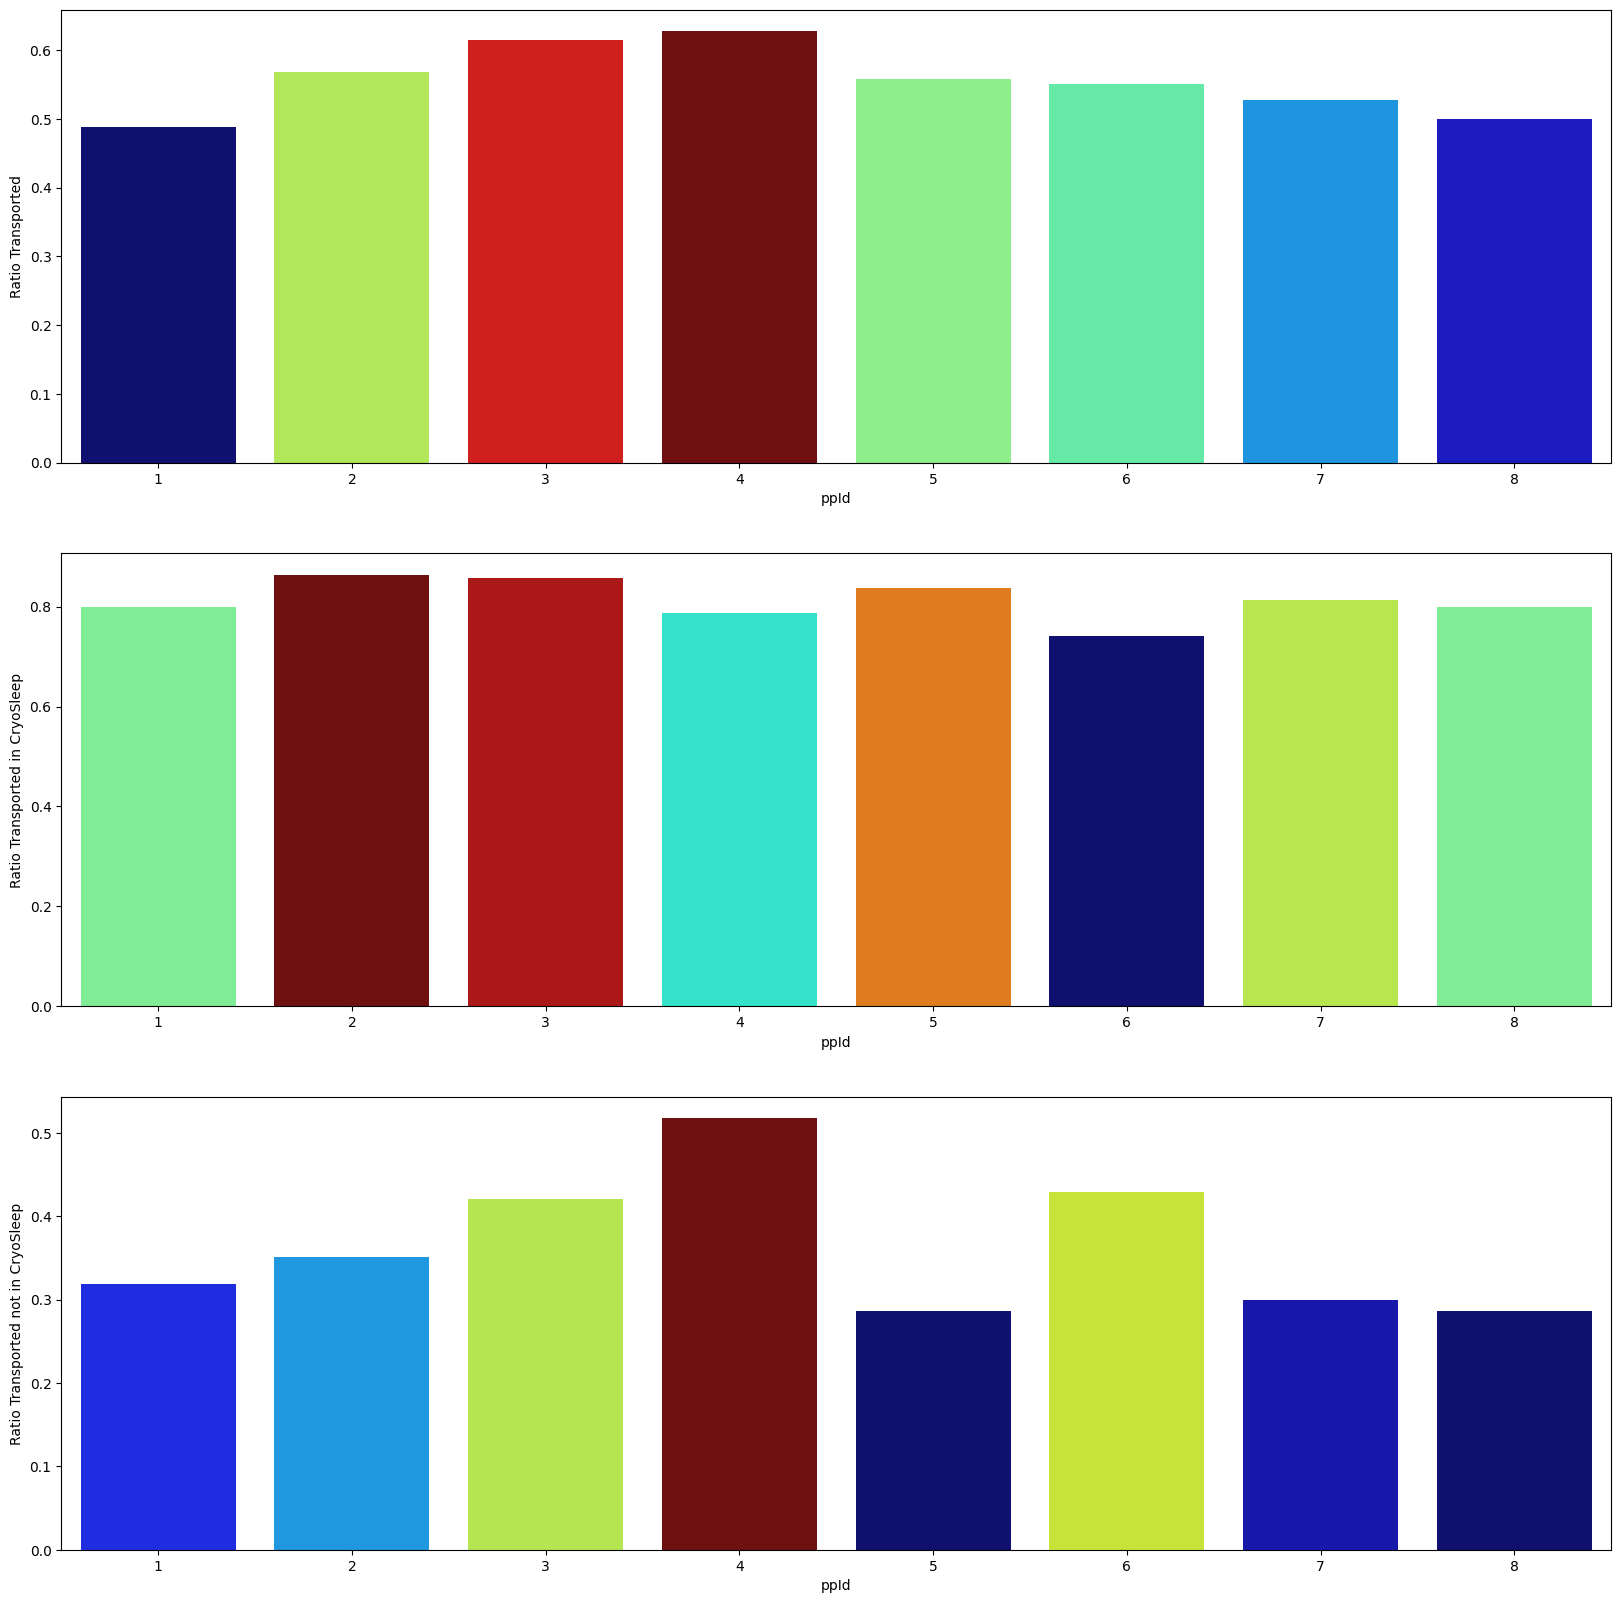

In [104]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'ppId', cat = True)

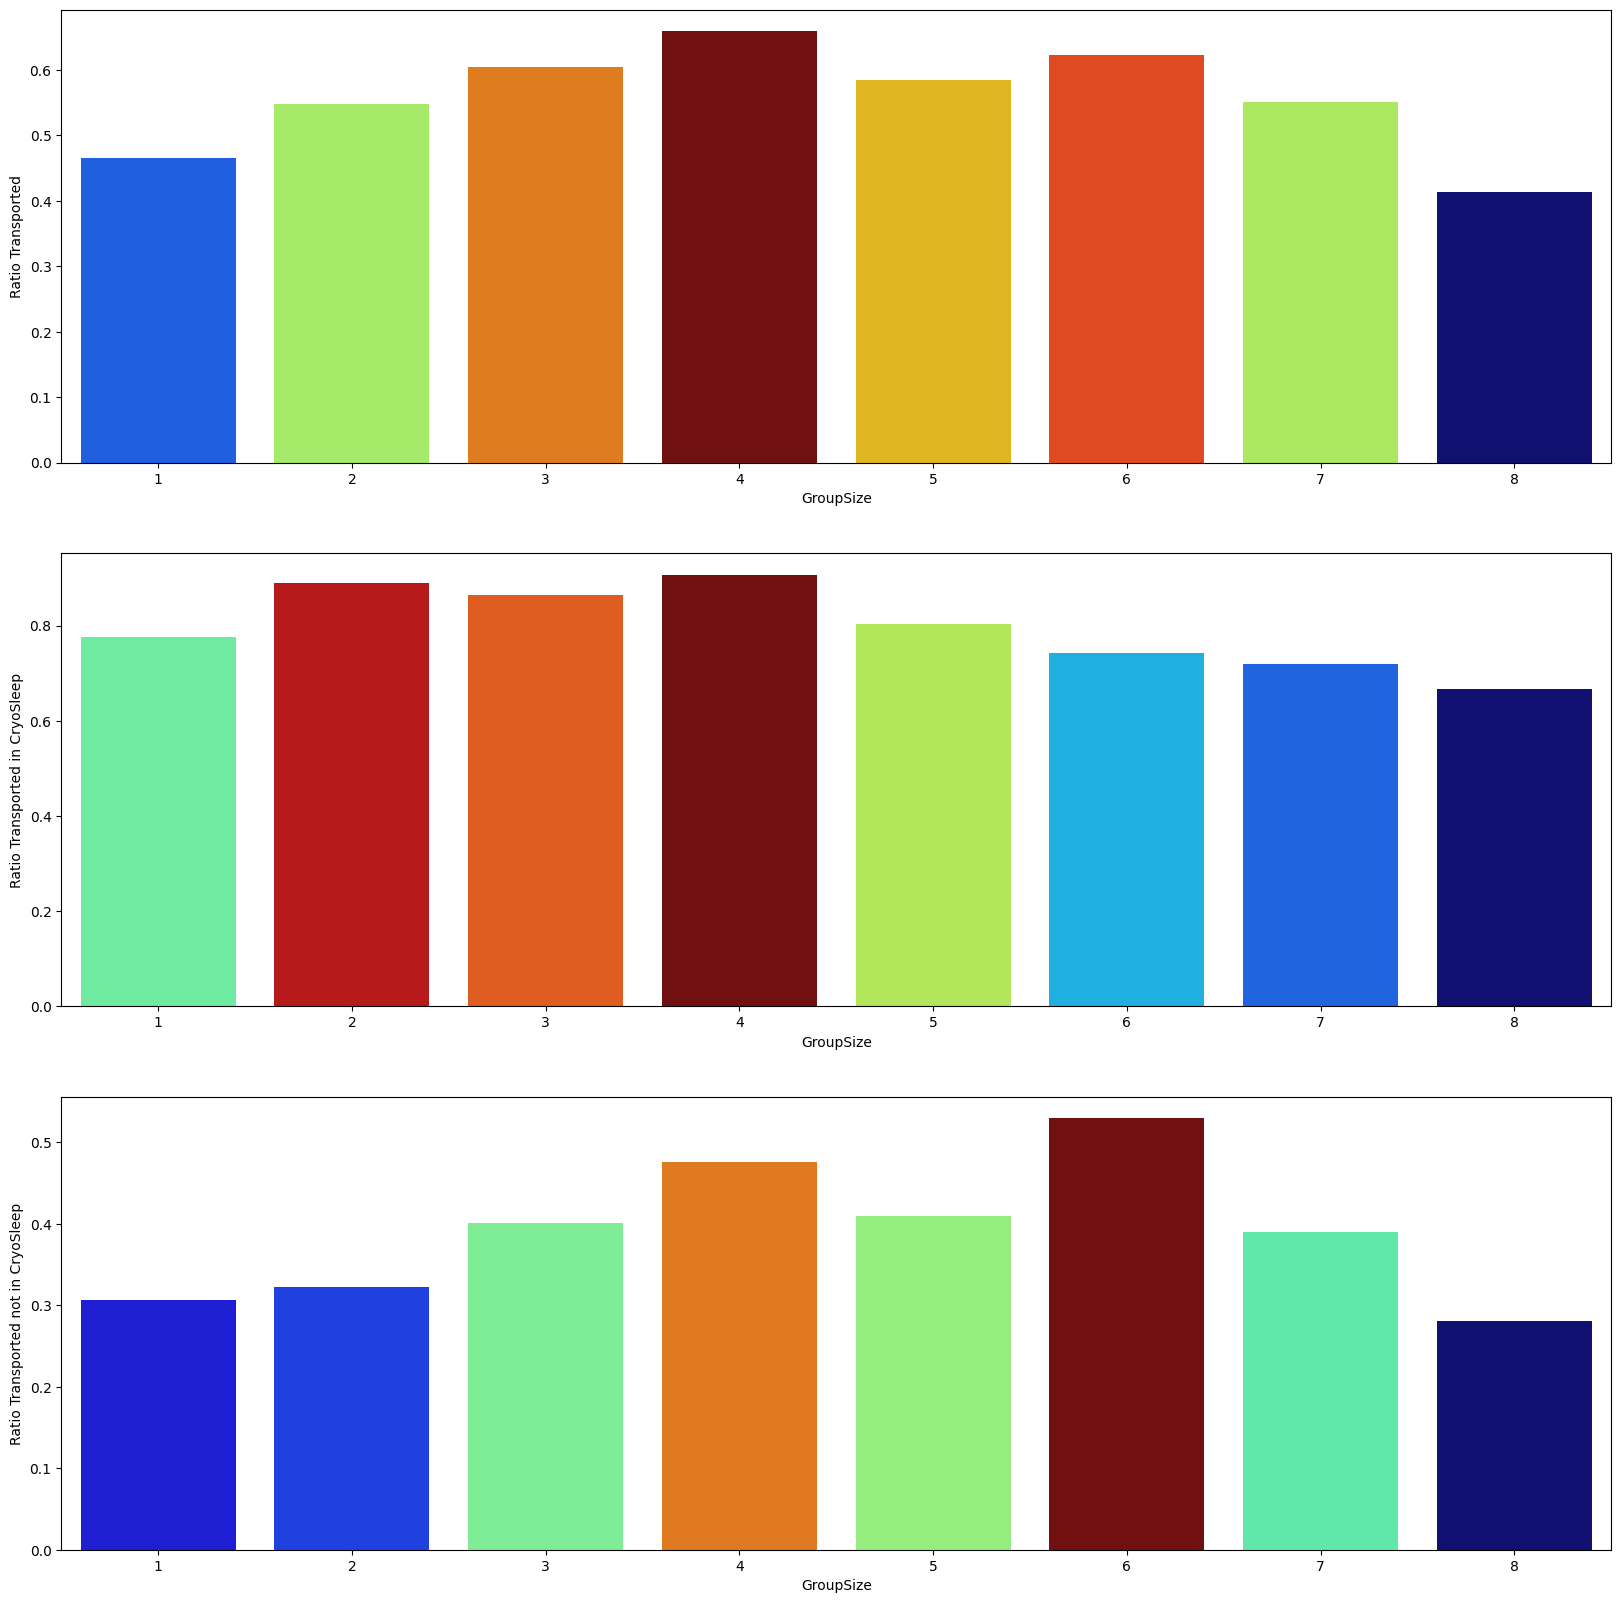

In [105]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'GroupSize', cat = True)

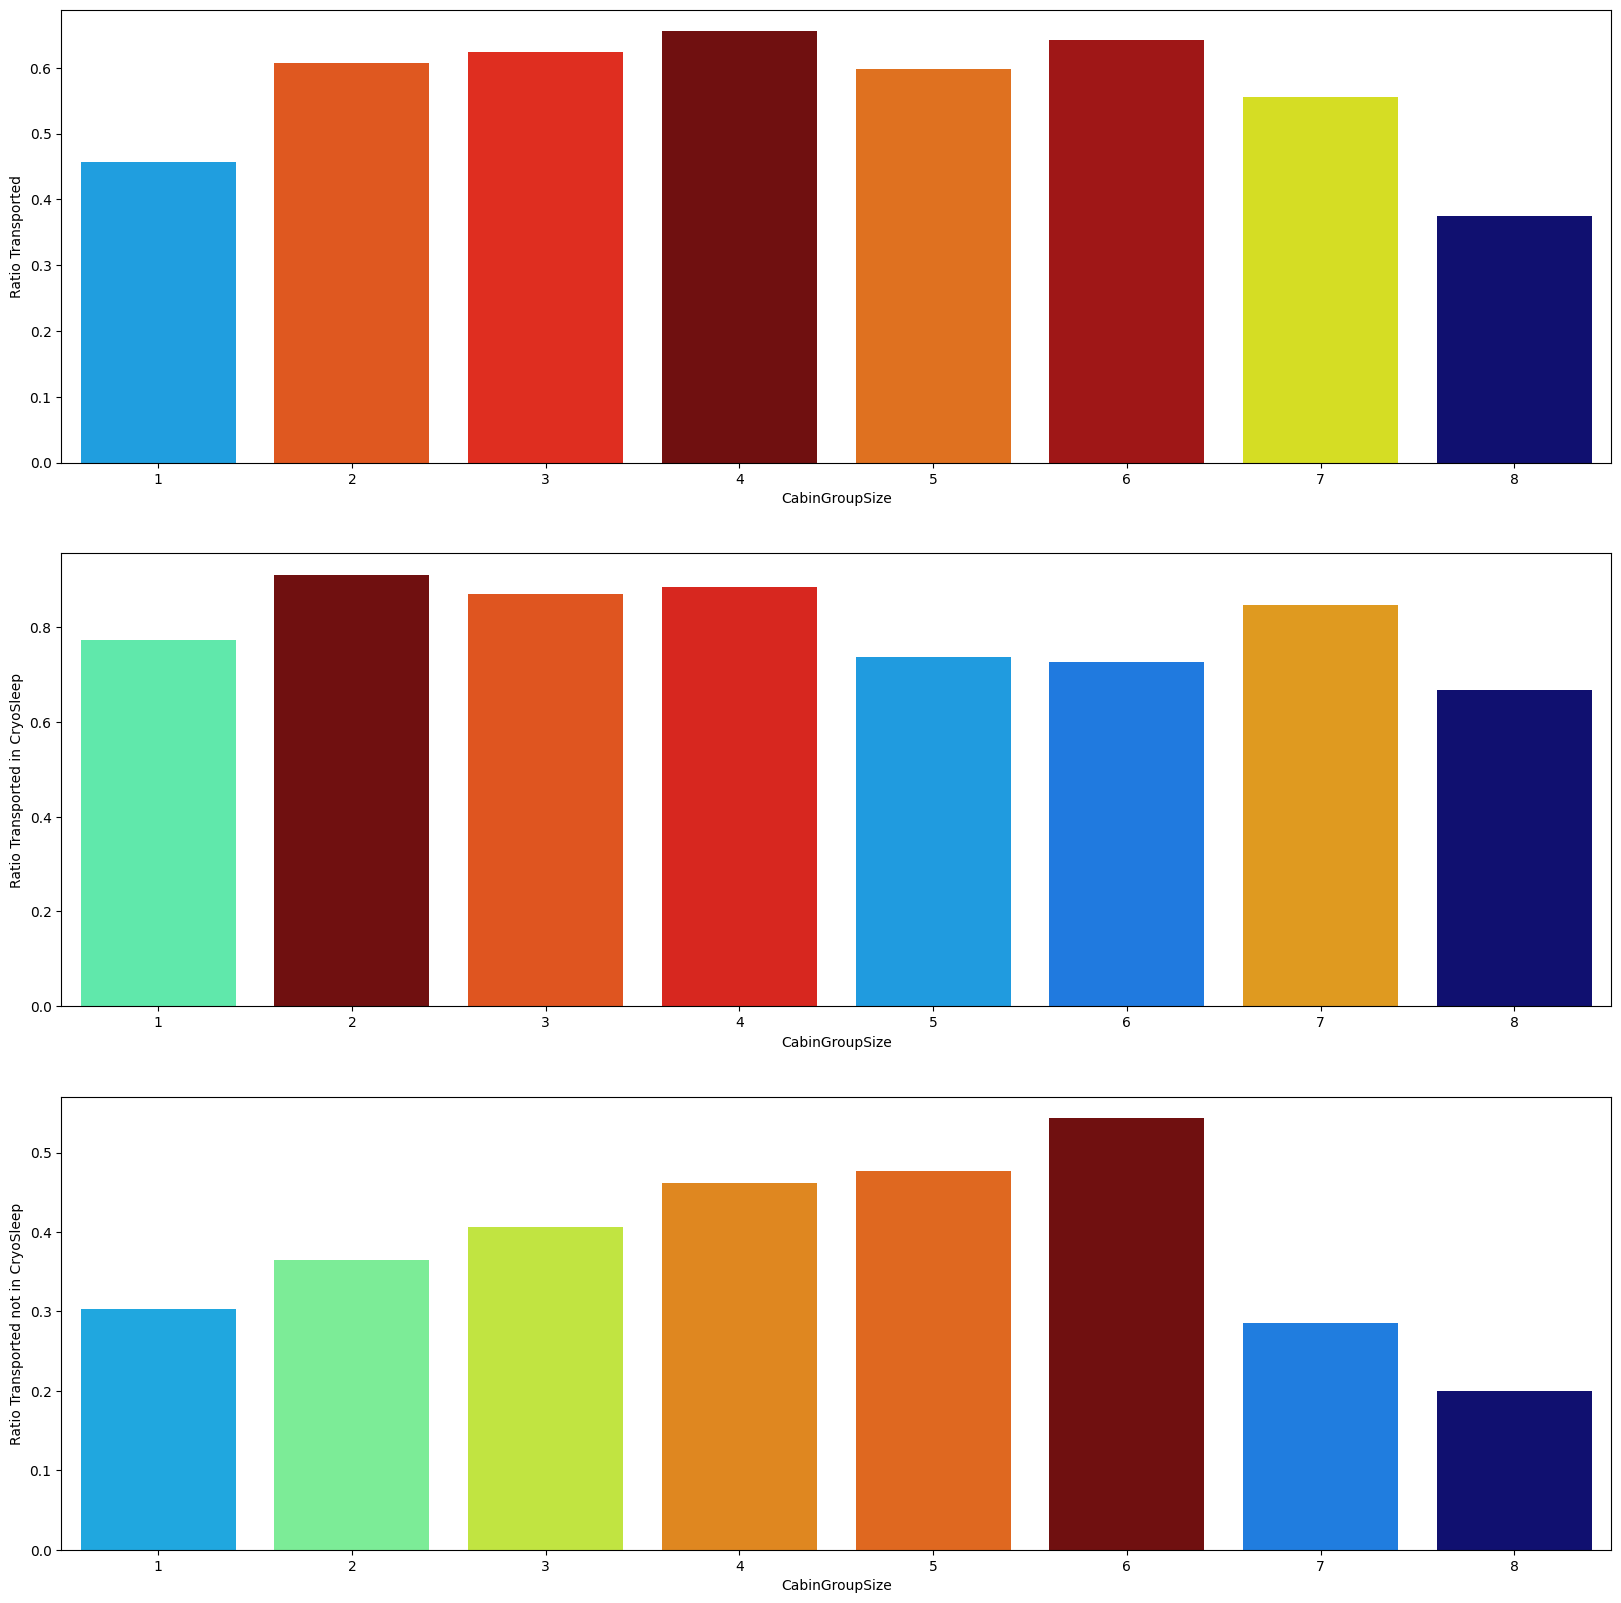

In [106]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'CabinGroupSize', cat = True)

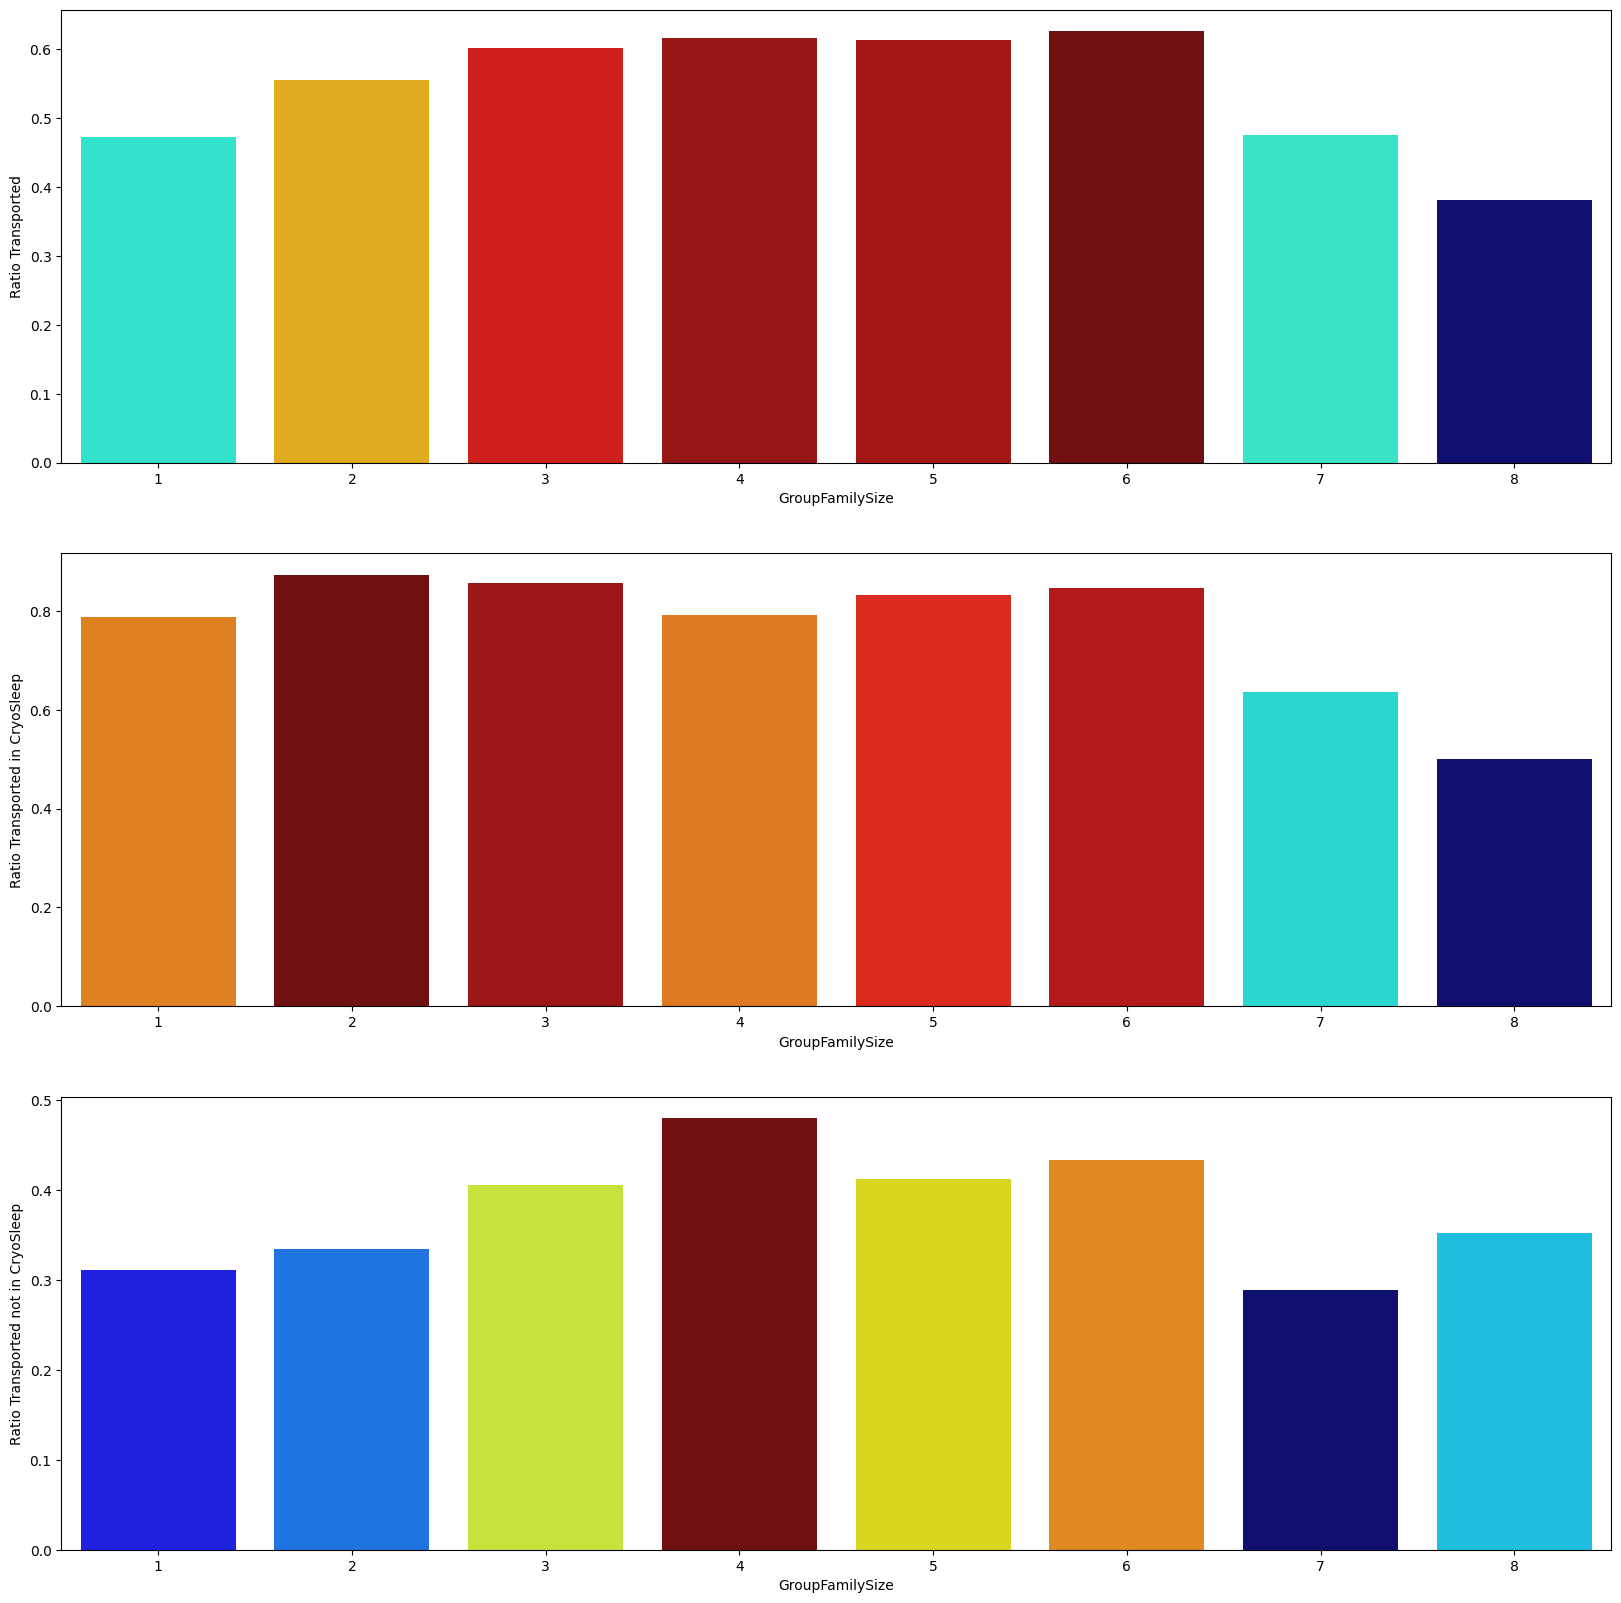

In [107]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'GroupFamilySize', cat = True)

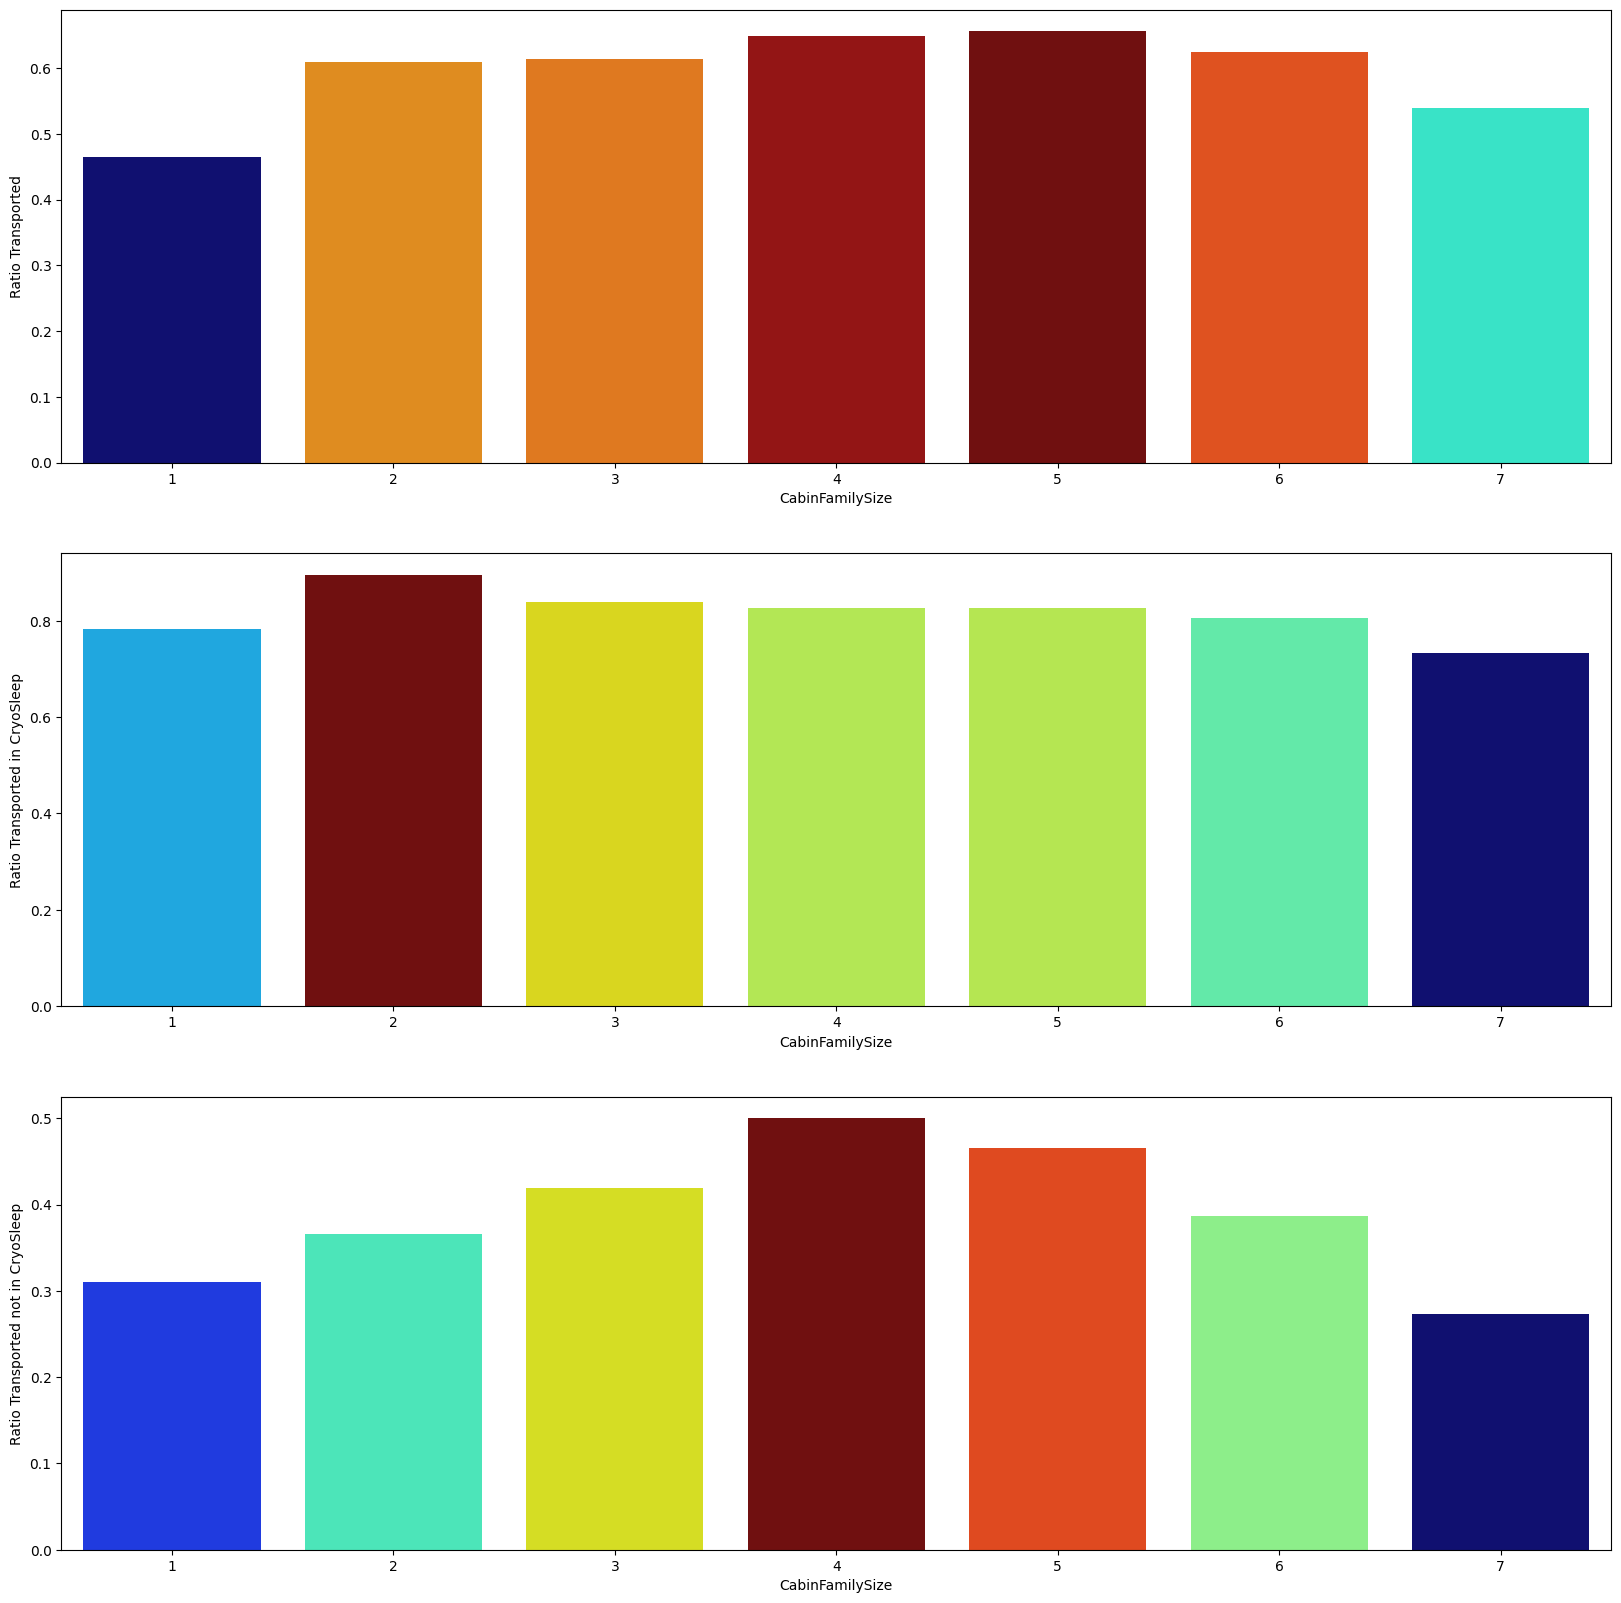

In [108]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'CabinFamilySize', cat = True)

#### Name Lengths

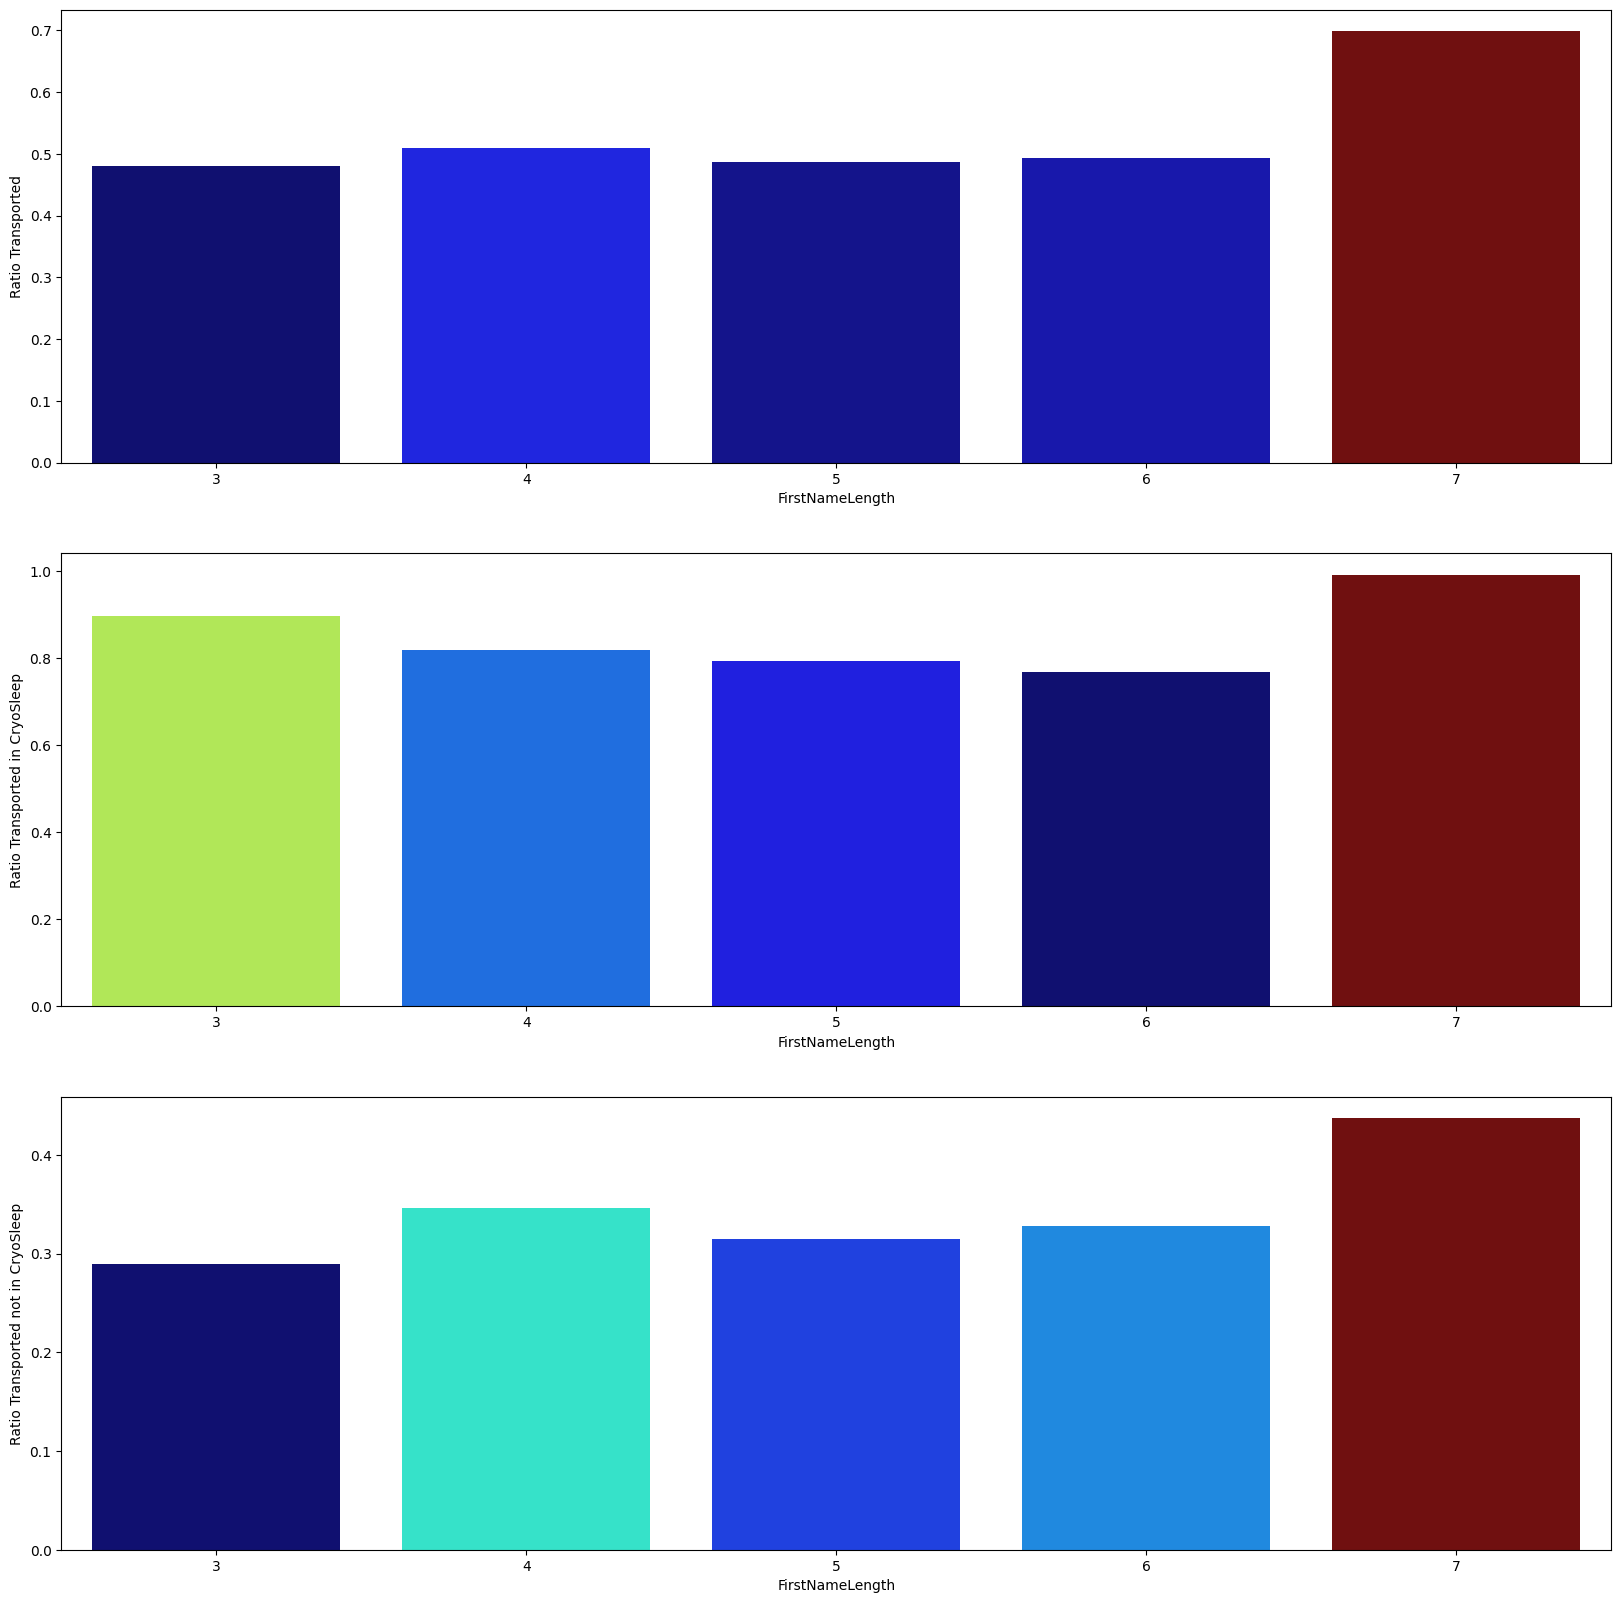

In [109]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'FirstNameLength', cat = True)

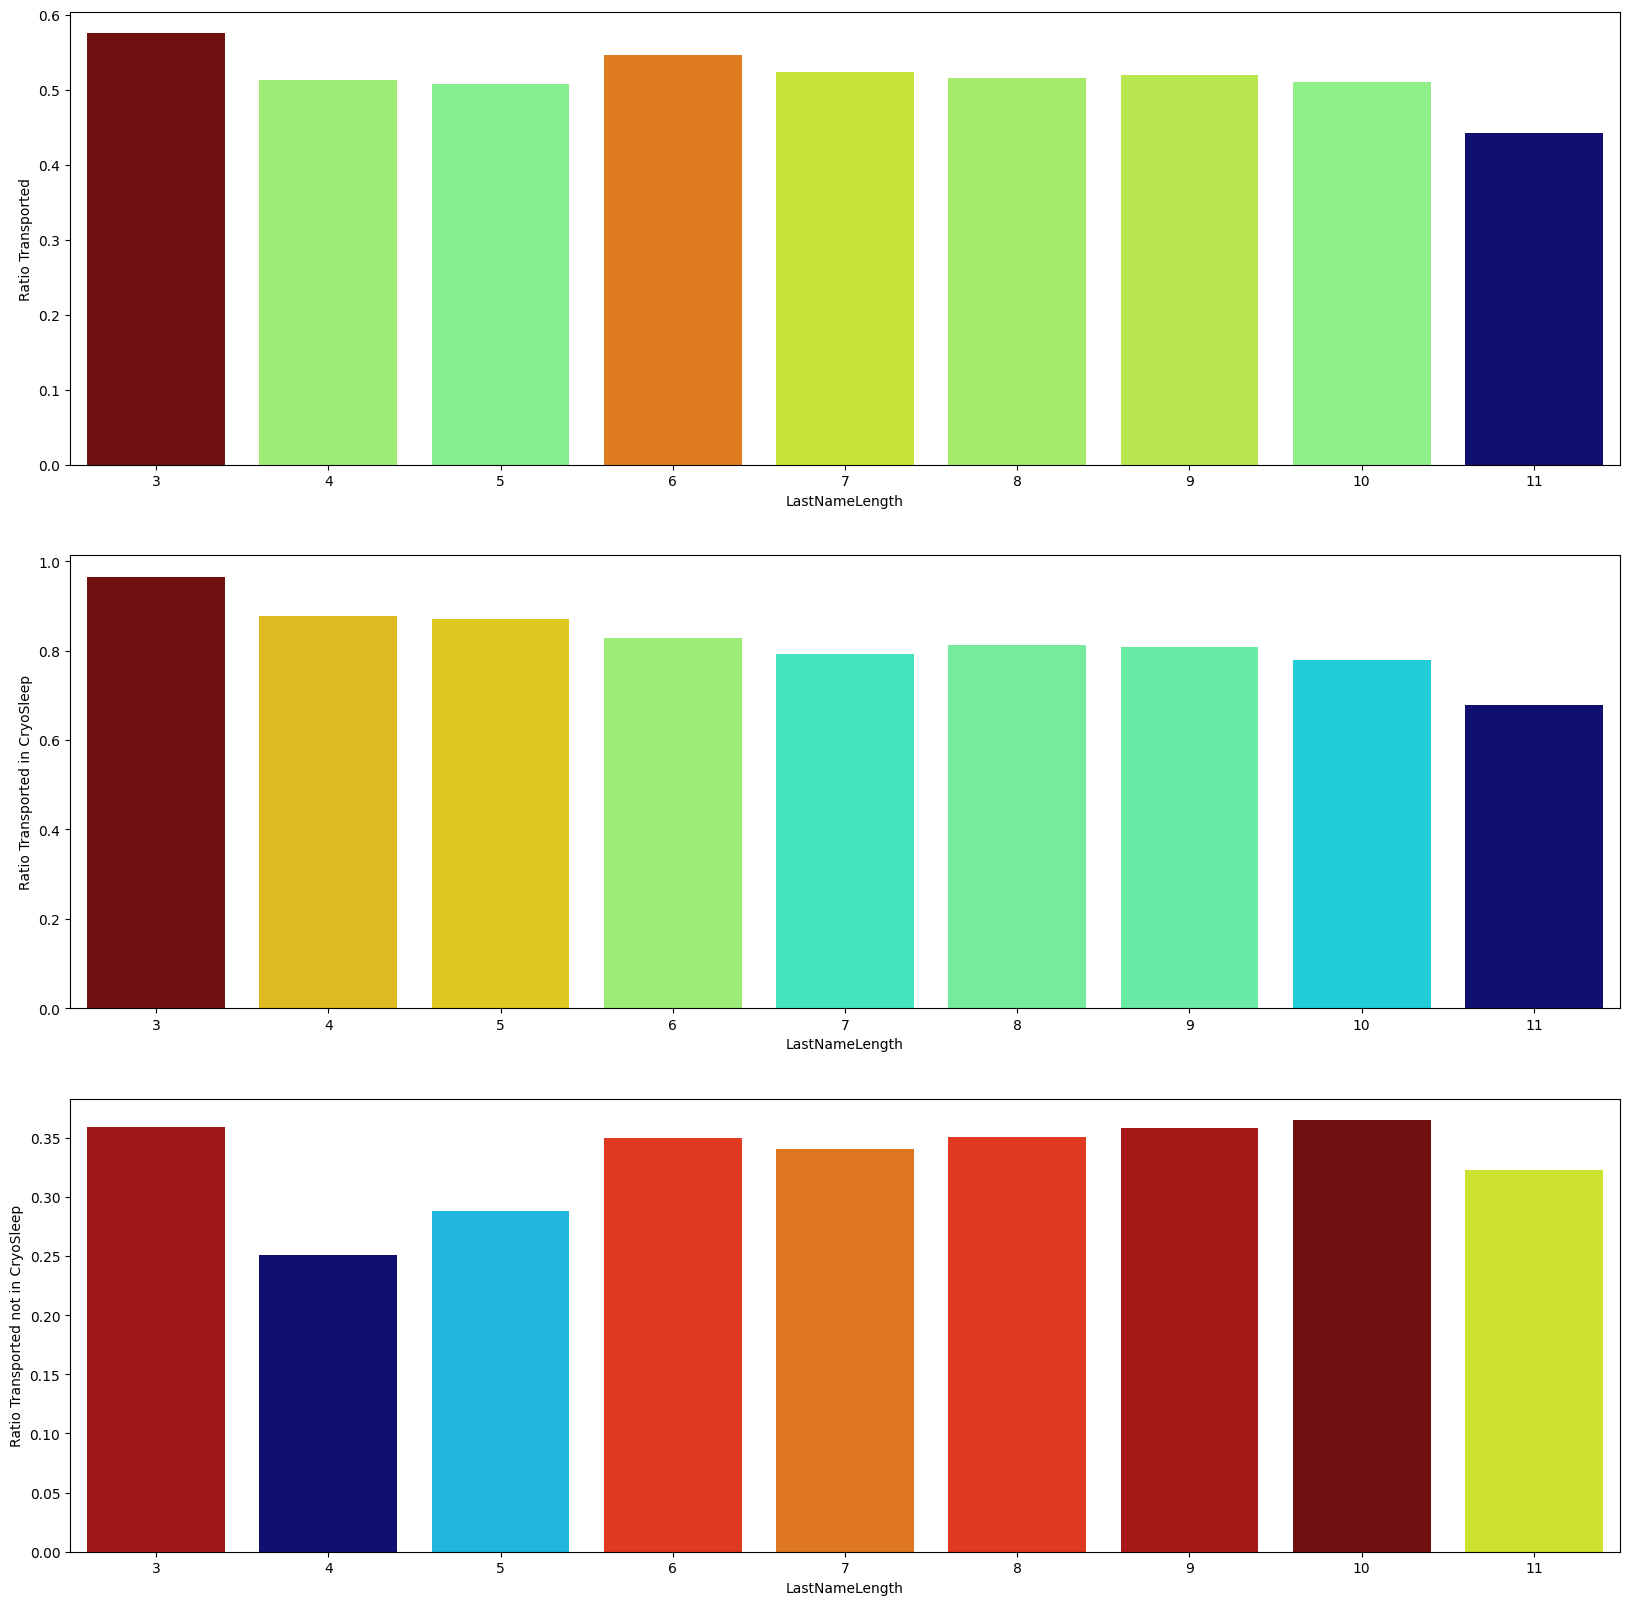

In [110]:
_, _ = plot_ratios_by_Cryo_and_Transported(df0, 'LastNameLength', cat = True)

#### For FirstNameLength it seems to matter whether it is a long name (7 letters or more) or not. However, this effect might be because passengers from Europa tend to have longer names and also are more likely to be transported overall. Let's check the distribution among passengers from Europa only. Similarly, short Family Names (3, 4) are all from Mars

In [111]:
df1 = pd.concat([df0, df_clean[['HomePlanet']]], axis = 1)

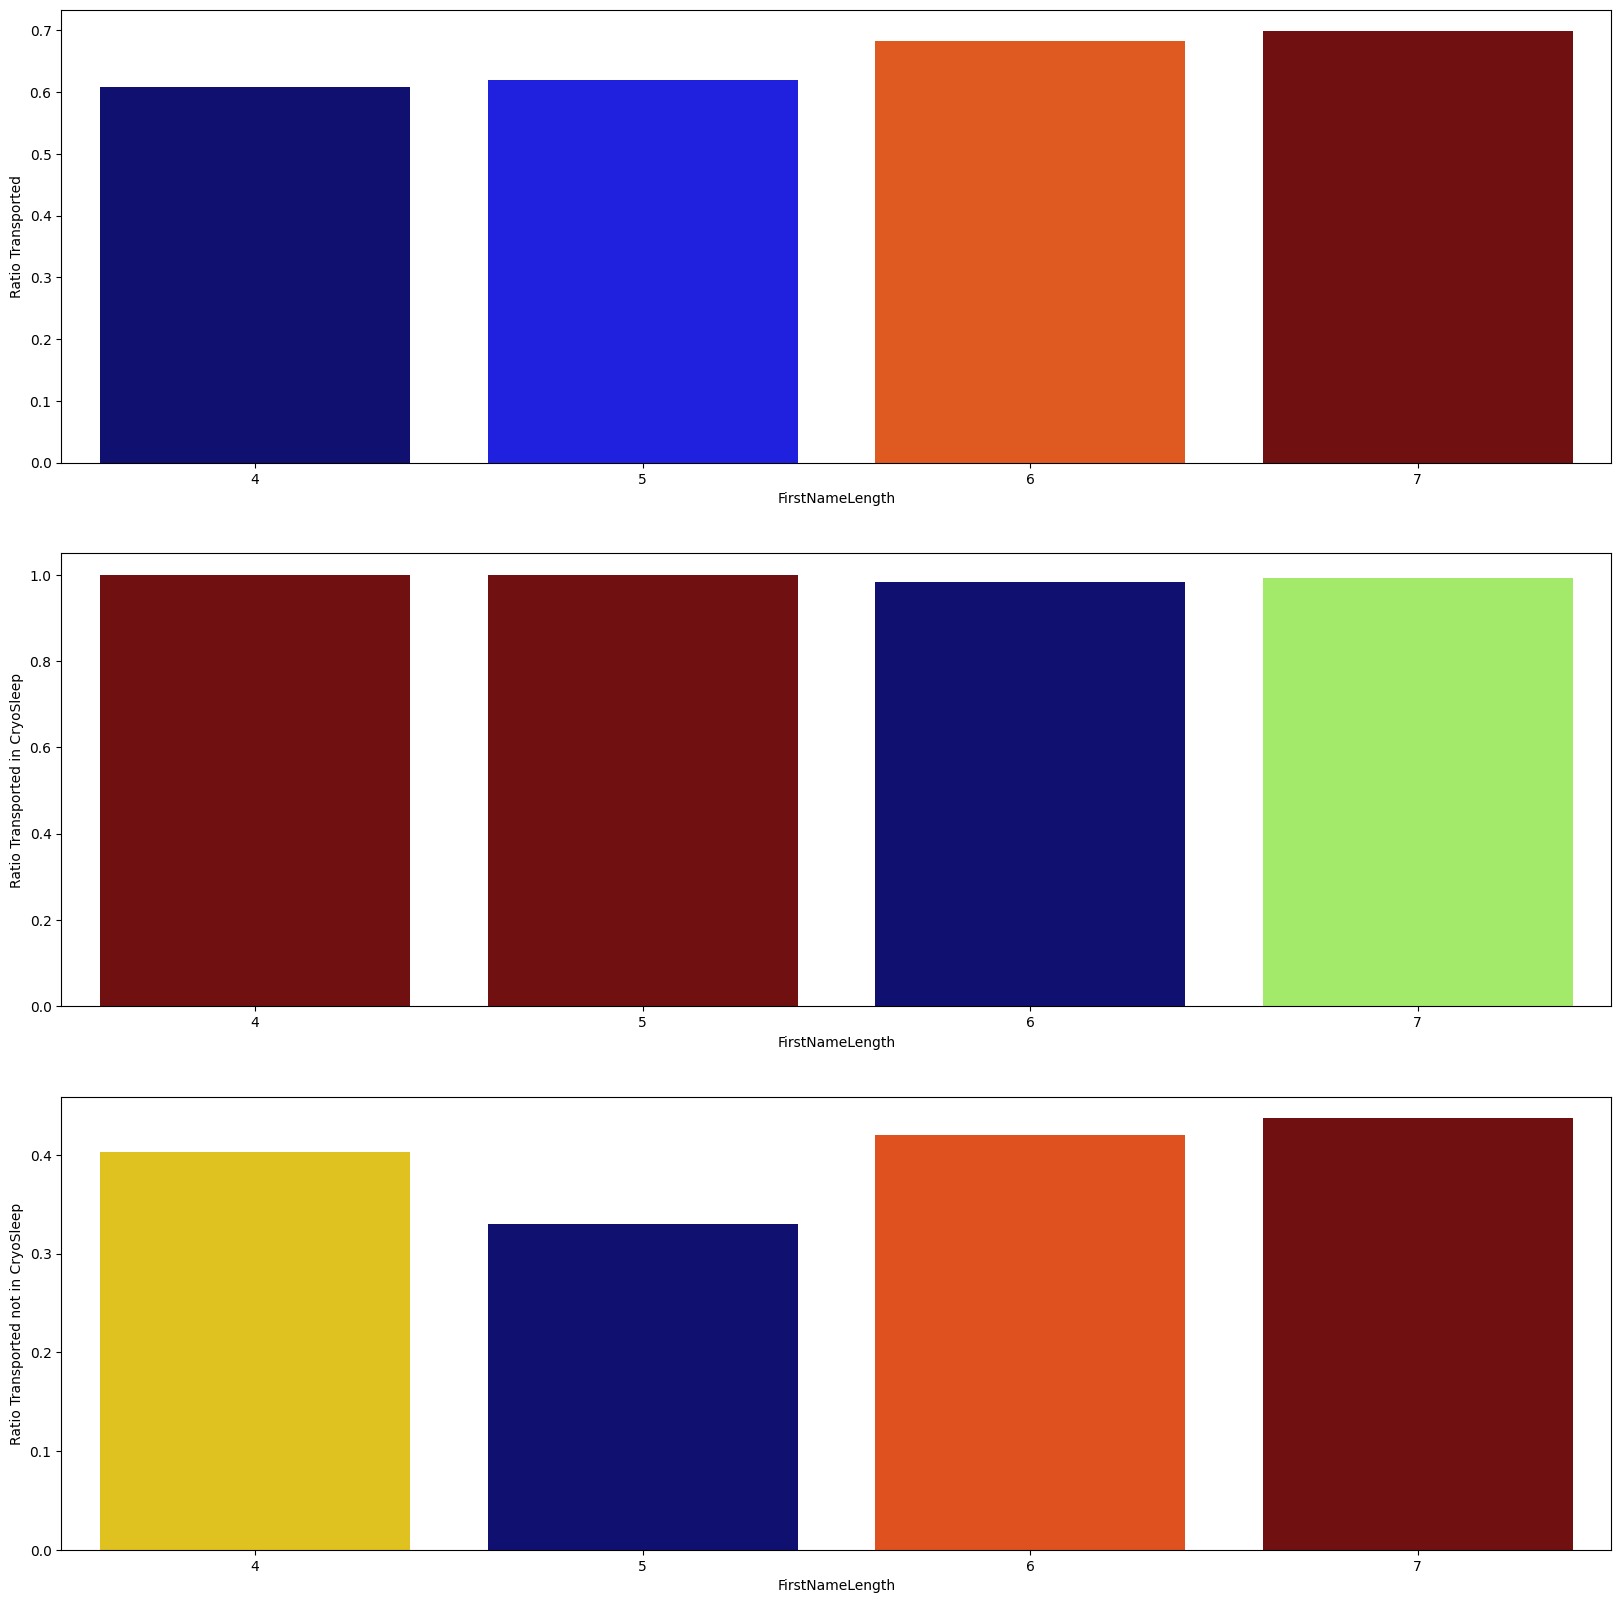

In [112]:
_, _ = plot_ratios_by_Cryo_and_Transported(df1[df1.HomePlanet == 'Europa'], 'FirstNameLength', cat = True)

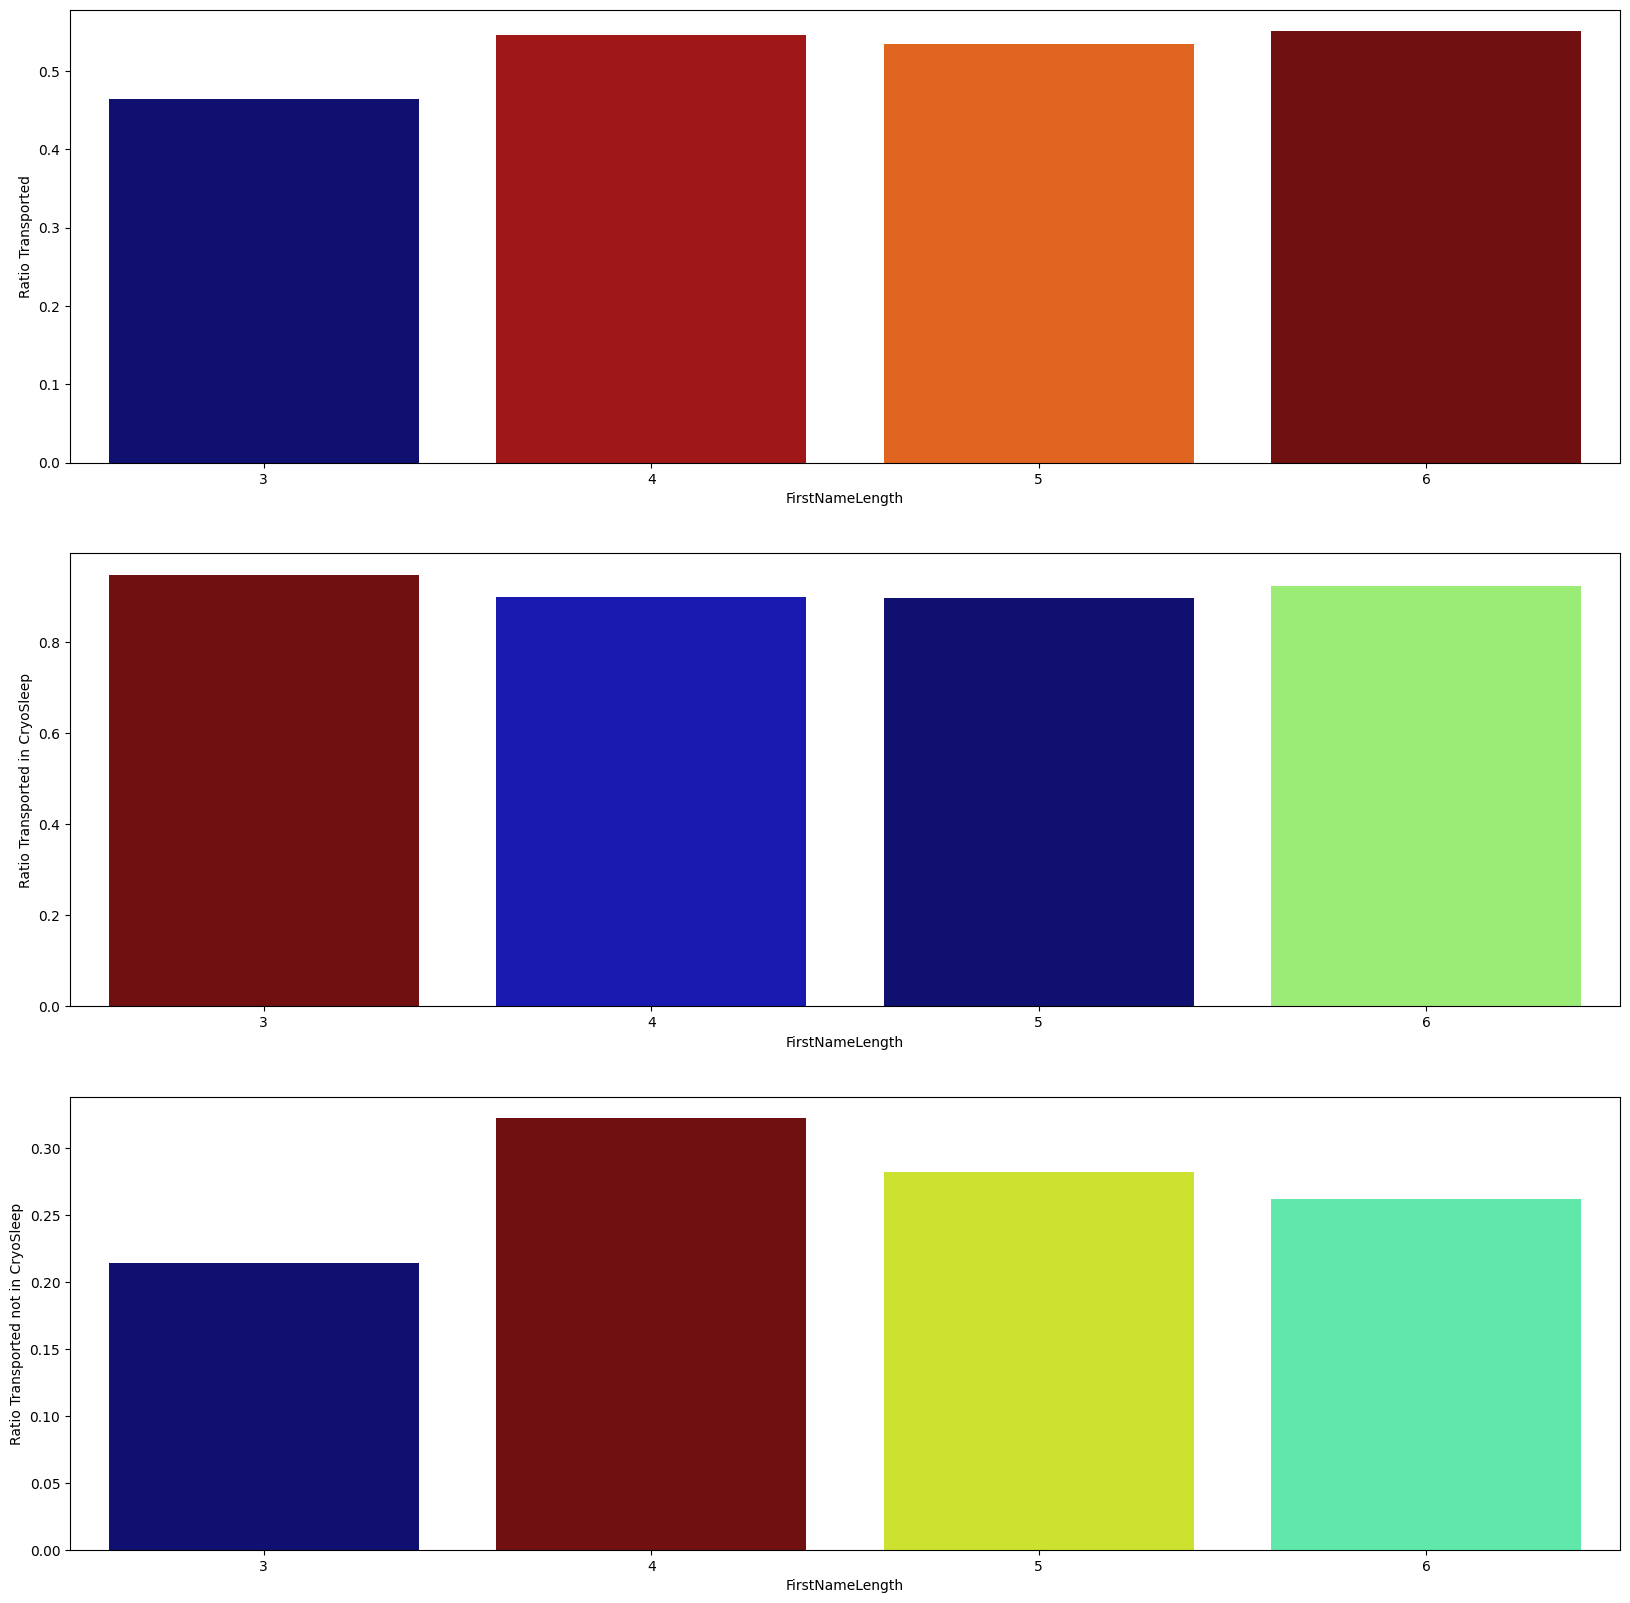

In [113]:
_, _ = plot_ratios_by_Cryo_and_Transported(df1[df1.HomePlanet == 'Mars'], 'FirstNameLength', cat = True)

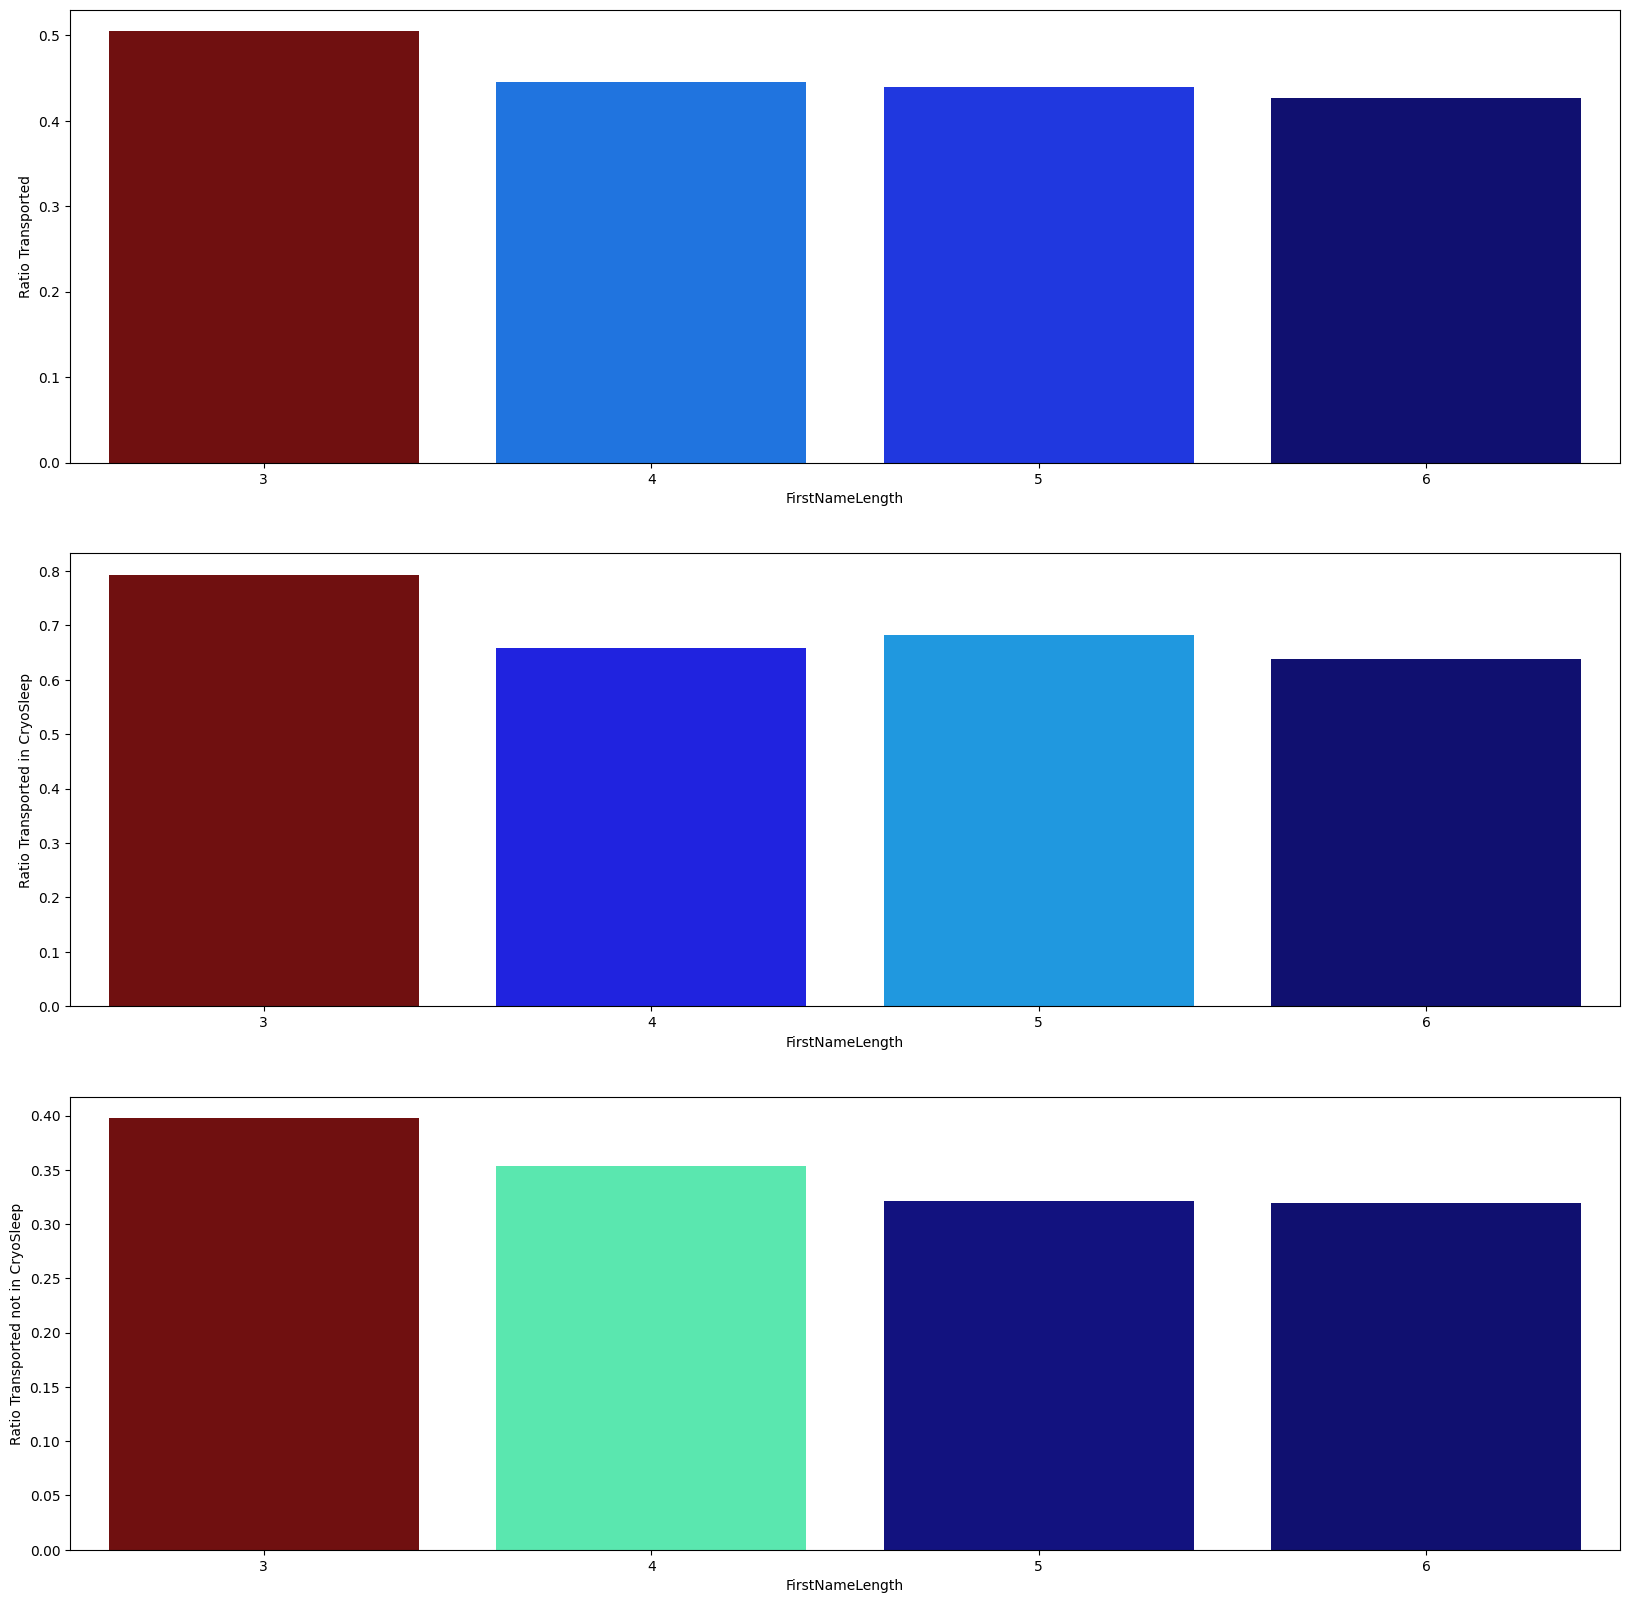

In [114]:
_, _ = plot_ratios_by_Cryo_and_Transported(df1[df1.HomePlanet == 'Earth'], 'FirstNameLength', cat = True)

#### FirstNameLength might have small predictive power when combined with HomePlanet info

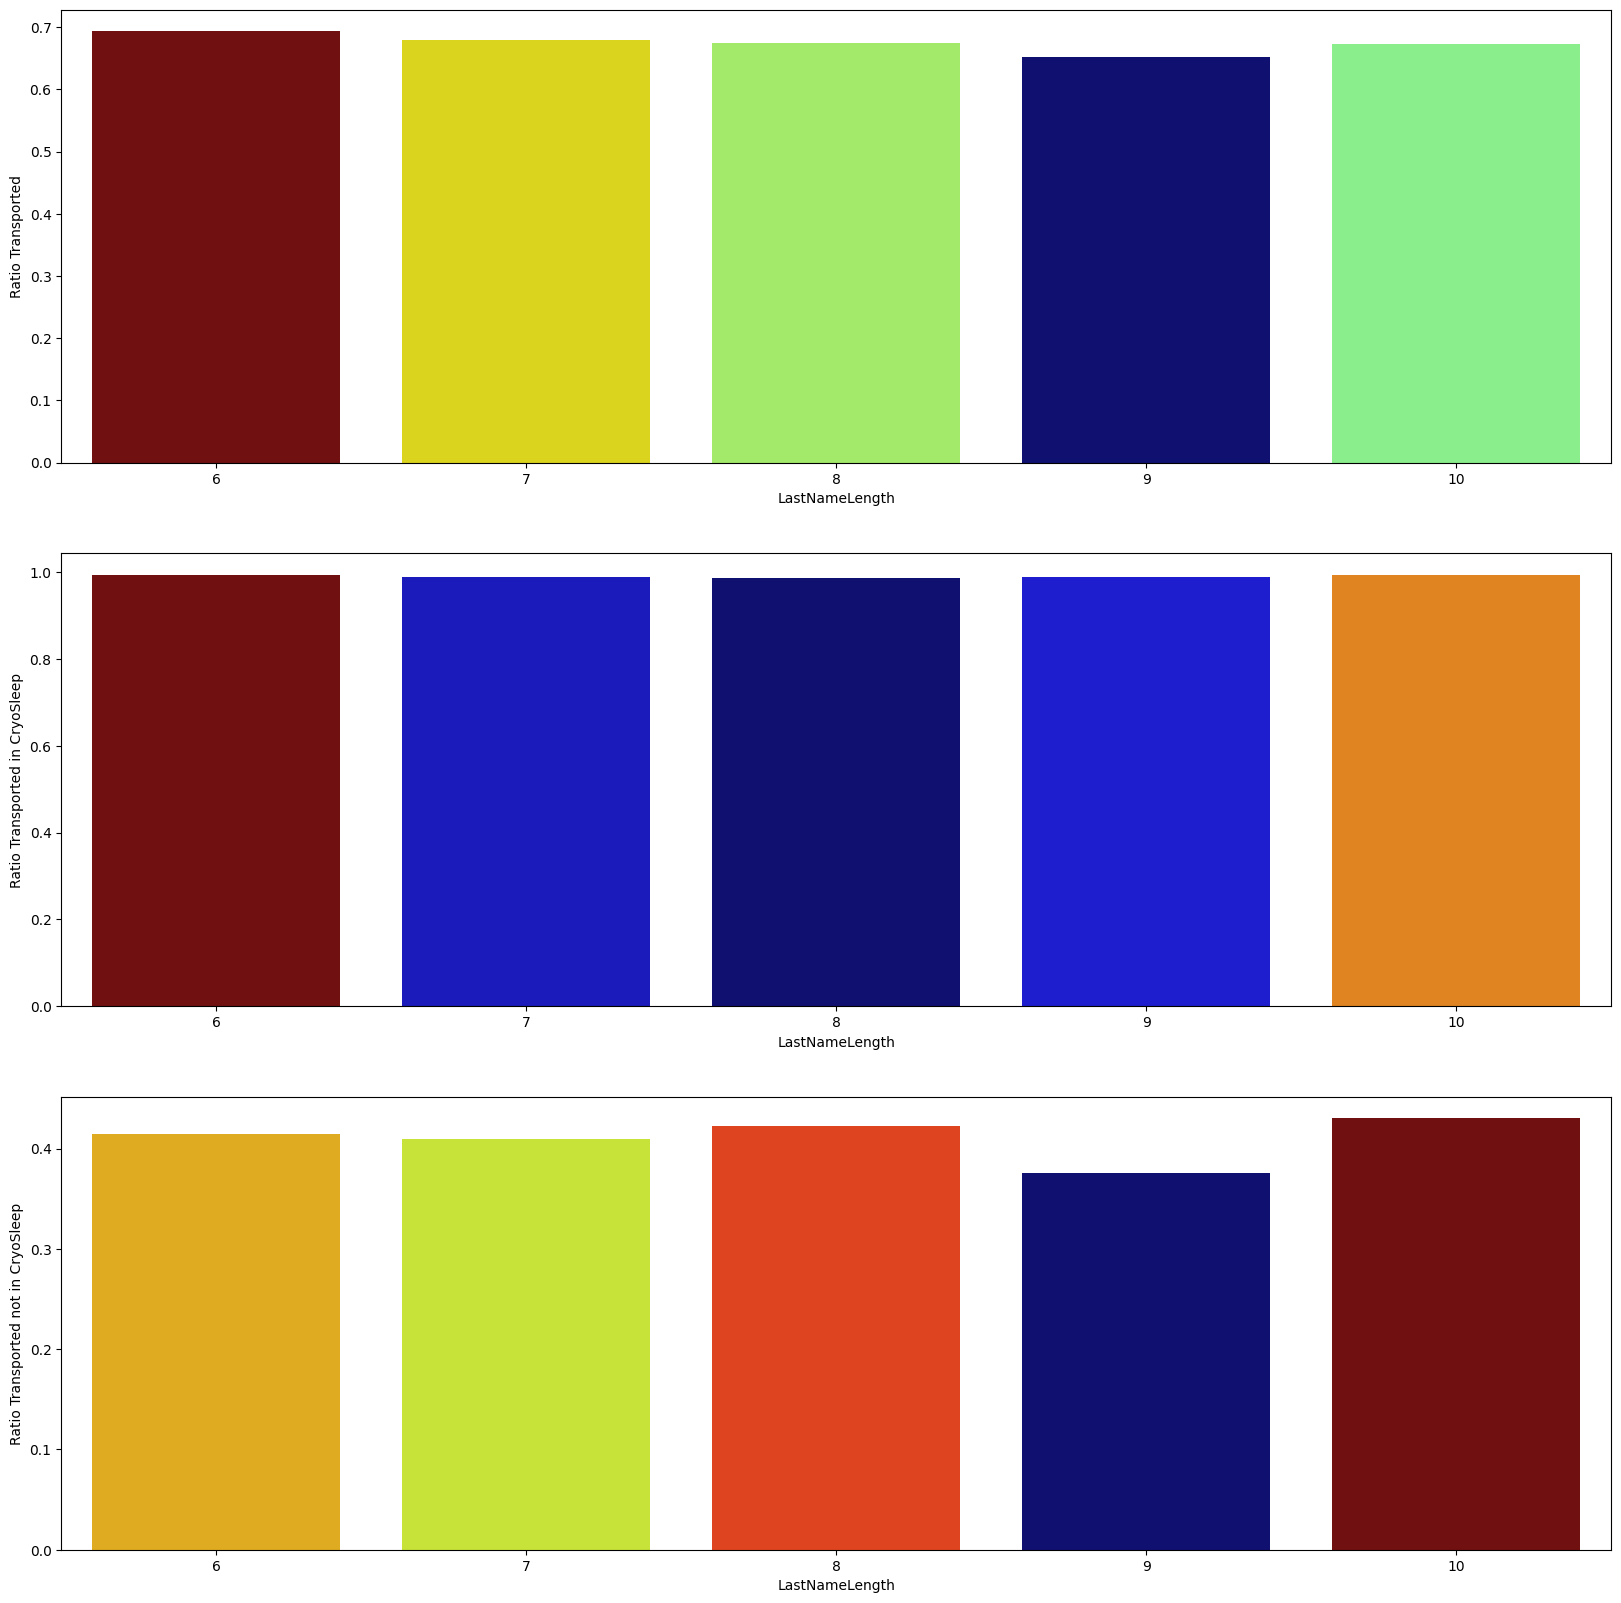

In [115]:
_, _ = plot_ratios_by_Cryo_and_Transported(df1[df1.HomePlanet == 'Europa'], 'LastNameLength', cat = True)

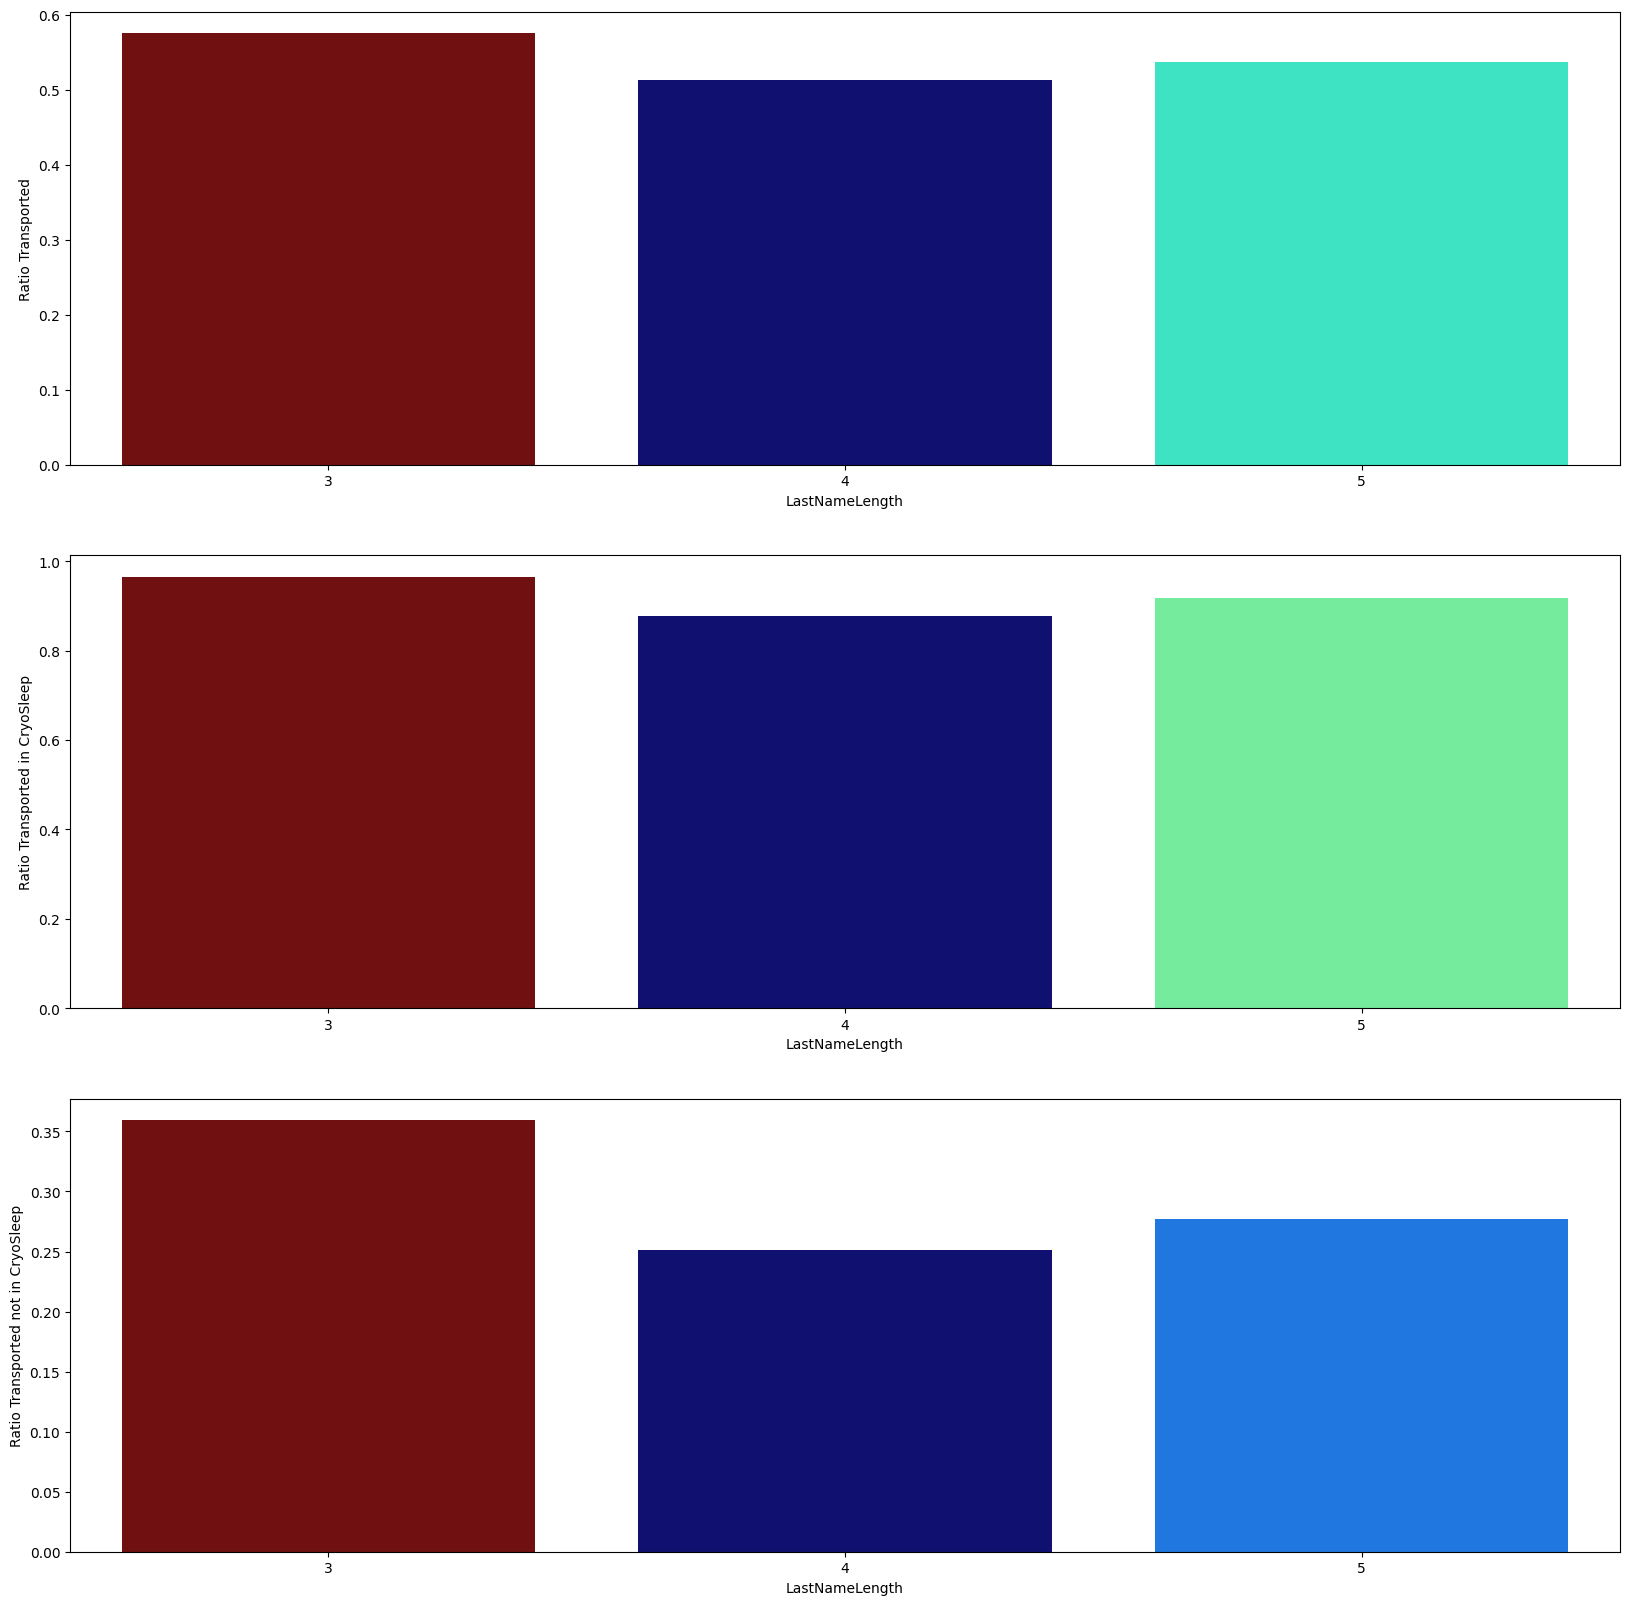

In [116]:
_, _ = plot_ratios_by_Cryo_and_Transported(df1[df1.HomePlanet == 'Mars'], 'LastNameLength', cat = True)

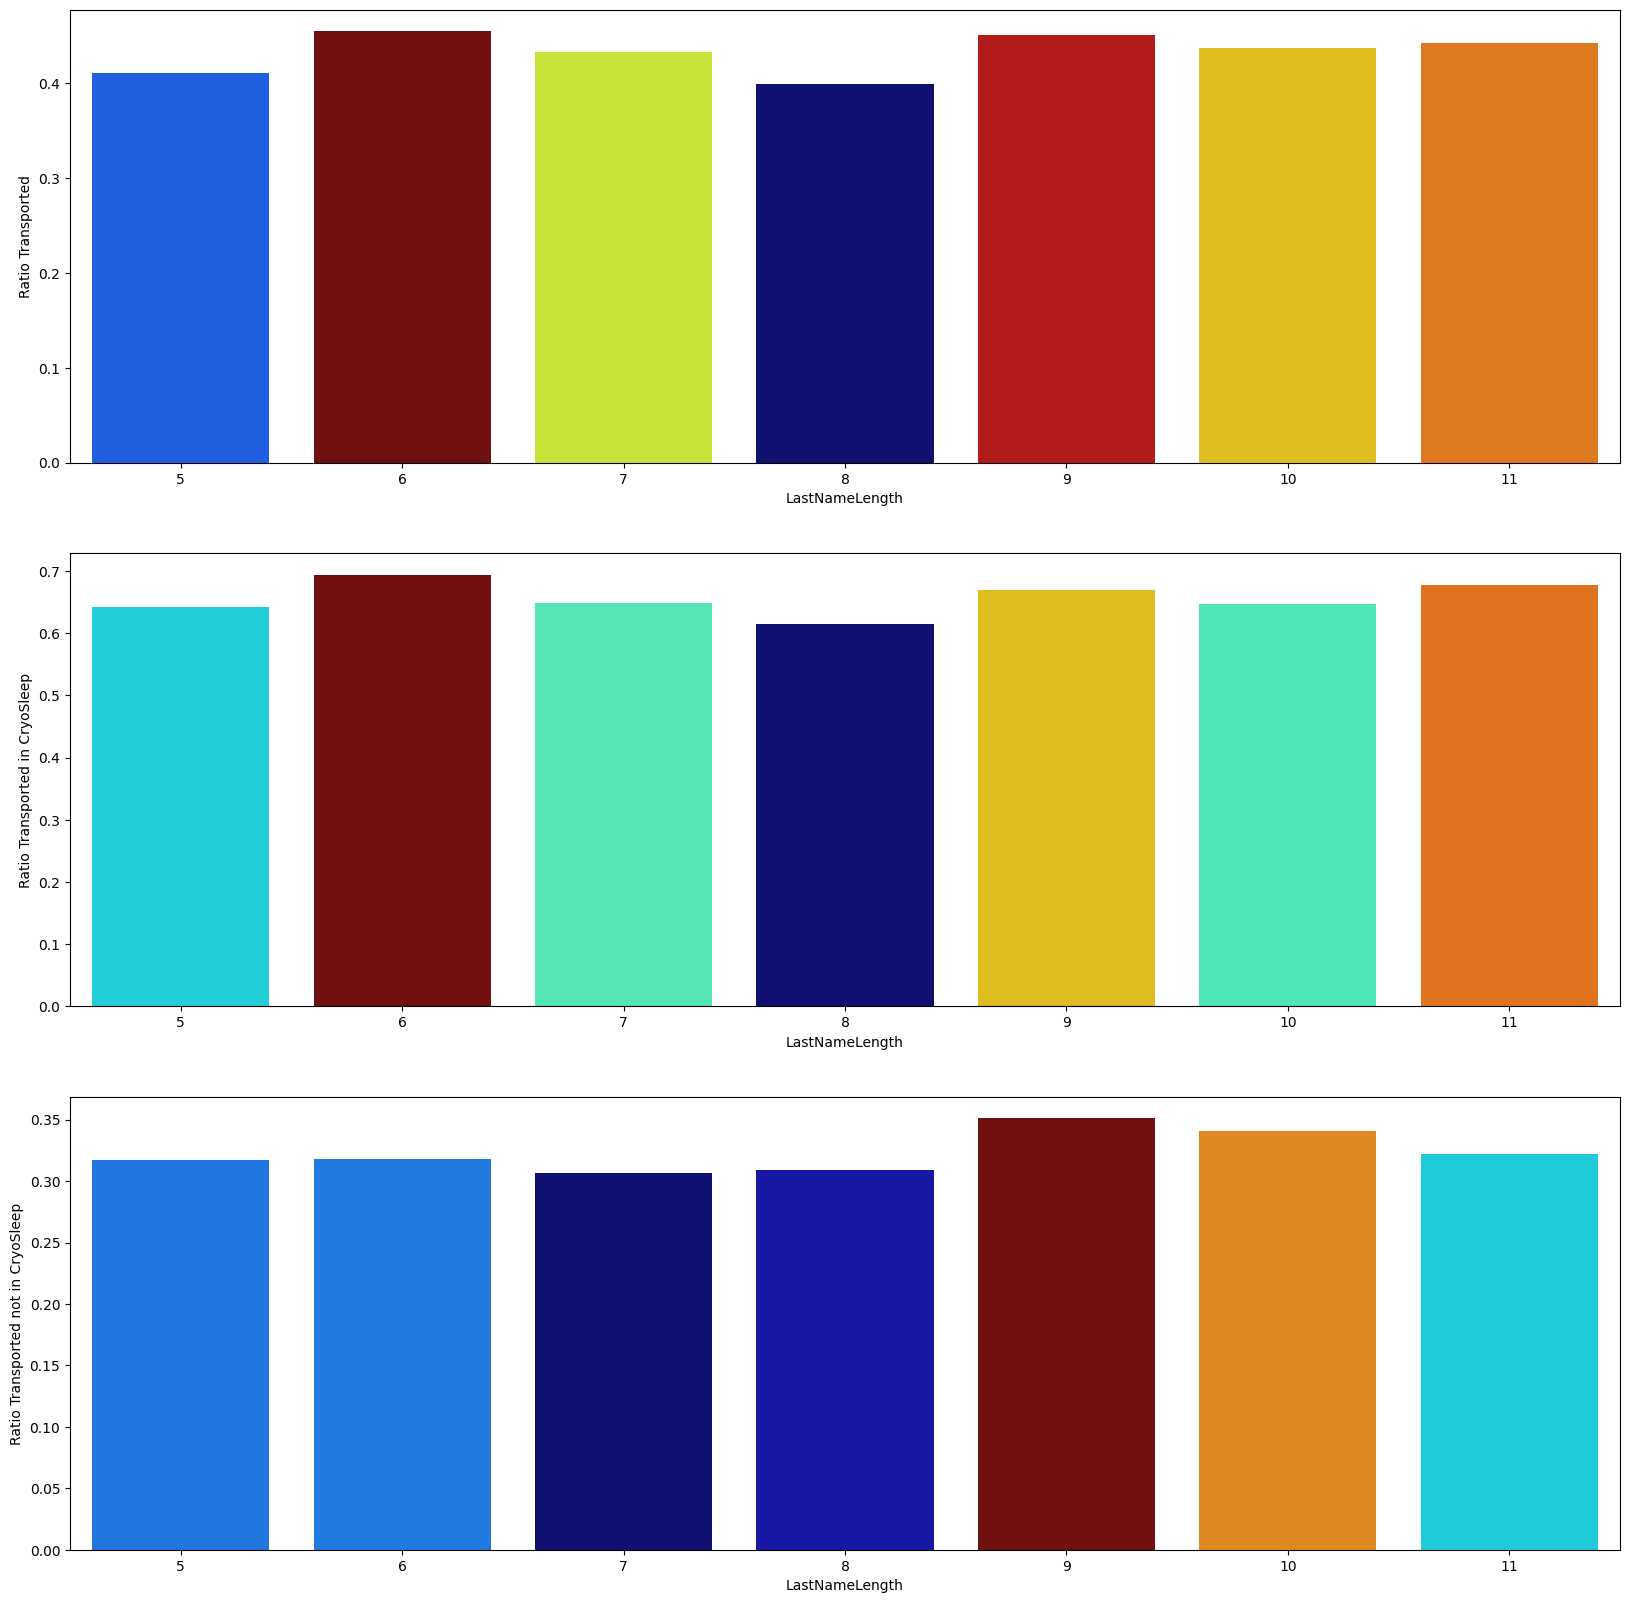

In [117]:
_, _ = plot_ratios_by_Cryo_and_Transported(df1[df1.HomePlanet == 'Earth'], 'LastNameLength', cat = True)

#### Let's Check the effect on performance

In [118]:
df1 = pd.concat([df0, df0_base, df_clean[['HomePlanet', 'Destination', 'deck']]], axis = 1)
df1['HomePlanet_deck'] = df1.HomePlanet + df1.deck
df1['BigFamily'] = (df1['FamilySize'] > 6).astype(int)
skewed_features = ['GroupSize', 'CabinSize', 'FamilySize','CabinGroupSize', 'CabinFamilySize', 'GroupFamilySize']
df1[skewed_features] = df1[skewed_features].apply(np.log1p)
for feature in ['HomePlanet', 'Destination', 'deck', 'HomePlanet_deck']:
    prefix = feature if feature != 'HomePlanet_deck' else 'HD'
    one_hot_encoded = pd.get_dummies(df1[feature], prefix = prefix).astype(int)
    df1 = pd.concat([df1, one_hot_encoded], axis = 1)

HomePlanet_Features = [col for col in df1.columns if col.startswith('HomePlanet_')]
Destination_Features = [col for col in df1.columns if col.startswith('Destination_')]
deck_Features = [col for col in df1.columns if col.startswith('deck_')]
HomePlanet_deck_Features = [col for col in df1.columns if col.startswith('HD_')]

In [119]:
df1.columns

Index(['CryoSleep', 'Transported', 'GroupId', 'ppId', 'G1', 'G2', 'G3', 'G4',
       'Cabin Number', 'GroupSize', 'FamilySize', 'CabinSize',
       'GroupFamilySize', 'CabinFamilySize', 'CabinGroupSize',
       'FirstNameLength', 'LastNameLength', 'Region_1', 'Region_2', 'Region_3',
       'Region_4', 'Region_5', 'Region', 'Batch_1', 'Batch_2', 'Batch_3',
       'Batch_4', 'Batch_5', 'Batch', 'Spa', 'RoomService', 'VRDeck',
       'FoodCourt', 'ShoppingMall', 'Age_LifeStages', 'Under_13', 'HomePlanet',
       'Destination', 'deck', 'HomePlanet_deck', 'BigFamily',
       'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars',
       'Destination_55 Cancri e', 'Destination_PSO J318.5-22',
       'Destination_TRAPPIST-1e', 'deck_A', 'deck_B', 'deck_C', 'deck_D',
       'deck_E', 'deck_F', 'deck_G', 'deck_T', 'HD_EarthE', 'HD_EarthF',
       'HD_EarthG', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD',
       'HD_EuropaE', 'HD_EuropaT', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF'],
     

In [120]:
basic_list = ['CryoSleep', 'Age_LifeStages'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['Region', 'Batch']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Age_LifeStages', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region']
List2:  ['CryoSleep', 'Age_LifeStages', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std
Naive Bayes,0.7517,0.0230,0.7521,0.0223,0.7523,0.0226
Logistic Regression,0.7766,0.0155,0.7756,0.0167,0.7756,0.0169
LightGBM,0.7947,0.0169,0.7947,0.0173,0.7947,0.0171
CatBoost,0.8003,0.0133,0.8059,0.0117,0.8029,0.0113


In [121]:
basic_list = ['CryoSleep', 'Age_LifeStages'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['Batch', 'Region']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Age_LifeStages', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Batch']
List2:  ['CryoSleep', 'Age_LifeStages', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Batch', 'Region']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std
Naive Bayes,0.7517,0.0230,0.7518,0.0226,0.7523,0.0226
Logistic Regression,0.7766,0.0155,0.7749,0.0169,0.7756,0.0169
LightGBM,0.7947,0.0169,0.7945,0.0172,0.7947,0.0171
CatBoost,0.8003,0.0133,0.8046,0.0112,0.8058,0.0124


In [122]:
basic_list = ['CryoSleep', 'Under_13'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['Region', 'Batch']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region']
List2:  ['CryoSleep', 'Under_13', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region', 'Batch']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std
Naive Bayes,0.7505,0.0213,0.7495,0.0217,0.7502,0.0217
Logistic Regression,0.7721,0.0173,0.7722,0.0160,0.7740,0.0152
LightGBM,0.7946,0.0168,0.7934,0.0176,0.7934,0.0174
CatBoost,0.8018,0.0159,0.8044,0.0140,0.8031,0.0114


In [123]:
basic_list = ['CryoSleep', 'Age_LifeStages'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_5']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Age_LifeStages', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region_1']
List2:  ['CryoSleep', 'Age_LifeStages', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Region_1', 'Region_2']
List3:  ['CryoSleep', 'Age_LifeStages', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_Ea

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std,List5_mean,List5_std
Naive Bayes,0.7517,0.0230,0.7520,0.0226,0.7518,0.0222,0.7521,0.0209,0.7524,0.0213,0.7510,0.0198
Logistic Regression,0.7766,0.0155,0.7741,0.0160,0.7762,0.0168,0.7800,0.0120,0.7800,0.0123,0.7794,0.0119
LightGBM,0.7947,0.0169,0.7949,0.0171,0.7947,0.0165,0.7961,0.0180,0.7961,0.0180,0.7961,0.0180
CatBoost,0.8003,0.0133,0.8003,0.0140,0.8043,0.0119,0.8069,0.0100,0.8051,0.0103,0.8032,0.0103


In [124]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['Batch_1', 'Batch_2', 'Batch_3', 'Batch_4', 'Batch_5']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Batch_1']
List2:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Batch_1', 'Batch_2']
List3:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_Ma

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std,List5_mean,List5_std
Naive Bayes,0.7521,0.0223,0.7525,0.0221,0.7527,0.0219,0.7531,0.0206,0.7524,0.0199,0.7528,0.0200
Logistic Regression,0.7756,0.0167,0.7751,0.0163,0.7748,0.0156,0.7752,0.0133,0.7755,0.0134,0.7755,0.0134
LightGBM,0.7947,0.0173,0.7945,0.0167,0.7945,0.0167,0.7946,0.0174,0.7946,0.0174,0.7943,0.0173
CatBoost,0.8072,0.0111,0.8066,0.0108,0.8059,0.0115,0.8018,0.0104,0.8035,0.0103,0.8024,0.0097


In [125]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region_1', 'Region_2', 'Region_3'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['Batch_1', 'Batch_2', 'Batch_3', 'Batch_4', 'Batch_5']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region_1', 'Region_2', 'Region_3', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region_1', 'Region_2', 'Region_3', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Batch_1']
List2:  ['CryoSleep', 'Age_LifeStages', 'Region_1', 'Region_2', 'Region_3', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Batch_1', 'Batch_2']
List3:  ['CryoSleep', 'Age_LifeStages', 'Region_1', 'Region_2', 'Region_3', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std,List5_mean,List5_std
Naive Bayes,0.7521,0.0209,0.7531,0.0208,0.7532,0.0205,0.7536,0.0192,0.7533,0.0182,0.7532,0.0180
Logistic Regression,0.7800,0.0120,0.7798,0.0115,0.7798,0.0116,0.7803,0.0117,0.7798,0.0124,0.7798,0.0124
LightGBM,0.7961,0.0180,0.7958,0.0177,0.7958,0.0177,0.7960,0.0174,0.7960,0.0174,0.7960,0.0174
CatBoost,0.8069,0.0100,0.8059,0.0122,0.8054,0.0106,0.8046,0.0109,0.8054,0.0123,0.8043,0.0112


In [126]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['BigFamily']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'BigFamily']


,List0_mean,List0_std,List1_mean,List1_std
Naive Bayes,0.7521,0.0223,0.7516,0.0223
Logistic Regression,0.7756,0.0167,0.7770,0.0169
LightGBM,0.7947,0.0173,0.7947,0.0173
CatBoost,0.8072,0.0111,0.8088,0.0095


In [127]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['FamilySize']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'FamilySize']


,List0_mean,List0_std,List1_mean,List1_std
Naive Bayes,0.7521,0.0223,0.7517,0.0212
Logistic Regression,0.7756,0.0167,0.7759,0.0162
LightGBM,0.7947,0.0173,0.7947,0.0173
CatBoost,0.8072,0.0111,0.8057,0.0104


In [128]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['GroupSize', 'CabinSize', 'FamilySize']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'GroupSize']
List2:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'GroupSize', 'CabinSize']
List3:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7521,0.0223,0.7505,0.0209,0.7483,0.0192,0.7483,0.0205
Logistic Regression,0.7756,0.0167,0.7757,0.0162,0.7759,0.0163,0.7759,0.0165
LightGBM,0.7947,0.0173,0.7947,0.0173,0.7947,0.0173,0.7947,0.0173
CatBoost,0.8072,0.0111,0.8058,0.0100,0.8054,0.0115,0.8033,0.0125


In [129]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['GroupFamilySize', 'CabinGroupSize', 'CabinFamilySize']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'GroupFamilySize']
List2:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'GroupFamilySize', 'CabinGroupSize']
List3:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_Europ

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7521,0.0223,0.7513,0.0215,0.7484,0.0188,0.7447,0.0188
Logistic Regression,0.7756,0.0167,0.7756,0.0164,0.7756,0.0164,0.7753,0.0167
LightGBM,0.7947,0.0173,0.7947,0.0173,0.7947,0.0173,0.7947,0.0173
CatBoost,0.8072,0.0111,0.8062,0.0118,0.8050,0.0115,0.8029,0.0122


In [130]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['GroupSize', 'G1', 'G2', 'G3', 'G4']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'GroupSize']
List2:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'GroupSize', 'G1']
List3:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_Mar

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std,List5_mean,List5_std
Naive Bayes,0.7521,0.0223,0.7505,0.0209,0.7513,0.0210,0.7510,0.0208,0.7512,0.0206,0.7513,0.0211
Logistic Regression,0.7756,0.0167,0.7757,0.0162,0.7751,0.0167,0.7757,0.0158,0.7738,0.0172,0.7737,0.0173
LightGBM,0.7947,0.0173,0.7947,0.0173,0.7946,0.0167,0.7946,0.0167,0.7946,0.0167,0.7946,0.0167
CatBoost,0.8072,0.0111,0.8058,0.0100,0.8037,0.0126,0.8035,0.0157,0.8050,0.0134,0.8044,0.0126


In [131]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['FirstNameLength', 'LastNameLength', 'ppId']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'FirstNameLength']
List2:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'FirstNameLength', 'LastNameLength']
List3:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_Europ

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7521,0.0223,0.7509,0.0232,0.7509,0.0225,0.7498,0.0217
Logistic Regression,0.7756,0.0167,0.7755,0.0167,0.7757,0.0174,0.7759,0.0173
LightGBM,0.7947,0.0173,0.7947,0.0173,0.7945,0.0169,0.7945,0.0169
CatBoost,0.8072,0.0111,0.8070,0.0092,0.8072,0.0110,0.8057,0.0120


In [132]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['BigFamily', 'FirstNameLength']
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'BigFamily']
List2:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'BigFamily', 'FirstNameLength']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std
Naive Bayes,0.7521,0.0223,0.7516,0.0223,0.7508,0.0218
Logistic Regression,0.7756,0.0167,0.7770,0.0169,0.7774,0.0166
LightGBM,0.7947,0.0173,0.7947,0.0173,0.7947,0.0173
CatBoost,0.8072,0.0111,0.8088,0.0095,0.8067,0.0104


In [133]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region', 'BigFamily'] + Luxury_Features + HomePlanet_deck_Features2
features_list = Destination_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'BigFamily', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'BigFamily', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e']
List2:  ['CryoSleep', 'Age_LifeStages', 'Region', 'BigFamily', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22']
List3:  ['CryoSleep', 'Age_LifeStages', 'Region', 'BigFamily', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'S

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7516,0.0223,0.7498,0.0203,0.7497,0.0203,0.7486,0.0198
Logistic Regression,0.7770,0.0169,0.7778,0.0151,0.7772,0.0152,0.7772,0.0152
LightGBM,0.7947,0.0173,0.7947,0.0173,0.7947,0.0173,0.7947,0.0177
CatBoost,0.8088,0.0095,0.8062,0.0147,0.8073,0.0143,0.8069,0.0143


In [134]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region'] + Luxury_Features + HomePlanet_deck_Features2
features_list = Destination_Features
Compare_Ordered_Feature_Lists(df1, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e']
List2:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22']
List3:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_Europa

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7521,0.0223,0.7499,0.0199,0.7502,0.0197,0.7484,0.0200
Logistic Regression,0.7756,0.0167,0.7772,0.0157,0.7778,0.0154,0.7777,0.0152
LightGBM,0.7947,0.0173,0.7947,0.0173,0.7947,0.0173,0.7947,0.0177
CatBoost,0.8072,0.0111,0.8062,0.0094,0.8055,0.0155,0.8061,0.0144


# Closer look at sides and VIP

In [135]:
df0 = pd.concat([df1, df_clean[['side', 'VIP']]], axis = 1)
df0.VIP = df0.VIP.astype(int)

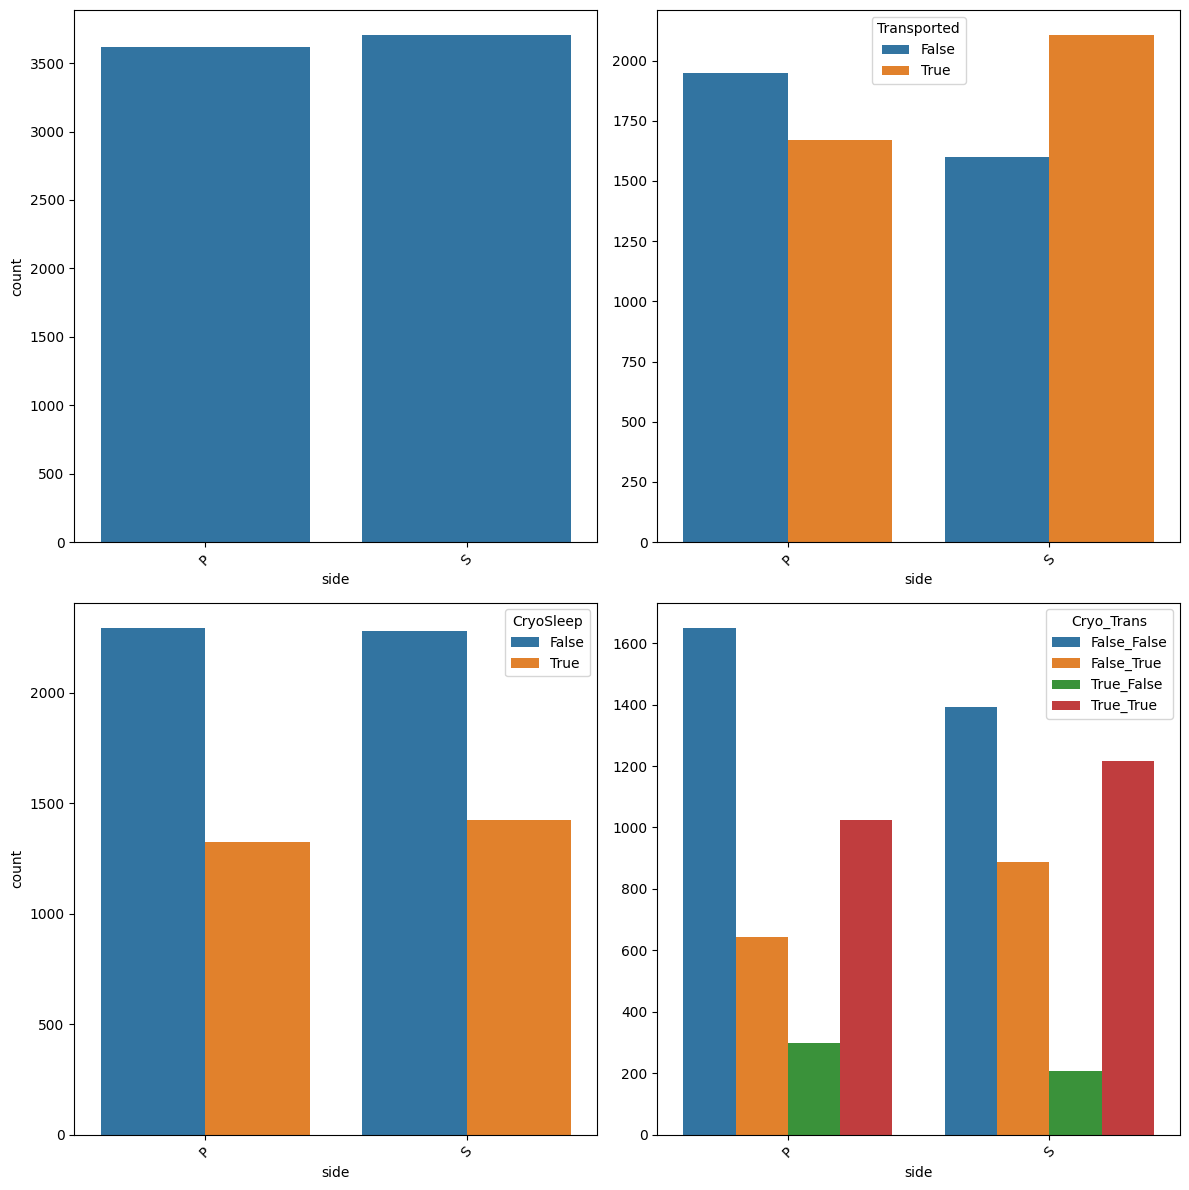

In [136]:
plot_CryoTrans_Counts(df0, 'side', ['P', 'S'])

<Axes: xlabel='VIP', ylabel='count'>

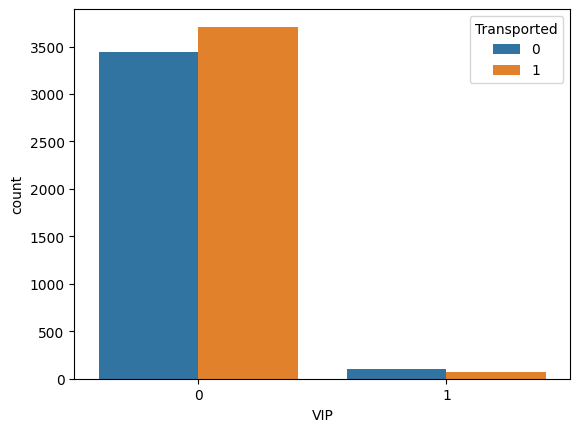

In [137]:
sns.countplot(x = 'VIP', hue = 'Transported', data = df0)

#### We can see that passengers in side S are more likely to be transported than passengers in side P even after accounting for cryosleep status. Since we only have two sides, including both of them as features would be redundant. The overwhelming majority of passengers are not VIP so this feature might not provide valuable predictive information.

In [138]:
df0['side_S'] = (df0.side == 'S').astype(int)

#### Effect on Performance

In [139]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['side_S', 'VIP']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'side_S']
List2:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'side_S', 'VIP']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std
Naive Bayes,0.7521,0.0223,0.7517,0.0218,0.7495,0.0238
Logistic Regression,0.7756,0.0167,0.7813,0.0150,0.7807,0.0152
LightGBM,0.7947,0.0173,0.7980,0.0187,0.7980,0.0187
CatBoost,0.8072,0.0111,0.8151,0.0107,0.8128,0.0138


In [140]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['side_S', 'BigFamily', 'VIP']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'side_S']
List2:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'side_S', 'BigFamily']
List3:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_Ma

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7521,0.0223,0.7517,0.0218,0.7521,0.0218,0.7487,0.0232
Logistic Regression,0.7756,0.0167,0.7813,0.0150,0.7807,0.0148,0.7805,0.0157
LightGBM,0.7947,0.0173,0.7980,0.0187,0.7980,0.0187,0.7980,0.0187
CatBoost,0.8072,0.0111,0.8151,0.0107,0.8117,0.0109,0.8143,0.0110


In [141]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['side_S', 'FamilySize', 'VIP']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = nfolds)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'side_S']
List2:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'side_S', 'FamilySize']
List3:  ['CryoSleep', 'Age_LifeStages', 'Region', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_M

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7521,0.0223,0.7517,0.0218,0.7523,0.0220,0.7494,0.0231
Logistic Regression,0.7756,0.0167,0.7813,0.0150,0.7815,0.0143,0.7805,0.0152
LightGBM,0.7947,0.0173,0.7980,0.0187,0.7980,0.0187,0.7980,0.0187
CatBoost,0.8072,0.0111,0.8151,0.0107,0.8126,0.0112,0.8148,0.0130


# Final Trials

In [142]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S'] + Luxury_Features + HomePlanet_deck_Features2
features_list = Destination_Features
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = nfolds, repeats = 3)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e']
List2:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22']
List3:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall'

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7522,0.0170,0.7510,0.0161,0.7509,0.0162,0.7492,0.0158
Logistic Regression,0.7813,0.0124,0.7816,0.0121,0.7816,0.0122,0.7817,0.0122
LightGBM,0.7965,0.0165,0.7965,0.0165,0.7965,0.0165,0.7965,0.0164
CatBoost,0.8137,0.0118,0.8134,0.0120,0.8134,0.0110,0.8151,0.0119


In [143]:
df2 = pd.concat([df0, df_clean[['Age']]], axis = 1)

In [144]:
basic_list = ['CryoSleep', 'Age', 'Region', 'side_S'] + Luxury_Features + HomePlanet_deck_Features2
features_list = Destination_Features
Compare_Ordered_Feature_Lists(df2, 'Transported', basic_list, features_list, Kfold = nfolds, repeats = 3)

List0:  ['CryoSleep', 'Age', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e']
List2:  ['CryoSleep', 'Age', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22']
List3:  ['CryoSleep', 'Age', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7526,0.0172,0.7518,0.0168,0.7517,0.0167,0.7502,0.0169
Logistic Regression,0.7815,0.0129,0.7819,0.0120,0.7816,0.0121,0.7816,0.0122
LightGBM,0.7957,0.0161,0.7958,0.0162,0.7958,0.0162,0.7959,0.0163
CatBoost,0.8135,0.0128,0.8110,0.0115,0.8143,0.0106,0.8130,0.0106


In [145]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['BigFamily'] + Destination_Features
Compare_Ordered_Feature_Lists(df2, 'Transported', basic_list, features_list, Kfold = nfolds, repeats = 3)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'BigFamily']
List2:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'BigFamily', 'Destination_55 Cancri e']
List3:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std
Naive Bayes,0.7522,0.0170,0.7526,0.0168,0.7510,0.0161,0.7512,0.0161,0.7492,0.0163
Logistic Regression,0.7813,0.0124,0.7804,0.0122,0.7814,0.0111,0.7817,0.0112,0.7818,0.0112
LightGBM,0.7965,0.0165,0.7965,0.0165,0.7965,0.0165,0.7965,0.0165,0.7965,0.0164
CatBoost,0.8137,0.0118,0.8120,0.0115,0.8137,0.0118,0.8150,0.0108,0.8130,0.0126


In [146]:
basic_list = ['CryoSleep', 'Under_13', 'Region', 'side_S'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['BigFamily'] + Destination_Features
Compare_Ordered_Feature_Lists(df2, 'Transported', basic_list, features_list, Kfold = nfolds, repeats = 3)

List0:  ['CryoSleep', 'Under_13', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Under_13', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'BigFamily']
List2:  ['CryoSleep', 'Under_13', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'BigFamily', 'Destination_55 Cancri e']
List3:  ['CryoSleep', 'Under_13', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_Europa

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std,List4_mean,List4_std
Naive Bayes,0.7520,0.0162,0.7514,0.0164,0.7503,0.0159,0.7503,0.0158,0.7479,0.0161
Logistic Regression,0.7826,0.0131,0.7811,0.0124,0.7822,0.0113,0.7823,0.0112,0.7823,0.0112
LightGBM,0.7961,0.0166,0.7961,0.0166,0.7961,0.0165,0.7961,0.0165,0.7960,0.0165
CatBoost,0.8127,0.0124,0.8127,0.0108,0.8125,0.0114,0.8142,0.0117,0.8128,0.0103


In [147]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['Batch']
Compare_Ordered_Feature_Lists(df2, 'Transported', basic_list, features_list, Kfold = nfolds, repeats = 3)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Batch']


,List0_mean,List0_std,List1_mean,List1_std
Naive Bayes,0.7522,0.0170,0.7523,0.0167
Logistic Regression,0.7813,0.0124,0.7813,0.0125
LightGBM,0.7965,0.0165,0.7955,0.0166
CatBoost,0.8137,0.0118,0.8115,0.0116


In [148]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['VIP']
Compare_Ordered_Feature_Lists(df2, 'Transported', basic_list, features_list, Kfold = nfolds, repeats = 3)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'VIP']


,List0_mean,List0_std,List1_mean,List1_std
Naive Bayes,0.7522,0.0170,0.7494,0.0186
Logistic Regression,0.7813,0.0124,0.7807,0.0127
LightGBM,0.7965,0.0165,0.7965,0.0165
CatBoost,0.8137,0.0118,0.8128,0.0125


In [149]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['GroupSize', 'CabinSize']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = nfolds, repeats = 3)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'GroupSize']
List2:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'GroupSize', 'CabinSize']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std
Naive Bayes,0.7522,0.0170,0.7524,0.0163,0.7495,0.0151
Logistic Regression,0.7813,0.0124,0.7811,0.0130,0.7813,0.0134
LightGBM,0.7965,0.0165,0.7965,0.0165,0.7965,0.0165
CatBoost,0.8137,0.0118,0.8116,0.0120,0.8104,0.0120


In [150]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['FirstNameLength', 'LastNameLength']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = nfolds, repeats = 3)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'FirstNameLength']
List2:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'FirstNameLength', 'LastNameLength']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std
Naive Bayes,0.7522,0.0170,0.7517,0.0172,0.7518,0.0171
Logistic Regression,0.7813,0.0124,0.7810,0.0125,0.7811,0.0125
LightGBM,0.7965,0.0165,0.7965,0.0165,0.7965,0.0165
CatBoost,0.8137,0.0118,0.8133,0.0103,0.8111,0.0115


In [151]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['CabinFamilySize', 'GroupFamilySize', 'CabinGroupSize']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = nfolds, repeats = 3)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'CabinFamilySize']
List2:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'CabinFamilySize', 'GroupFamilySize']
List3:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_Europa

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7522,0.0170,0.7510,0.0161,0.7485,0.0161,0.7452,0.0156
Logistic Regression,0.7813,0.0124,0.7816,0.0131,0.7813,0.0129,0.7812,0.0130
LightGBM,0.7965,0.0165,0.7965,0.0165,0.7965,0.0165,0.7965,0.0165
CatBoost,0.8137,0.0118,0.8138,0.0125,0.8119,0.0113,0.8128,0.0111


In [152]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['CabinGroupSize', 'CabinFamilySize']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = nfolds, repeats = 3)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'CabinGroupSize']
List2:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'CabinGroupSize', 'CabinFamilySize']


,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std
Naive Bayes,0.7522,0.0170,0.7512,0.0160,0.7470,0.0160
Logistic Regression,0.7813,0.0124,0.7814,0.0133,0.7814,0.0132
LightGBM,0.7965,0.0165,0.7965,0.0165,0.7965,0.0165
CatBoost,0.8137,0.0118,0.8124,0.0117,0.8119,0.0125


In [153]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Destination_55 Cancri e']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = nfolds, repeats = 3)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_PSO J318.5-22']
List2:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e']
List3:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMal

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7522,0.0170,0.7522,0.0169,0.7520,0.0167,0.7492,0.0158
Logistic Regression,0.7813,0.0124,0.7813,0.0126,0.7815,0.0122,0.7817,0.0122
LightGBM,0.7965,0.0165,0.7965,0.0165,0.7965,0.0165,0.7965,0.0164
CatBoost,0.8137,0.0118,0.8120,0.0113,0.8147,0.0112,0.8145,0.0115


In [156]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S'] + Luxury_Features + HomePlanet_deck_Features2
features_list = ['Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'Destination_55 Cancri e']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = nfolds, repeats = 5)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_PSO J318.5-22']
List2:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e']
List3:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMal

,List0_mean,List0_std,List1_mean,List1_std,List2_mean,List2_std,List3_mean,List3_std
Naive Bayes,0.7523,0.0171,0.7523,0.0170,0.7524,0.0172,0.7494,0.0167
Logistic Regression,0.7814,0.0140,0.7812,0.0141,0.7817,0.0137,0.7816,0.0139
LightGBM,0.7971,0.0166,0.7971,0.0166,0.7972,0.0165,0.7971,0.0165
CatBoost,0.8140,0.0131,0.8126,0.0125,0.8149,0.0125,0.8150,0.0125


In [158]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S'] + Luxury_Features + HomePlanet_deck_Features2 + Destination_Features
features_list = ['BigFamily']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = nfolds, repeats = 5)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'BigFamily']


,List0_mean,List0_std,List1_mean,List1_std
Naive Bayes,0.7494,0.0167,0.7495,0.0168
Logistic Regression,0.7816,0.0139,0.7817,0.0133
LightGBM,0.7971,0.0165,0.7971,0.0165
CatBoost,0.8151,0.0133,0.8135,0.0128


In [159]:
basic_list = ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S'] + Luxury_Features + HomePlanet_deck_Features2 + Destination_Features
features_list = ['VIP']
Compare_Ordered_Feature_Lists(df0, 'Transported', basic_list, features_list, Kfold = nfolds, repeats = 5)

List0:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e']
List1:  ['CryoSleep', 'Age_LifeStages', 'Region', 'side_S', 'Spa', 'RoomService', 'VRDeck', 'FoodCourt', 'ShoppingMall', 'HD_EuropaA', 'HD_EuropaB', 'HD_EuropaC', 'HD_EuropaD', 'HD_EuropaE', 'HD_MarsD', 'HD_MarsE', 'HD_MarsF', 'HD_EarthE', 'HD_EarthF', 'HD_EarthG', 'Destination_55 Cancri e', 'Destination_PSO J318.5-22', 'Destination_TRAPPIST-1e', 'VIP']


,List0_mean,List0_std,List1_mean,List1_std
Naive Bayes,0.7494,0.0167,0.7470,0.0180
Logistic Regression,0.7816,0.0139,0.7813,0.0138
LightGBM,0.7971,0.0165,0.7971,0.0165
CatBoost,0.8151,0.0133,0.8132,0.0130
